<a href="https://colab.research.google.com/github/Abeersuhail/Prediction-of-Radiotherapy-Side-effct/blob/main/Skin_HyperpigmentationRisk_Event1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
dep = 'Breast Skin Hyperpigmentation'

In [2]:
%pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 12.2 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=814e9de960ef5910e3fe285db7d06b3999f738e5a4327dca969812936110bdbe
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [3]:
# this is needed for survival
!pip install scikit-survival

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 77.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 10.6 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [4]:
# for deep learning
!pip install pycox

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.6/73.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.6/495.6 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.6/100.6 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.3/52.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 5.4 MB/s eta 0:00:00
  Created wheel for feather-format: filename=feather_format-0.4.1-py3-none-any.whl size=2434 sha256=7b79eb5bb93f1f1c085f13cc5887a7da784597828b159d50fbfb9c5388d45663
  Stored in directory: /root/.cache/pip/wheels/dd/02/6b/2f0f7e1c0454094c880e63076da142e67f1ba72f82baa6195f
Successfully built feather-format


In [5]:
pip install mpld3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.1/203.1 kB 5.2 MB/s eta 0:00:00


In [6]:
# importing Pandas and NumPy library
import lifelines
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from numpy import sqrt
import statsmodels.api as sm
import statsmodels.formula.api as smf

from lifelines import KaplanMeierFitter
from lifelines.plotting import add_at_risk_counts

# for visualising and metrics
from sklearn.decomposition import PCA
from sklearn import metrics
import matplotlib.pyplot as plt
from matplotlib import pyplot
from matplotlib.dviread import DviFont
import seaborn as sns

# for sankey
import plotly.graph_objects as go

# for error
import warnings
warnings.filterwarnings('ignore')


In [7]:
#Identify and remove highly correlated features from the dataset.
def pairwisecorr(df, col=None, threshold=0.7):

  if col:
      X = df.loc[:, df.columns != col]
  else:
      X = df.copy()

  # Exclude datetime columns and string columns from correlation calculation
  numeric_features = X.select_dtypes(include=np.number).columns
  X_numeric = X[numeric_features]

  # Compute correlation matrix
  corr_matrix = X_numeric.corr().abs()

  # Mask upper triangle to avoid duplicate pairs
  mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
  tri_df = corr_matrix.mask(mask)

  to_drop = []
  correlated_pairs = []

  # Find pairs of features with high correlation
  for c in tri_df.columns:
    for index, value in tri_df[c].items():
      if value > threshold:
        correlated_pairs.append((c, index, value))

        # Drop the feature with more missing values
        missing_c = X_numeric[c].isnull().sum()
        missing_index = X_numeric[index].isnull().sum()

        if missing_c > missing_index:
          to_drop.append(c)
        else:
          to_drop.append(index)

  # Remove duplicates from to_drop list
  to_drop = list(set(to_drop))

  # Drop highly correlated features
  reduced_X = X.drop(to_drop, axis=1)

  print("Highly correlated feature pairs (correlation > {:.2f}):".format(threshold))
  for pair in correlated_pairs:
    print(f"Features: {pair[0]} and {pair[1]}, Correlation: {pair[2]:.2f}")

  print("\nRemaining features after dropping highly correlated ones:")
  print(list(reduced_X.columns))
  print("\nThese features were removed due to high correlation:")
  print(to_drop)
  print("\nShape of the reduced dataset:", reduced_X.shape)

In [8]:
#Remove all features that contain 50% or more null
def remove_missing(df, per):
  print("Before removinig columns with highly missing", df.shape)
  perc = per
  min_count = int(((100 - perc) / 100) * df.shape[0] + 1)
  df = df.dropna(axis=1, thresh=min_count)  # Drop columns which contain more half than of their values are missing
  print("After removinig columns with highly missing",df.shape)
  return df

In [9]:
def endpoints_rate(df, Event1, Event2, Time1, Time2):
  print("Endpoint 1 event rate:", df[Event1].mean()*100, "%")
  print("Endpoint 2 event rate:", df[Event2].mean()*100, "%")

  # check consistency (severe event should not precede mild unless direct jump)
  violations = (df[Time2] < df[Time1]) & (df[Event1] == 1) & (df[Event2] == 1)
  print("Patients where severe < mild:", violations.sum())

  print("Endpoint 1 event count:", df[Event1].sum())
  print("Endpoint 2 event count:", df[Event2].sum())

In [10]:
import pandas as pd

def summarize_nested_events(df, event1_col, event2_col,id_col='subject_id', show_cols=None,
    label='Outcome',  print_summary=True,
    return_groups=True,    head_n=10
):

    if show_cols is None:
        show_cols = []

    # Work on a copy
    n_df = df.dropna(subset=[event1_col, event2_col]).copy()

    # Ensure binary/integer columns
    n_df[event1_col] = n_df[event1_col].astype(int)
    n_df[event2_col] = n_df[event2_col].astype(int)

    # Define groups
    no_event = n_df[(n_df[event1_col] == 0) & (n_df[event2_col] == 0)]
    mild_only = n_df[(n_df[event1_col] == 1) & (n_df[event2_col] == 0)]
    moderate_severe = n_df[(n_df[event1_col] == 1) & (n_df[event2_col] == 1)]
    inconsistent = n_df[(n_df[event1_col] == 0) & (n_df[event2_col] == 1)]

    if print_summary:
        print(f"SUMMARY OF {label.upper()} GROUPS")
        print("-" * 40)
        print(f"No {label.lower()}:            {len(no_event)}")
        print(f"Mild only (Grade 1):    {len(mild_only)}")
        print(f"Moderate–severe (≥2):  {len(moderate_severe)}")
        print(f"Inconsistent cases:    {len(inconsistent)}   <-- should be 0")
        print("-" * 40)
        print(f"Total patients:        {len(n_df)}")

        display_cols = [c for c in [id_col] + show_cols if c in moderate_severe.columns]

        if display_cols:
            print(f"\nModerate–severe {label} cases (Grade ≥2):")
            print(moderate_severe[display_cols].head(head_n))
        else:
            print(f"\nModerate–severe {label} cases (Grade ≥2):")
            print(moderate_severe.head(head_n))

    if return_groups:
        return {
            'clean_df': n_df,
            'no_event': no_event,
            'mild_only': mild_only,
            'moderate_severe': moderate_severe,
            'inconsistent': inconsistent
        }

In [11]:
# Read the data from original file (use relative paths)
#data1 = pd.read_csv('/content/FinalRTmerged_data8.10.25.csv')
data1 = pd.read_csv('/content/All_with_Survivaldata.csv')
data2= pd.read_csv('/content/Hyperpigmentationspacoxall_snpsE1.csv')
#data2= pd.read_csv('/content/Hyperpigmentationspacoxall_snpsE2.csv')
#data4=pd.read_csv('/content/test_ids2.txt', sep='\t')
data3=pd.read_csv('/content/train_ids2.txt', sep='\t', header=None)


In [12]:
print(list(data1.columns))

['subject_id', 'date', 'height_cm', 'weight_at_cancer_diagnosis_kg', 'age', 'bra_cup_size', 'band_size', 'smoker', 'smoking_duration_yrs', 'tobacco_products_per_day', 'smoking_time_since_quitting_yrs', 'tobacco_product', 'alcohol_intake', 'alcohol_previous_consumption', 'alcohol_current_consumption', 'menopausal_status', 'monopause_age_yrs', 'hormone_replacement_therapy', 'diabetes', 'diabetes_duration_yrs', 'history_of_heart_disease', 'history_of_heart_disease_duration_yrs', 'ra', 'ra_duration_yrs', 'systemic_lupus_erythematosus', 'systemic_lupus_erythematosus_duration_yrs', 'other_collagen_vascular_disease', 'other_collagen_vascular_disease_duration_yrs', 'hypertension', 'hypertension_duration_yrs', 'depression', 'depression_duration_yrs', 'antidiabetic', 'antidiabetic_duration_yrs', 'ace_inhibitor', 'ace_inhibitor_duration_yrs', 'other_antihypertensive_drug', 'other_antihypertensive_drug_duration_yrs', 'on_statin', 'on_statin_duration_yrs', 'other_lipid_lowering_drugs', 'other_lipid

In [13]:
# calculate uniq data
def Cuniq(df, x):
  print(df[x].sort_values().value_counts())

In [14]:
data1 = data1.replace('NaN', np.nan)
#data1['BMI'] = (data1['wt'] / data1['ht'].div(1000).pow(2)).div(100)
data1['bmi'] = (data1['weight_at_cancer_diagnosis_kg'] / data1['height_cm'].div(1000).pow(2)).div(100)

In [15]:
# Manipulate unclear values
data1 = data1.replace('?', np.nan)  # replace ? with nan
data1 = data1.replace('x', np.nan)  # replace ? with nan
data1 = data1.replace('0.0%', 0)  # replace ? with nan
data1 = data1.replace('0', 0)  # replace ? with nan
data1 = data1.replace('1', 1)  # replace ? with nan
data1 = data1.replace('2', 2)  # replace ? with nan
data1 = data1.replace('3', 3)  # replace ? with nan
data1 = data1.replace('^\s+', np.nan, regex=True)  # replace empty spaces with nan value

In [16]:
# Handling some missing values
data1["smoker"].fillna(0, inplace=True) # notice from excel sheet that null values in smokers have value 0 in smoking
data1["alcohol_intake"].fillna(0, inplace=True) # notice from excel sheet that non alcohol drinker dont have alcoholintaker

In [17]:
# Convert some categorical data to their own type
data1['t_stage'] = data1['t_stage'].astype('category')
data1['n_stage'] = data1['n_stage'].astype('category')
data1['m_stage'] = data1['m_stage'].astype('category')
data1['r_stage'] = data1['r_stage'].astype('category')

In [18]:
data1 = data1.replace(8, np.nan)
data1 = data1.replace(9, np.nan)

In [19]:
# Drops rows where the 'id' value is repeated
data1.drop_duplicates(subset=['subject_id'], keep='first', inplace=True)

In [20]:
data1.head()

,subject_id,date,height_cm,weight_at_cancer_diagnosis_kg,age,bra_cup_size,band_size,smoker,smoking_duration_yrs,tobacco_products_per_day,...,EventindurationIn2,TimetelangiectasiaO1,EventtelangiectasiaO1,TimetelangiectasiaO2,EventtelangiectasiaO2,TimetelangiectasiaIn1,EventtelangiectasiaIn1,TimetelangiectasiaIn2,EventtelangiectasiaIn2,bmi
0,RQ00001-2,24/06/2014,164.0,78.0,62,5.0,NaN,1.0,30.0,10.0,...,0.0,12.0,1.0,36.0,0.0,36.0,0.0,36.0,0.0,29.000595
1,RQ00002-0,08/07/2014,162.0,57.0,47,3.0,3.0,3.0,30.0,15.0,...,0.0,60.0,0.0,60.0,0.0,60.0,0.0,60.0,0.0,21.719250
2,RQ00004-9,17/06/2014,171.0,82.0,56,5.0,NaN,0.0,NaN,NaN,...,0.0,60.0,0.0,60.0,0.0,60.0,0.0,60.0,0.0,28.042817
3,RQ00005-4,06/08/2014,156.0,76.0,63,5.0,NaN,0.0,NaN,NaN,...,1.0,48.0,0.0,48.0,0.0,48.0,0.0,48.0,0.0,31.229454
4,RQ00006-5,02/07/2014,164.0,59.0,68,5.0,5.0,1.0,17.0,3.0,...,0.0,24.0,0.0,24.0,0.0,24.0,0.0,24.0,0.0,21.936347


In [21]:
data2.head()

,subject_id,chr3_181186466_C_T,rs10070847,rs11386090,rs11869785,rs11958262,rs12978904,rs13095652,rs13340962,rs13340980,...,rs599291,rs71628527,rs7222874,rs75703465,rs8074709,rs8078812,rs8078882,rs9807090,rs9807104,rs9913215
0,RQ00001-2,0.0,0.0,1.909,1.0,0.000,0.000,1.911,1.0,1.0,...,0.0,0.0,1.0,1.0,1.000,1.0,1.0,1.0,1.000,1.000
1,RQ00002-0,0.0,0.0,1.000,0.0,2.000,1.000,1.000,0.0,0.0,...,1.0,0.0,0.0,1.0,0.064,0.0,0.0,0.0,0.000,0.000
2,RQ00004-9,0.0,0.0,0.994,1.0,0.125,1.000,0.994,1.0,1.0,...,0.0,0.0,1.0,0.0,1.003,1.0,1.0,1.0,0.998,1.000
3,RQ00005-4,0.0,0.0,1.000,0.0,2.000,1.000,1.000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.011,0.0,0.0,0.0,0.000,0.002
4,RQ00006-5,1.0,0.0,1.965,0.0,1.000,0.999,1.965,0.0,0.0,...,1.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.000,0.000


In [22]:
data3.head()

,0,1
0,148,470856
1,3,470422
2,1069,471477
3,1899,472366
4,1161,472934


In [23]:
data3.columns = ['fid', 'iid']

In [24]:
data3.head()

,fid,iid
0,148,470856
1,3,470422
2,1069,471477
3,1899,472366
4,1161,472934


In [ ]:
# Drops rows where the 'id' value is repeated
#data2.drop_duplicates(subset=['Subject_Id'], keep='first', inplace=True)

In [ ]:
#data2.rename(columns={'Subject_Id': 'subject_id'}, inplace=True)

In [25]:
# Deleting Rows with Null Values in a Specific Column
data1.dropna(subset=['subject_id'], inplace=True)

In [26]:
# USE IT FOR DIFFERNT DATA
#data2.rename(columns={'IID': 'iid'}, inplace=True)
# Mapping data1 and data2 together by the id column
n_df = pd.merge(data1, data2,on = 'subject_id', how='left')
#df = data1

print(n_df.shape)

(2067, 608)


In [27]:
n_df= n_df.drop_duplicates(subset=["subject_id"])

In [28]:
print(list(n_df.columns))

['subject_id', 'date', 'height_cm', 'weight_at_cancer_diagnosis_kg', 'age', 'bra_cup_size', 'band_size', 'smoker', 'smoking_duration_yrs', 'tobacco_products_per_day', 'smoking_time_since_quitting_yrs', 'tobacco_product', 'alcohol_intake', 'alcohol_previous_consumption', 'alcohol_current_consumption', 'menopausal_status', 'monopause_age_yrs', 'hormone_replacement_therapy', 'diabetes', 'diabetes_duration_yrs', 'history_of_heart_disease', 'history_of_heart_disease_duration_yrs', 'ra', 'ra_duration_yrs', 'systemic_lupus_erythematosus', 'systemic_lupus_erythematosus_duration_yrs', 'other_collagen_vascular_disease', 'other_collagen_vascular_disease_duration_yrs', 'hypertension', 'hypertension_duration_yrs', 'depression', 'depression_duration_yrs', 'antidiabetic', 'antidiabetic_duration_yrs', 'ace_inhibitor', 'ace_inhibitor_duration_yrs', 'other_antihypertensive_drug', 'other_antihypertensive_drug_duration_yrs', 'on_statin', 'on_statin_duration_yrs', 'other_lipid_lowering_drugs', 'other_lipid

In [29]:
n_df.shape # the shape is 208 features

(2067, 608)

In [30]:
# taking only the traing data
n_df_train = n_df[n_df['iid'].isin(data3['iid'])]

In [31]:
n_df_train.shape

(1544, 608)

In [32]:
# take the rest as test data
n_df_test = n_df[~n_df['iid'].isin(data3['iid'])]

In [33]:
n_df_test.shape

(523, 608)

In [34]:
def kaplanmeier(n_df, Time1, Time2, Event1, Event2):

  # Clean data (ensure numeric, drop NAs)
  n_df = n_df.dropna(subset=[Time1, Event1, Time2, Event2])
  n_df[Time1] = pd.to_numeric(n_df[Time1], errors='coerce')
  n_df[Time2] = pd.to_numeric(n_df[Time2], errors='coerce')

  # Initialize KM fitters
  km1 = KaplanMeierFitter()
  km2 = KaplanMeierFitter()

  # Fit survival curves
  km1.fit(n_df[Time1], event_observed=n_df[Event1], label=f'Any {dep} ≥1')
  km2.fit(n_df[Time2], event_observed=n_df[Event2], label=f'{dep} ≥2')

  # Create plot
  fig, ax = plt.subplots(figsize=(8, 8))

  # Plot survival functions with CI and censor markers
  km1.plot_survival_function(ax=ax, ci_show=True, color='tab:blue', lw=2, show_censors=True,
                            censor_styles={'marker': '|', 'mew': 1, 'ms': 8})
  km2.plot_survival_function(ax=ax, ci_show=True, color='tab:orange', lw=2, show_censors=True,
                            censor_styles={'marker': '|', 'mew': 1, 'ms': 8})

  # Define custom x-ticks (every 12 months)
  time_points = list(range(0, 97, 12))
  ax.set_xticks(time_points)
  #ax.set_xlim(0, 96)

  # Add number-at-risk table aligned to time points
  add_at_risk_counts(
      km1, km2,
      ax=ax,
      xticks=time_points,
      rows_to_show=['At risk', 'Censored', 'Events']
  )

  # Customize labels and appearance
  ax.set_title(f"Time to {dep} (Grade ≥1 and ≥2)", fontsize=14)
  ax.set_xlabel("Months after RT", fontsize=12)
  ax.set_ylabel("Probability of No Risk", fontsize=12)
  ax.grid(True, axis='y', linestyle='--', alpha=0.6)
  #ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
  ax.legend(loc='lower left')
  plt.rcParams.update({'font.size': 12})

  plt.tight_layout()
  plt.show()

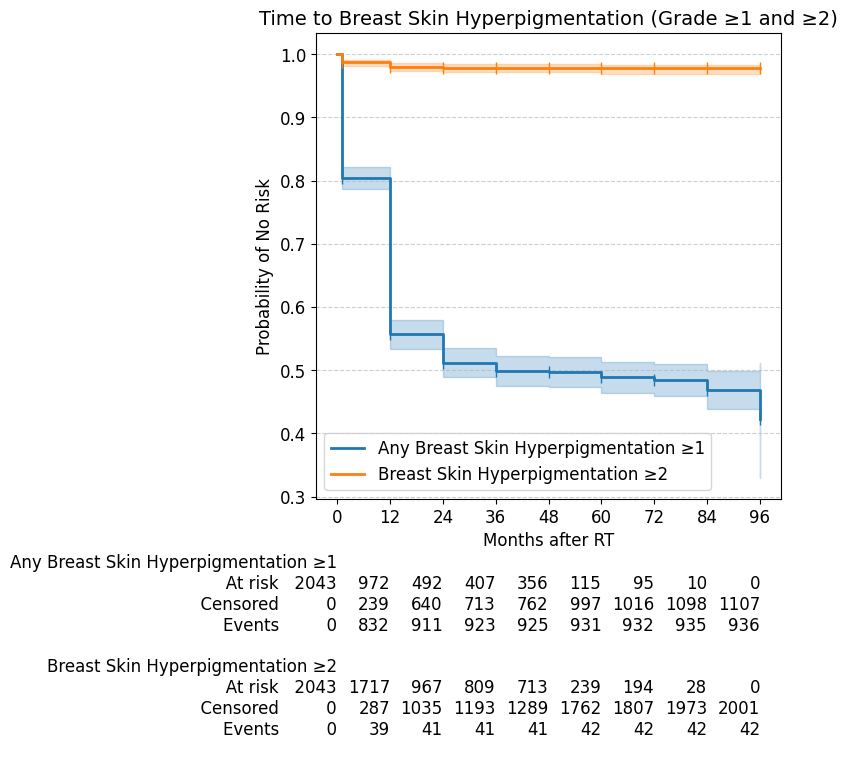

In [47]:
kaplanmeier(n_df, 'Timehyperpigmentation1', 'Timehyperpigmentation2', 'Eventhyperpigmentation1', 'Eventhyperpigmentation2')

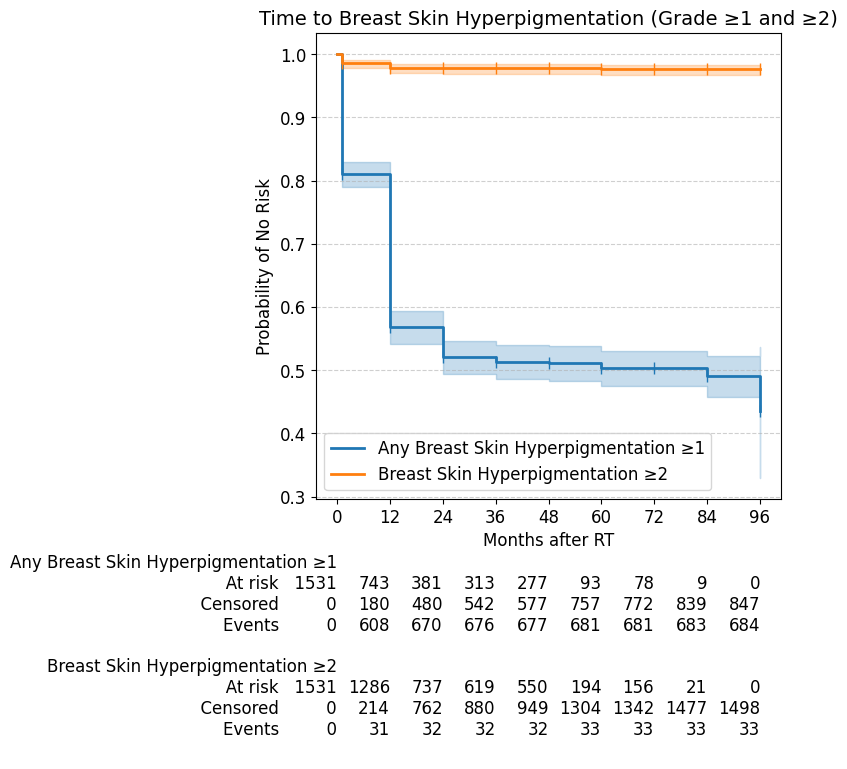

In [48]:
kaplanmeier(n_df_train, 'Timehyperpigmentation1', 'Timehyperpigmentation2', 'Eventhyperpigmentation1', 'Eventhyperpigmentation2')

In [49]:
def kaplanmeier_risk(n_df, Time1, Time2, Event1, Event2, y_lim, y_tick):

  # Clean data (ensure numeric, drop NAs) - REINSTATED
  n_df = n_df.dropna(subset=[Time1, Event1, Time2, Event2])
  n_df[Time1] = pd.to_numeric(n_df[Time1], errors='coerce')
  n_df[Time2] = pd.to_numeric(n_df[Time2], errors='coerce')

  km1 = KaplanMeierFitter()
  km2 = KaplanMeierFitter()

  km1.fit(n_df[Time1], event_observed=n_df[Event1], label=f'{dep} ≥1')
  km2.fit(n_df[Time2], event_observed=n_df[Event2], label=f'{dep} ≥2')

  def km_label(km, name, durations, events):
      n_total = len(durations)
      n_events = int(events.sum())
      try:
          median_time = km.median_survival_time_
          median_str = f"{median_time:.0f} months"
      except:
          median_str = "inf months"
      return f"{name} (n={n_total}, events={n_events}, median={median_str})"

  label1 = km_label(km1, f"Any {dep} (Grade 1+)", n_df[Time1], n_df[Event1])
  label2 = km_label(km2, f"Moderate–severe {dep} (Grade 2+)", n_df[Time2], n_df[Event2])

  # --- Build cumulative risk ---
  fig, ax = plt.subplots(figsize=(10, 8))

  # Get common grid
  time_grid = np.union1d(km1.survival_function_.index, km2.survival_function_.index)
  sf1 = km1.predict(time_grid)
  sf2 = km2.predict(time_grid)

  risk1 = 1 - sf1
  risk2 = 1 - sf2

  # Plot risk (cumulative incidence)
  ax.step(time_grid, risk1, where="post", lw=2, color="tab:blue", label=label1)
  ax.step(time_grid, risk2, where="post", lw=2, color="tab:orange", label=label2)

  time_points = list(range(0, 97, 12))
  ax.set_xticks(time_points)
  add_at_risk_counts(km1, km2, ax=ax, xticks=time_points)

  ax.set_title(f"Cumulative Risk of {dep} by Severity", fontsize=14, fontweight='bold')
  ax.set_xlabel("Months after RT", fontsize=12)
  ax.set_ylabel("Cumulative incidence (risk)", fontsize=12)
  #ax.grid(True, linestyle='--', alpha=0.6)
  ax.grid(True, axis='y', linestyle='-', alpha=0.3)
  ax.legend(loc='upper left', fontsize=9, frameon=False)

  # Force risk scale from 0 to 1 (not 0.8–1.0)
  ax.set_ylim(0, 0.25)
  ax.set_yticks(np.arange(0, y_lim, y_tick))

  plt.tight_layout()
  plt.show()
  overlap_cases = n_df[(n_df[Event1] == 1) & (n_df[Event2] == 1)]
  print("Number of overlapping cases:", len(overlap_cases))
  print("Events ≥1:", n_df[Event1].sum())
  print("Events ≥2:", n_df[Event2].sum())
  print("Overlap (should equal Events ≥2):", len(overlap_cases))

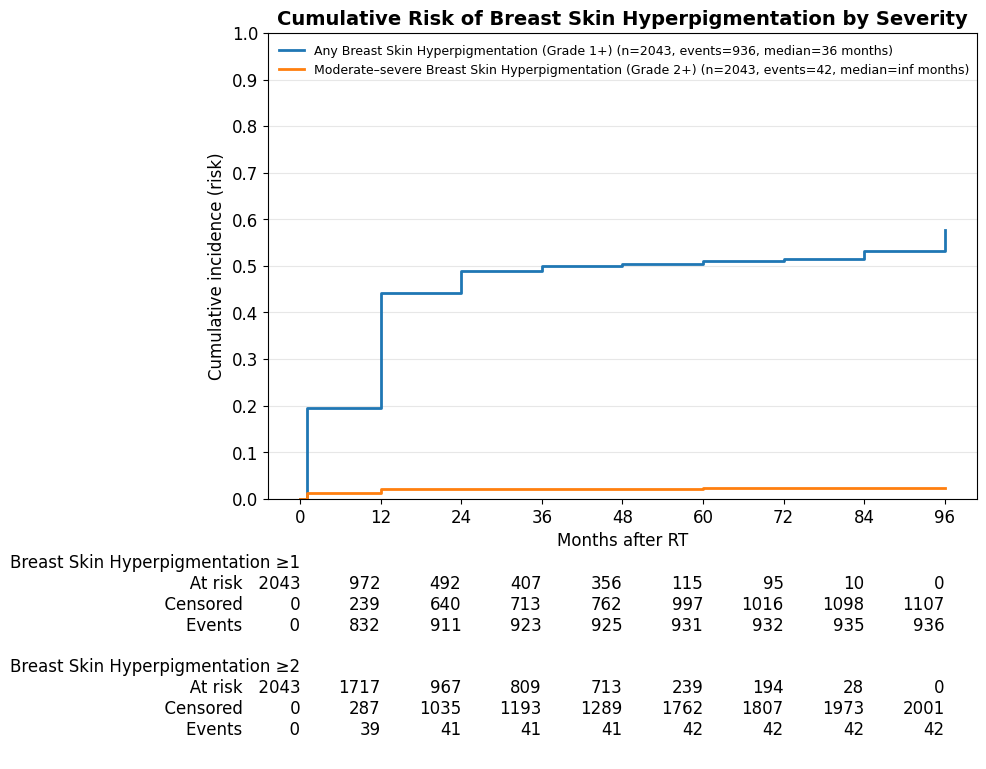

Number of overlapping cases: 42
Events ≥1: 936.0
Events ≥2: 42.0
Overlap (should equal Events ≥2): 42


In [50]:
kaplanmeier_risk(n_df, 'Timehyperpigmentation1', 'Timehyperpigmentation2', 'Eventhyperpigmentation1', 'Eventhyperpigmentation2', 1.1, 0.1)

In [51]:
endpoints_rate(n_df, 'Eventhyperpigmentation1', 'Eventhyperpigmentation2', 'Timehyperpigmentation1', 'Timehyperpigmentation2')

Endpoint 1 event rate: 45.81497797356828 %
Endpoint 2 event rate: 2.0558002936857562 %
Patients where severe < mild: 0
Endpoint 1 event count: 936.0
Endpoint 2 event count: 42.0


In [52]:
result = summarize_nested_events(
    n_df,event1_col='Eventhyperpigmentation1',  event2_col='Eventhyperpigmentation2',
    id_col='subject_id',
    show_cols=['Timehyperpigmentation1', 'Timehyperpigmentation2'],
    label=dep
)

SUMMARY OF BREAST SKIN HYPERPIGMENTATION GROUPS
----------------------------------------
No breast skin hyperpigmentation:            1107
Mild only (Grade 1):    894
Moderate–severe (≥2):  42
Inconsistent cases:    0   <-- should be 0
----------------------------------------
Total patients:        2043

Moderate–severe Breast Skin Hyperpigmentation cases (Grade ≥2):
     subject_id  Timehyperpigmentation1  Timehyperpigmentation2
329   RQ05068-5                    12.0                    12.0
556   RQ14009-1                     1.0                     1.0
941   RQ14693-8                    12.0                    12.0
948   RQ14711-9                     1.0                    12.0
1000  RQ14789-5                    12.0                    12.0
1101  RQ22186-9                     1.0                     1.0
1199  RQ25010-6                     1.0                    12.0
1200  RQ25012-3                     1.0                    12.0
1209  RQ25030-3                     1.0               

Based on the event count we deside if worth to do survival or not, for example we need at least 10 event for each predictor and if we set the feat to 20 we need at least 200 to +400 events

In [53]:
n_df.shape

(2067, 608)

In [54]:
print(list(n_df.columns))

['subject_id', 'date', 'height_cm', 'weight_at_cancer_diagnosis_kg', 'age', 'bra_cup_size', 'band_size', 'smoker', 'smoking_duration_yrs', 'tobacco_products_per_day', 'smoking_time_since_quitting_yrs', 'tobacco_product', 'alcohol_intake', 'alcohol_previous_consumption', 'alcohol_current_consumption', 'menopausal_status', 'monopause_age_yrs', 'hormone_replacement_therapy', 'diabetes', 'diabetes_duration_yrs', 'history_of_heart_disease', 'history_of_heart_disease_duration_yrs', 'ra', 'ra_duration_yrs', 'systemic_lupus_erythematosus', 'systemic_lupus_erythematosus_duration_yrs', 'other_collagen_vascular_disease', 'other_collagen_vascular_disease_duration_yrs', 'hypertension', 'hypertension_duration_yrs', 'depression', 'depression_duration_yrs', 'antidiabetic', 'antidiabetic_duration_yrs', 'ace_inhibitor', 'ace_inhibitor_duration_yrs', 'other_antihypertensive_drug', 'other_antihypertensive_drug_duration_yrs', 'on_statin', 'on_statin_duration_yrs', 'other_lipid_lowering_drugs', 'other_lipid

In [55]:
n_df= remove_missing(n_df, 10)
#n_df_train= remove_missing(n_df_train, 50)
#n_df_test= remove_missing(n_df_test, 50)

Before removinig columns with highly missing (2067, 608)
After removinig columns with highly missing (2067, 213)


In [56]:
print(list(n_df.columns))

['subject_id', 'date', 'height_cm', 'weight_at_cancer_diagnosis_kg', 'age', 'bra_cup_size', 'smoker', 'alcohol_intake', 'menopausal_status', 'diabetes', 'history_of_heart_disease', 'ra', 'systemic_lupus_erythematosus', 'other_collagen_vascular_disease', 'hypertension', 'depression', 'antidiabetic', 'ace_inhibitor', 'other_antihypertensive_drug', 'on_statin', 'other_lipid_lowering_drugs', 'amiodarone', 'analgesics', 'antidepressant', 'breast_cancer_family_history_1st_degree', 'ethnicity', 'Sequence Num_x', 'Date', 'Visit_y', 'surgery', 'surgery_type', 'surgery_date', 'nodes_involved', 'post_operative_haematoma', 'post_operative_oedema', 'post_operative_infection', 'delayed_healing', 'tumour_side_of_primary', 'tumour_locality', 'tumour_histological_grade', 'tumour_histological_type', 't_stage', 'n_stage', 'm_stage', 'er_status', 'chemo_neo_adjuvant', 'chemo_adjuvant', 'sys_treatment', 'radio_breast_startdate', 'radio_breast_enddate', 'radio_interrupted', 'radio_breast_dose_Gy', 'radio_ph

In [62]:
# Also removed other endpoint manually
# manually removed these features as it un informative:
# [idd, fid, radio_breast_startdate, radio_breast_enddate, surgery_date, Site, Sequence Num_y, Sequence Num_x, Sequence Num_baseline, m_stage, Visit_baseline']

Kept_feat= ['subject_id', 'height_cm', 'weight_at_cancer_diagnosis_kg', 'age', 'bra_cup_size', 'smoker', 'alcohol_intake', 'menopausal_status', 'diabetes', 'history_of_heart_disease', 'ra', 'systemic_lupus_erythematosus', 'other_collagen_vascular_disease', 'hypertension', 'depression', 'antidiabetic', 'ace_inhibitor', 'other_antihypertensive_drug', 'on_statin', 'other_lipid_lowering_drugs', 'amiodarone', 'analgesics', 'antidepressant', 'breast_cancer_family_history_1st_degree', 'ethnicity', 'surgery', 'surgery_type', 'nodes_involved', 'post_operative_haematoma', 'post_operative_oedema', 'post_operative_infection', 'delayed_healing', 'tumour_side_of_primary', 'tumour_locality', 'tumour_histological_grade', 'tumour_histological_type', 't_stage', 'n_stage', 'er_status', 'chemo_neo_adjuvant', 'chemo_adjuvant', 'sys_treatment', 'radio_interrupted', 'radio_breast_dose_Gy', 'radio_photon_dose_MV', 'radio_breast_fractions', 'radio_breast_ct_volume_cm3', 'radio_breast_delineation', 'radio_skin_max_dose_Gy', 'radio_skin_delineation', 'radio_heart_mean_dose_Gy', 'radio_heart_delineation', 'radio_hot_spots_107', 'radio_ipsilateral_lung_mean_Gy', 'radio_imrt', 'radio_treatment_pos', 'radio_3d', 'radio_treated_breast', 'axillary_levels', 'radio_supraclavicular_fossa', 'radio_boost', 'radio_breast_fractions_dose_per_fraction_Gy', 'radio_breast_fractions_per_week', 'radio_photon_2nd','CRFversion_baseline', 'breast_atrophy_baseline', 'breast_nipple_retraction_baseline', 'breast_oedema_baseline', 'breast_skin_ulceration_baseline', 'breast_telangiectasia_tumour_bed_baseline', 'breast_telangiectasia_outside_tumour_bed_baseline', 'breast_skin_induration_tumour_bed_baseline', 'breast_skin_induration_outside_tumour_bed_baseline', 'breast_erythema_baseline', 'breast_arm_lymphodema_baseline', 'breast_skin_hyperpigmentation_baseline', 'breast_pneumontis_baseline', 'breast_pain_baseline', 'breast_swollen_arm_baseline', 'breast_left_arm_circumfrence_mm_baseline', 'breast_right_arm_circumfrence_mm_baseline', 'bmi', 'chr3_181186466_C_T', 'rs10070847', 'rs11386090', 'rs11869785', 'rs11958262', 'rs12978904', 'rs13095652', 'rs13340962', 'rs13340980', 'rs1500985', 'rs150098500', 'rs150098502', 'rs150098504', 'rs150098507', 'rs150098515', 'rs150098522', 'rs150098524', 'rs150098526', 'rs150098528', 'rs150098537', 'rs150098540', 'rs150098544', 'rs150098554', 'rs150098561', 'rs150098569', 'rs150098570', 'rs150098571', 'rs150098572', 'rs150098579', 'rs150098580', 'rs150098581', 'rs150098582', 'rs150098586', 'rs150098594', 'rs150098597', 'rs280534', 'rs2805343', 'rs2874925', 'rs35106661', 'rs4395631', 'rs4540159', 'rs4571472', 'rs56674262', 'rs59000154', 'rs599291', 'rs71628527', 'rs7222874', 'rs75703465', 'rs8074709', 'rs8078812', 'rs8078882', 'rs9807090', 'rs9807104', 'rs9913215', 'Timehyperpigmentation1', 'Eventhyperpigmentation1']


In [63]:
# calculate uniq data
def Cuniq(df, x):
  print(df[x].sort_values().value_counts())

In [64]:
Cuniq(n_df_train,'m_stage')
#

m_stage
M0    935
MX    486
Name: count, dtype: int64


In [65]:
re_df= n_df[Kept_feat]
re_df_train= n_df_train[Kept_feat]
re_df_test= n_df_test[Kept_feat]

In [ ]:
# in re_df dataframe, i can split it to training and test based on train, test id lists

In [66]:
pairwisecorr(re_df_train, threshold=0.70)

Highly correlated feature pairs (correlation > 0.70):
Features: weight_at_cancer_diagnosis_kg and radio_breast_ct_volume_cm3, Correlation: 0.73
Features: weight_at_cancer_diagnosis_kg and breast_left_arm_circumfrence_mm_baseline, Correlation: 0.81
Features: weight_at_cancer_diagnosis_kg and breast_right_arm_circumfrence_mm_baseline, Correlation: 0.82
Features: weight_at_cancer_diagnosis_kg and bmi, Correlation: 0.92
Features: diabetes and antidiabetic, Correlation: 0.89
Features: hypertension and other_antihypertensive_drug, Correlation: 0.79
Features: depression and antidepressant, Correlation: 0.87
Features: tumour_side_of_primary and radio_treated_breast, Correlation: 1.00
Features: radio_breast_dose_Gy and radio_breast_fractions, Correlation: 0.98
Features: radio_breast_dose_Gy and radio_skin_max_dose_Gy, Correlation: 0.76
Features: radio_breast_dose_Gy and radio_breast_fractions_dose_per_fraction_Gy, Correlation: 0.85
Features: radio_breast_fractions and radio_skin_max_dose_Gy, Co

In [67]:

uncorr_feat= ['subject_id', 'height_cm', 'weight_at_cancer_diagnosis_kg', 'age', 'bra_cup_size', 'smoker', 'alcohol_intake', 'menopausal_status', 'diabetes', 'history_of_heart_disease', 'ra', 'systemic_lupus_erythematosus', 'other_collagen_vascular_disease', 'hypertension', 'depression', 'ace_inhibitor', 'on_statin', 'other_lipid_lowering_drugs', 'amiodarone', 'analgesics', 'breast_cancer_family_history_1st_degree', 'ethnicity', 'surgery', 'surgery_type', 'nodes_involved', 'post_operative_haematoma', 'post_operative_oedema', 'post_operative_infection', 'delayed_healing', 'tumour_locality', 'tumour_histological_grade', 'tumour_histological_type', 't_stage', 'n_stage', 'er_status', 'chemo_neo_adjuvant', 'chemo_adjuvant', 'sys_treatment', 'radio_interrupted', 'radio_breast_dose_Gy', 'radio_photon_dose_MV', 'radio_breast_delineation', 'radio_skin_delineation', 'radio_heart_mean_dose_Gy', 'radio_heart_delineation', 'radio_hot_spots_107', 'radio_ipsilateral_lung_mean_Gy', 'radio_imrt', 'radio_treatment_pos', 'radio_treated_breast', 'axillary_levels', 'radio_supraclavicular_fossa', 'radio_boost', 'radio_breast_fractions_per_week', 'radio_photon_2nd', 'CRFversion_baseline', 'breast_atrophy_baseline', 'breast_nipple_retraction_baseline', 'breast_oedema_baseline', 'breast_skin_ulceration_baseline', 'breast_telangiectasia_tumour_bed_baseline', 'breast_telangiectasia_outside_tumour_bed_baseline', 'breast_skin_induration_tumour_bed_baseline', 'breast_skin_induration_outside_tumour_bed_baseline', 'breast_erythema_baseline', 'breast_arm_lymphodema_baseline', 'breast_skin_hyperpigmentation_baseline', 'breast_pneumontis_baseline', 'breast_pain_baseline', 'breast_swollen_arm_baseline', 'chr3_181186466_C_T', 'rs10070847', 'rs11386090', 'rs11869785', 'rs11958262', 'rs12978904', 'rs1500985', 'rs150098500', 'rs150098502', 'rs150098504', 'rs150098507', 'rs150098515', 'rs150098522', 'rs150098524', 'rs150098526', 'rs150098528', 'rs150098537', 'rs150098540', 'rs150098544', 'rs150098554', 'rs150098561', 'rs150098569', 'rs150098570', 'rs150098571', 'rs150098572', 'rs150098579', 'rs150098580', 'rs150098581', 'rs150098582', 'rs150098586', 'rs150098594', 'rs150098597', 'rs280534', 'rs2805343', 'rs35106661', 'rs71628527', 'rs75703465', 'Timehyperpigmentation1', 'Eventhyperpigmentation1']



uncorr_feat_c=['subject_id', 'height_cm', 'weight_at_cancer_diagnosis_kg', 'age', 'bra_cup_size', 'smoker', 'alcohol_intake', 'menopausal_status', 'diabetes', 'history_of_heart_disease', 'ra', 'systemic_lupus_erythematosus', 'other_collagen_vascular_disease', 'hypertension', 'depression', 'ace_inhibitor', 'on_statin', 'other_lipid_lowering_drugs', 'amiodarone', 'analgesics', 'breast_cancer_family_history_1st_degree', 'ethnicity', 'surgery', 'surgery_type', 'nodes_involved', 'post_operative_haematoma', 'post_operative_oedema', 'post_operative_infection', 'delayed_healing', 'tumour_locality', 'tumour_histological_grade', 'tumour_histological_type', 't_stage', 'n_stage', 'er_status', 'chemo_neo_adjuvant', 'chemo_adjuvant', 'sys_treatment', 'radio_interrupted', 'radio_breast_dose_Gy', 'radio_photon_dose_MV', 'radio_breast_delineation', 'radio_skin_delineation', 'radio_heart_mean_dose_Gy', 'radio_heart_delineation', 'radio_hot_spots_107', 'radio_ipsilateral_lung_mean_Gy', 'radio_imrt', 'radio_treatment_pos', 'radio_treated_breast', 'axillary_levels', 'radio_supraclavicular_fossa', 'radio_boost', 'radio_breast_fractions_per_week', 'radio_photon_2nd', 'CRFversion_baseline', 'breast_atrophy_baseline', 'breast_nipple_retraction_baseline', 'breast_oedema_baseline', 'breast_skin_ulceration_baseline', 'breast_telangiectasia_tumour_bed_baseline', 'breast_telangiectasia_outside_tumour_bed_baseline', 'breast_skin_induration_tumour_bed_baseline', 'breast_skin_induration_outside_tumour_bed_baseline', 'breast_erythema_baseline', 'breast_arm_lymphodema_baseline', 'breast_skin_hyperpigmentation_baseline', 'breast_pneumontis_baseline', 'breast_pain_baseline', 'breast_swollen_arm_baseline', 'Timehyperpigmentation1', 'Eventhyperpigmentation1']


uncorr_feat_snp=['subject_id','chr3_181186466_C_T', 'rs10070847', 'rs11386090', 'rs11869785', 'rs11958262', 'rs12978904', 'rs1500985', 'rs150098500', 'rs150098502', 'rs150098504', 'rs150098507', 'rs150098515', 'rs150098522', 'rs150098524', 'rs150098526', 'rs150098528', 'rs150098537', 'rs150098540', 'rs150098544', 'rs150098554', 'rs150098561', 'rs150098569', 'rs150098570', 'rs150098571', 'rs150098572', 'rs150098579', 'rs150098580', 'rs150098581', 'rs150098582', 'rs150098586', 'rs150098594', 'rs150098597', 'rs280534', 'rs2805343', 'rs35106661', 'rs71628527', 'rs75703465', 'Timehyperpigmentation1', 'Eventhyperpigmentation1'] # 37 total snips


In [ ]:
# using full data
#n_df1= re_df[uncorr_feat]
#n_df1_c= n_df_train[uncorr_feat_c]
#n_df1_s= n_df_train[uncorr_feat_snp]

In [68]:
n_df1_train= n_df_train[uncorr_feat]
n_df1_train_c= n_df_train[uncorr_feat_c]
n_df1_train_s= n_df_train[uncorr_feat_snp]

In [69]:
n_df1_test= n_df_test[uncorr_feat]
n_df1_test_c= n_df_test[uncorr_feat_c]
n_df1_test_s= n_df_test[uncorr_feat_snp]

##Fit models :Classical Cox

In [70]:
import pandas as pd
import numpy as np
from sklearn.inspection import permutation_importance

from sklearn.preprocessing import LabelEncoder
from sksurv.ensemble import RandomSurvivalForest
from lifelines import CoxPHFitter
import matplotlib.pyplot as plt


def autoFeatRSFCox(
    df,
    m=20,
    duration_col='TimeAtrophy1',
    event_col='EventAtrophy1'):

    # =====================================================
    # 1. Remove ID column
    df = df.drop(columns=['subject_id'],
        errors='ignore').copy()


    # =====================================================
    # 2. Remove patients without survival information
    # =====================================================

    df = df.dropna(subset=[duration_col, event_col]).copy()


    # =====================================================
    # 3. Separate predictors and survival outcome
    # =====================================================

    X = df.drop(
        columns=[duration_col, event_col])

    y_time = df[duration_col]
    y_event = df[event_col].astype(bool)


    # =====================================================
    # 4. Handle missing predictor values
    # =====================================================

    # Complete case approach
    mask = X.notna().all(axis=1)

    X = X.loc[mask].copy()

    y_time = y_time.loc[mask]
    y_event = y_event.loc[mask]


    # =====================================================
    # 5. Encode categorical variables
    # =====================================================

    X_encoded = X.copy()

    encoders = {}

    for col in X_encoded.columns:

        if (
            X_encoded[col].dtype == 'object'
            or str(X_encoded[col].dtype) == 'category'
        ):

            le = LabelEncoder()

            X_encoded[col] = le.fit_transform(
                X_encoded[col].astype(str)
            )

            encoders[col] = le


    # =====================================================
    # 6. Create survival structured array
    # =====================================================

    y_structured = np.array(
        list(
            zip(
                y_event,
                y_time
            )
        ),
        dtype=[
            ('event', '?'),
            ('time', '<f8')
        ]
    )


    # =====================================================
    # 7. Random Survival Forest feature importance
    # =====================================================

    rsf = RandomSurvivalForest(
    n_estimators=200,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=12,
    n_jobs=-1)

    print("Training Random Survival Forest...")

    rsf.fit(
        X_encoded,
        y_structured
    )




# =====================================================
# Feature importance using permutation importanc
    perm = permutation_importance(
    rsf,
    X_encoded,
    y_structured,
    n_repeats=20,
    random_state=12,
    n_jobs=-1)


    importance = pd.Series(perm.importances_mean, index=X_encoded.columns).sort_values(ascending=False)


    top_features = (importance.head(m)
        .index
        .tolist())


    print("\n==============================")
    print(f"Top {m} features:")
    print("==============================")

    for i, f in enumerate(top_features, 1):
        print(
            i,
            f,
            round(importance[f], 4))

    print(top_features)
    # =====================================================
    # 8. Prepare Cox dataset
    # =====================================================

    cox_df = pd.concat(
        [
            pd.DataFrame({
                duration_col: y_time,
                event_col: y_event.astype(int)}),
            X_encoded[top_features]
        ],
        axis=1)


    print("\n================================")
    print("Cox dataset")
    print("================================")

    print(
        "Patients:",
        len(cox_df)    )

    print(
        "Events:",
        cox_df[event_col].sum()    )


    # =====================================================
    # 9. Cox proportional hazards model
    # =====================================================

    cph = CoxPHFitter(
        penalizer=0.1    )


    cph.fit(
        cox_df,
        duration_col=duration_col,
        event_col=event_col    )


    print("\n================================")
    print("Cox model results")
    print("================================")

    cph.print_summary()


    # =====================================================
    # 10. Plot hazard ratios
    # =====================================================

    plt.figure(
        figsize=(10,8)    )

    cph.plot()

    plt.title(        "Cox Hazard Ratios - Selected Features"    )

    plt.show()


    return {
        "RSF_model": rsf,
        "Cox_model": cph,
        "Top_features": top_features,
        "Feature_importance": importance,
        "Cox_dataset": cox_df,
        "Encoders": encoders    }

Training Random Survival Forest...

Top 20 features:
1 radio_heart_mean_dose_Gy 0.0242
2 radio_ipsilateral_lung_mean_Gy 0.0141
3 rs35106661 0.0129
4 surgery_type 0.0118
5 radio_breast_dose_Gy 0.0115
6 rs11958262 0.0105
7 rs11386090 0.0101
8 age 0.0081
9 alcohol_intake 0.0076
10 rs11869785 0.0074
11 rs10070847 0.0073
12 rs71628527 0.0071
13 rs75703465 0.0064
14 radio_imrt 0.0062
15 weight_at_cancer_diagnosis_kg 0.0061
16 rs2805343 0.0056
17 rs12978904 0.0053
18 radio_boost 0.0051
19 height_cm 0.005
20 rs280534 0.0046
['radio_heart_mean_dose_Gy', 'radio_ipsilateral_lung_mean_Gy', 'rs35106661', 'surgery_type', 'radio_breast_dose_Gy', 'rs11958262', 'rs11386090', 'age', 'alcohol_intake', 'rs11869785', 'rs10070847', 'rs71628527', 'rs75703465', 'radio_imrt', 'weight_at_cancer_diagnosis_kg', 'rs2805343', 'rs12978904', 'radio_boost', 'height_cm', 'rs280534']

Cox dataset
Patients: 1065
Events: 478

Cox model results


<lifelines.CoxPHFitter: fitted with 1065 total observations, 587 right-censored observations>
             duration col = 'Timehyperpigmentation1'
                event col = 'Eventhyperpigmentation1'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 1065
number of events observed = 478
   partial log-likelihood = -3015.80
         time fit was run = 2026-08-10 11:48:08 UTC

---
                                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                       
radio_heart_mean_dose_Gy        0.06      1.06      0.02            0.03            0.09                1.03                1.10
radio_ipsilateral_lung_mean_Gy  0.02      1.02      0.01            0.00            0.04                1.00                1.04
rs35106661                      0.15      1.16      0.06            0.03            0.27                1.03                1.31
surgery_type                   -0.44      0.65      0.11           -0.65           -0.22                0.52                0.80
radio_breast_dose_Gy            0.01      1.01      0.01           -0.01            0.03                0.99                1.03
rs11958262                      0.16      1.18      0.06            0.05            0.28                1.05                1.32
rs11386090                     -0.20      0.81      0.06           -0.32           -0.09                0.72                0.92
age                            -0.01      0.99      0.00           -0.02           -0.00                0.98                1.00
alcohol_intake                 -0.04      0.96      0.03           -0.10            0.01                0.90                1.01
rs11869785                      0.23      1.26      0.06            0.11            0.35                1.11                1.42
rs10070847                      0.23      1.26      0.06            0.10            0.36                1.11                1.43
rs71628527                      0.49      1.63      0.13            0.23            0.75                1.26                2.13
rs75703465                     -0.13      0.88      0.07           -0.27            0.01                0.76                1.01
radio_imrt                     -0.15      0.86      0.10           -0.35            0.04                0.71                1.04
weight_at_cancer_diagnosis_kg   0.01      1.01      0.00            0.00            0.01                1.00                1.01
rs2805343                       0.00      1.00      0.08           -0.15            0.16                0.86                1.17
rs12978904                     -0.13      0.88      0.06           -0.25           -0.00                0.78                1.00
radio_boost                     0.43      1.53      0.12            0.19            0.66                1.21                1.94
height_cm                      -0.01      0.99      0.01           -0.02            0.00                0.98                1.00
rs280534                       -0.16      0.85      0.06           -0.28           -0.04                0.76                0.96

                                cmp to     z      p  -log2(p)
covariate                                                    
radio_heart_mean_dose_Gy          0.00  4.04 <0.005     14.17
radio_ipsilateral_lung_mean_Gy    0.00  2.04   0.04      4.60
rs35106661                        0.00  2.49   0.01      6.28
surgery_type                      0.00 -3.92 <0.005     13.49
radio_breast_dose_Gy              0.00  1.00   0.32      1.66
rs11958262                        0.00  2.79   0.01      7.55
rs11386090                        0.00 -3.43 <0.005     10.71
age                               0.00 -2.70   0.01      7.17
alcohol_intake                    0.00 -1.47   0.14      2.82
rs11869785         

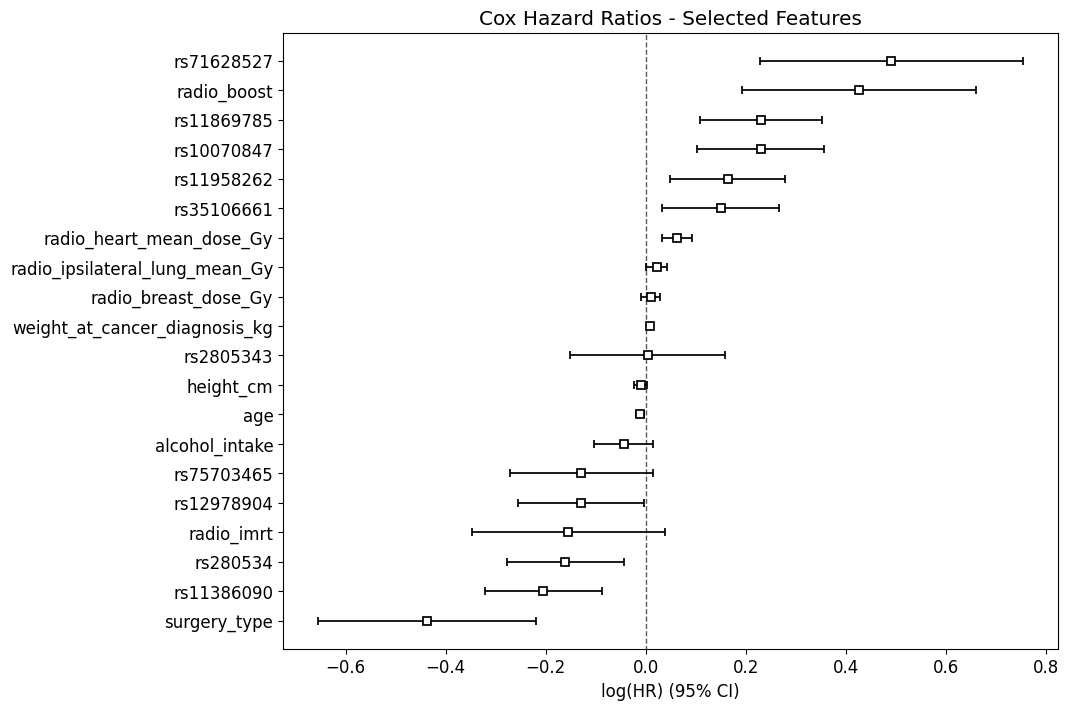

In [72]:
# Re-running the survival analysis with the corrected feature importance attribute
results = autoFeatRSFCox(
    n_df1_train,
    m=20,
    duration_col='Timehyperpigmentation1',
    event_col='Eventhyperpigmentation1'
)

Training Random Survival Forest...

Top 20 features:
1 radio_heart_mean_dose_Gy 0.0497
2 radio_ipsilateral_lung_mean_Gy 0.0306
3 age 0.0285
4 weight_at_cancer_diagnosis_kg 0.0241
5 radio_breast_dose_Gy 0.0213
6 surgery_type 0.021
7 height_cm 0.017
8 alcohol_intake 0.0146
9 radio_imrt 0.0116
10 radio_boost 0.0095
11 smoker 0.0084
12 t_stage 0.0083
13 bra_cup_size 0.0077
14 breast_skin_induration_tumour_bed_baseline 0.0065
15 radio_hot_spots_107 0.0057
16 tumour_histological_grade 0.0056
17 radio_treated_breast 0.0055
18 tumour_histological_type 0.005
19 radio_skin_delineation 0.0048
20 breast_atrophy_baseline 0.0047
['radio_heart_mean_dose_Gy', 'radio_ipsilateral_lung_mean_Gy', 'age', 'weight_at_cancer_diagnosis_kg', 'radio_breast_dose_Gy', 'surgery_type', 'height_cm', 'alcohol_intake', 'radio_imrt', 'radio_boost', 'smoker', 't_stage', 'bra_cup_size', 'breast_skin_induration_tumour_bed_baseline', 'radio_hot_spots_107', 'tumour_histological_grade', 'radio_treated_breast', 'tumour_histolo

<lifelines.CoxPHFitter: fitted with 1067 total observations, 588 right-censored observations>
             duration col = 'Timehyperpigmentation1'
                event col = 'Eventhyperpigmentation1'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 1067
number of events observed = 479
   partial log-likelihood = -3058.14
         time fit was run = 2026-08-10 11:49:11 UTC

---
                                            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                   
radio_heart_mean_dose_Gy                    0.06      1.06      0.02            0.02            0.09                1.02                1.09
radio_ipsilateral_lung_mean_Gy              0.02      1.02      0.01           -0.00            0.04                1.00                1.04
age                                        -0.01      0.99      0.00           -0.02           -0.00                0.98                1.00
weight_at_cancer_diagnosis_kg               0.01      1.01      0.00            0.00            0.01                1.00                1.01
radio_breast_dose_Gy                        0.01      1.01      0.01           -0.01            0.03                0.99                1.03
surgery_type                               -0.43      0.65      0.11           -0.65           -0.21                0.52                0.81
height_cm                                  -0.01      0.99      0.01           -0.02            0.00                0.98                1.00
alcohol_intake                             -0.05      0.96      0.03           -0.10            0.01                0.90                1.01
radio_imrt                                 -0.16      0.85      0.10           -0.36            0.04                0.70                1.04
radio_boost                                 0.48      1.61      0.12            0.24            0.72                1.27                2.05
smoker                                      0.05      1.05      0.04           -0.03            0.13                0.97                1.14
t_stage                                    -0.00      1.00      0.03           -0.07            0.06                0.94                1.06
bra_cup_size                                0.03      1.03      0.04           -0.05            0.11                0.95                1.12
breast_skin_induration_tumour_bed_baseline  0.07      1.07      0.07           -0.08            0.21                0.93                1.23
radio_hot_spots_107                         0.16      1.17      0.10           -0.05            0.36                0.95                1.44
tumour_histological_grade                  -0.03      0.97      0.06           -0.15            0.10                0.86                1.10
radio_treated_breast                       -0.13      0.88      0.09           -0.30            0.04                0.74                1.05
tumour_histological_type                   -0.01      0.99      0.03           -0.08            0.05                0.92                1.05
radio_skin_delineation                      0.08      1.08      0.13           -0.17            0.33                0.85                1.39
breast_atrophy_baseline                    -0.05      0.95      0.07           -0.19            0.09                0.82                1.09

                                            cmp to     z      p  -log2(p)
covariate                                                                
radio_heart_mean_dose_Gy                      0.00  3.28 <0.005      9.92
radio_ipsilateral_lung_mean_Gy                0.00  1.77   0.08      3.71
age                                           0.00 -2.37   0.02      5.81
weight_at_cancer_diagnosis_kg                 0.00  2.63   0.01    

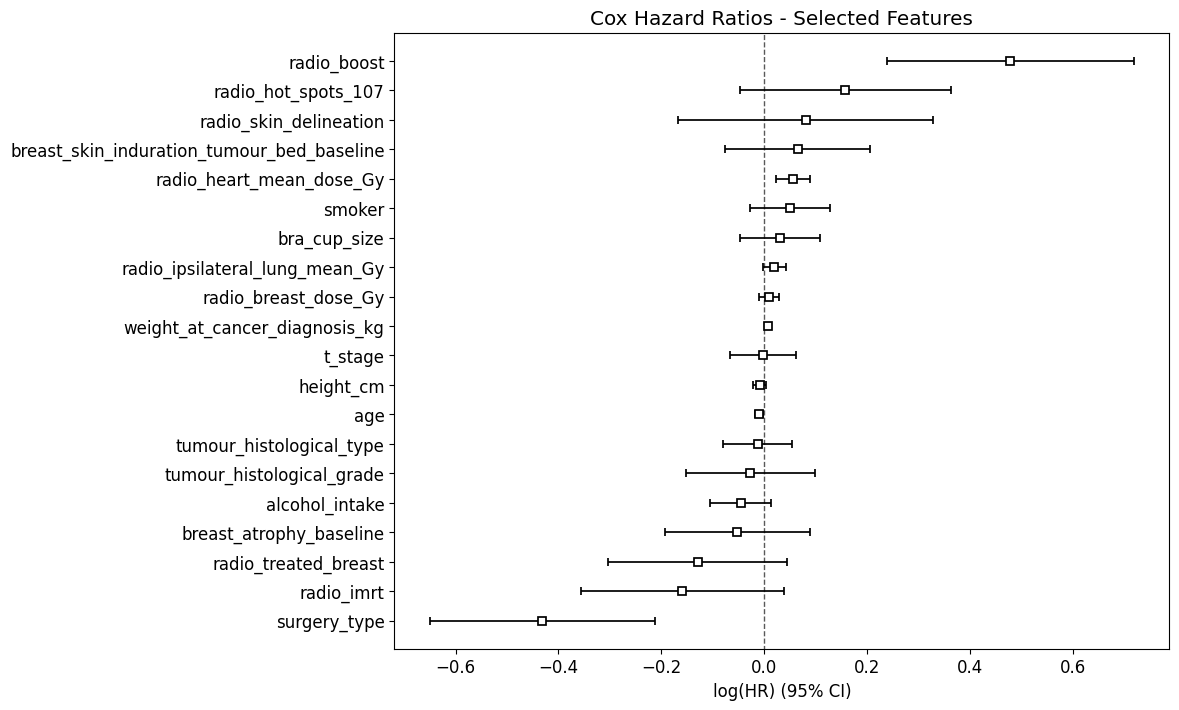

In [73]:
results = autoFeatRSFCox(
    n_df1_train_c,
    m=20,
    duration_col='Timehyperpigmentation1',
    event_col='Eventhyperpigmentation1'
)

Training Random Survival Forest...

Top 5 features:
1 rs11958262 0.0636
2 rs35106661 0.0358
3 rs75703465 0.0355
4 rs11386090 0.035
5 rs11869785 0.033
['rs11958262', 'rs35106661', 'rs75703465', 'rs11386090', 'rs11869785']

Cox dataset
Patients: 1529
Events: 683

Cox model results


<lifelines.CoxPHFitter: fitted with 1529 total observations, 846 right-censored observations>
             duration col = 'Timehyperpigmentation1'
                event col = 'Eventhyperpigmentation1'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 1529
number of events observed = 683
   partial log-likelihood = -4696.30
         time fit was run = 2026-08-10 12:36:27 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
rs11958262  0.24      1.27      0.05            0.14            0.33                1.15                1.40
rs35106661  0.12      1.13      0.05            0.02            0.22                1.02                1.24
rs75703465 -0.21      0.81      0.06           -0.33           -0.09                0.72                0.91
rs11386090 -0.20      0.82      0.05           -0.30           -0.10                0.74                0.90
rs11869785  0.24      1.27      0.05            0.14            0.34                1.15                1.41

            cmp to     z      p  -log2(p)
covariate                                
rs11958262    0.00  4.75 <0.005     18.91
rs35106661    0.00  2.46   0.01      6.16
rs75703465    0.00 -3.48 <0.005     10.96
rs11386090    0.00 -4.01 <0.005     14.00
rs11869785    0.00  4.58 <0.005     17.70
---
Concordance = 0.62
Partial AIC = 9402.61
log-likelihood ratio test = 76.47 on 5 df
-log2(p) of ll-ratio test = 47.63

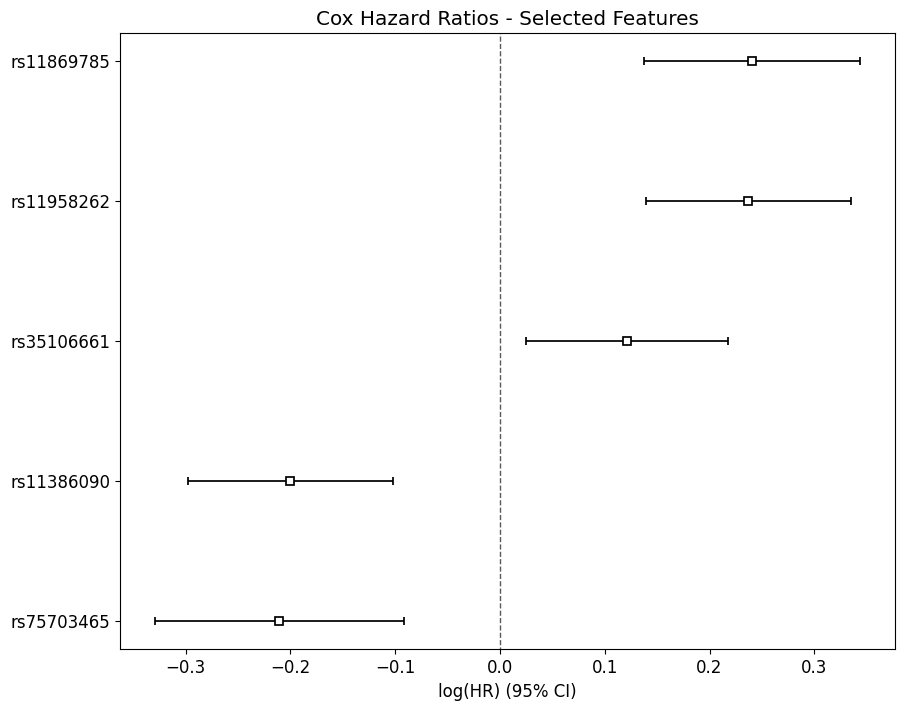

In [98]:
results = autoFeatRSFCox(
    n_df1_train_s,
    m=5,
    duration_col='Timehyperpigmentation1',
    event_col='Eventhyperpigmentation1'
)

In [75]:
import pandas as pd
import numpy as np
from lifelines import CoxPHFitter
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold

def lassoCoxFeatureSelection(
    df,
    duration_col='TimeAtrophy1',
    event_col='EventAtrophy1',
    l1_penalty=0.5,
    l1_ratio=0.9,
    coef_threshold=0.001):
    # 1. Basic Cleaning
    df = df.drop(columns=['subject_id'], errors='ignore').copy()
    df = df.dropna(subset=[duration_col, event_col])

    # 2. Separate predictors
    X = df.drop(columns=[duration_col, event_col])
    y = df[[duration_col, event_col]]

    # 3. Handle missing values (Complete Case)
    mask = X.notna().all(axis=1)
    X = X.loc[mask].copy()
    y = y.loc[mask].copy()

    # 4. Encode categorical variables FIRST (To fix ValueError with strings like 'T1c')
    X_encoded = X.copy()
    for col in X_encoded.columns:
        # Check if the column is categorical or object type
        if X_encoded[col].dtype == 'object' or str(X_encoded[col].dtype) == 'category':
            le = LabelEncoder()
            # Convert to string to handle mixed types before encoding
            X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))

    # 5. Remove constant features
    # Now all data is numeric, fitting VarianceThreshold is safe
    selector = VarianceThreshold(threshold=0)
    X_numeric_data = selector.fit_transform(X_encoded)
    X_numeric = pd.DataFrame(
        X_numeric_data,
        columns=X_encoded.columns[selector.get_support()],
        index=X_encoded.index
    )

    # 6. Standardization
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(
        scaler.fit_transform(X_numeric),
        columns=X_numeric.columns,
        index=X_numeric.index
    )

    # 7. Prepare Cox dataframe
    cox_df = pd.concat([y, X_scaled], axis=1)
    print(f"Fitting Elastic Net Cox on {len(cox_df)} patients and {X_scaled.shape[1]} features...")

    # 8. Fit Elastic Net Cox (L1 + L2 regularization)
    cph = CoxPHFitter(penalizer=l1_penalty, l1_ratio=l1_ratio)
    cph.fit(cox_df, duration_col=duration_col, event_col=event_col, show_progress=True)

    # 9. Results Extraction
    coef = cph.params_
    selected = coef[abs(coef) > coef_threshold]
    selected_features = selected.abs().sort_values(ascending=False).index.tolist()

    print("\nSelected features:")
    for f in selected_features:
        print(f"{f}: coef={round(coef[f], 4)}")

    return {
        "model": cph,
        "selected_features": selected_features,
        "coefficients": coef,
        "dataset": cox_df
    }

In [79]:
lasso_results = lassoCoxFeatureSelection(
    n_df1_train_s,
    duration_col='Timehyperpigmentation1',
    event_col='Eventhyperpigmentation1',
    # L1 penalty controls sparsity; l1_ratio=0.9 provides Elastic Net stability
    l1_penalty=0.1, # if you want more features set it to 0.05, 0.01
    l1_ratio=0.9,
    coef_threshold=0.001
)

Fitting Elastic Net Cox on 1529 patients and 37 features...
Iteration 1: norm_delta = 5.05e-01, step_size = 0.9500, log_lik = -10164.09090, newton_decrement = 9.41e+01, seconds_since_start = 0.0
Iteration 2: norm_delta = 7.59e-02, step_size = 0.9500, log_lik = -8830.24565, newton_decrement = 6.17e+00, seconds_since_start = 0.0
Iteration 3: norm_delta = 3.32e-02, step_size = 0.9500, log_lik = -7863.33959, newton_decrement = 1.16e+00, seconds_since_start = 0.0
Iteration 4: norm_delta = 2.66e-02, step_size = 1.0000, log_lik = -7125.16374, newton_decrement = 3.73e-01, seconds_since_start = 0.0
Iteration 5: norm_delta = 2.69e-02, step_size = 1.0000, log_lik = -6559.71389, newton_decrement = 3.30e-01, seconds_since_start = 0.1
Iteration 6: norm_delta = 3.00e-02, step_size = 0.9800, log_lik = -6126.65037, newton_decrement = 4.38e-01, seconds_since_start = 0.1
Iteration 7: norm_delta = 3.29e-02, step_size = 0.9604, log_lik = -5795.36672, newton_decrement = 5.77e-01, seconds_since_start = 0.1
I

In [102]:
# Best features with RF


combined=['radio_heart_mean_dose_Gy', 'radio_ipsilateral_lung_mean_Gy', 'rs35106661', 'surgery_type', 'radio_breast_dose_Gy', 'rs11958262', 'rs11386090', 'age', 'alcohol_intake', 'rs11869785', 'rs10070847', 'rs71628527', 'rs75703465', 'radio_imrt', 'weight_at_cancer_diagnosis_kg', 'rs2805343', 'rs12978904', 'radio_boost', 'height_cm', 'rs280534']





clinic= ['radio_heart_mean_dose_Gy', 'radio_ipsilateral_lung_mean_Gy', 'age', 'weight_at_cancer_diagnosis_kg', 'radio_breast_dose_Gy', 'surgery_type', 'height_cm', 'alcohol_intake', 'radio_imrt', 'radio_boost', 'smoker', 't_stage', 'bra_cup_size', 'breast_skin_induration_tumour_bed_baseline', 'radio_hot_spots_107', 'tumour_histological_grade', 'radio_treated_breast', 'tumour_histological_type', 'radio_skin_delineation', 'breast_atrophy_baseline']





snp= ['rs11958262', 'rs35106661', 'rs75703465', 'rs11386090', 'rs11869785', 'rs71628527', 'rs12978904', 'rs10070847', 'rs2805343', 'rs150098581', 'rs280534', 'chr3_181186466_C_T', 'rs150098515', 'rs150098572', 'rs150098554', 'rs150098544', 'rs150098594', 'rs150098582', 'rs150098537', 'rs150098500'] # out of 34

#snp= ['rs11958262', 'rs35106661', 'rs75703465', 'rs11386090', 'rs11869785']# tried to take only 5 snips got less results: 62




In [81]:
# Lasso results:
'''
lasso_clinic= [Selected features:
surgery_type: coef=-0.1817
radio_boost: coef=0.0967
radio_heart_mean_dose_Gy: coef=0.0889
radio_ipsilateral_lung_mean_Gy: coef=0.0067
radio_breast_dose_Gy: coef=0.0029]


lasso_combined= [Selected features:
surgery_type: coef=-0.1801
radio_boost: coef=0.0944
radio_heart_mean_dose_Gy: coef=0.0901
radio_ipsilateral_lung_mean_Gy: coef=0.0083
radio_breast_dose_Gy: coef=0.0014]

lasso_SNP= [Selected features:
rs11958262: coef=0.0019
]

'''

'\nlasso_clinic= [Selected features:\nsurgery_type: coef=-0.1817\nradio_boost: coef=0.0967\nradio_heart_mean_dose_Gy: coef=0.0889\nradio_ipsilateral_lung_mean_Gy: coef=0.0067\nradio_breast_dose_Gy: coef=0.0029]\n\n\nlasso_combined= [Selected features:\nsurgery_type: coef=-0.1801\nradio_boost: coef=0.0944\nradio_heart_mean_dose_Gy: coef=0.0901\nradio_ipsilateral_lung_mean_Gy: coef=0.0083\nradio_breast_dose_Gy: coef=0.0014]\n\nlasso_SNP= [Selected features:\nrs11958262: coef=0.0019\n]\n\n'

In [82]:
def create_common_cohort(n_df_train, clinic, combined, snp, duration_col, event_col):

    # ============================================================
    # All variables needed by ANY model
    # ============================================================

    all_features = list(dict.fromkeys(clinic + combined + snp))

    required_cols = (
        ['subject_id', duration_col, event_col]
        + all_features
    )

    # ============================================================
    # Check columns exist
    # ============================================================

    missing_cols = [
        c for c in required_cols
        if c not in n_df_train.columns
    ]

    if missing_cols:
        raise ValueError(
            f"These columns are missing from dataframe:\n{missing_cols}"
        )

    # ============================================================
    # Create common cohort
    # ============================================================

    common_df = n_df_train[required_cols].copy()

    # Remove missing survival outcomes
    common_df = common_df.dropna(
        subset=[duration_col, event_col]
    )

    # Require complete data across ALL model features
    common_df = common_df.dropna(
        subset=all_features
    )

    # Remove duplicated subjects
    common_df = common_df.drop_duplicates(
        subset='subject_id'
    )

    # ============================================================
    # Cohort summary
    # ============================================================

    print("========================================")
    print("COMMON COHORT")
    print("========================================")

    print("Number of patients:", common_df['subject_id'].nunique())
    print("Number of rows:", len(common_df))
    print("Number of events:", common_df[event_col].sum())
    print(
        "Number censored:",
        (common_df[event_col] == 0).sum()
    )

    # ============================================================
    # Verify identical patient sets
    # ============================================================

    clinic_ids = set(common_df['subject_id'])
    combined_ids = set(common_df['subject_id'])
    snp_ids = set(common_df['subject_id'])

    print("\nPatients in each model:")
    print("Clinic:", len(clinic_ids))
    print("Combined:", len(combined_ids))
    print("SNP:", len(snp_ids))

    assert clinic_ids == combined_ids == snp_ids

    return common_df

In [103]:
common_df = create_common_cohort(n_df_train, clinic, combined, snp, duration_col='Timehyperpigmentation1', event_col='Eventhyperpigmentation1')

COMMON COHORT
Number of patients: 1306
Number of rows: 1306
Number of events: 571.0
Number censored: 735

Patients in each model:
Clinic: 1306
Combined: 1306
SNP: 1306


In [104]:
# decoding the features here
from sklearn.preprocessing import LabelEncoder

def encode_dataset(df, duration_col='Time1', event_col='Event1'):
    """
    Encodes all object/category columns in the dataset using LabelEncoder.
    Skips the survival columns.
    Returns a fully numeric dataframe.
    """

    df_encoded = df.copy()

    # Identify columns that require encoding
    cat_cols = [
        col for col in df_encoded.columns
        if col not in [duration_col, event_col]
        and (df_encoded[col].dtype == "object" or str(df_encoded[col].dtype) == "category")
    ]

    for col in cat_cols:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

    print(f"Encoded {len(cat_cols)} categorical columns:")
    print(cat_cols)

    return df_encoded


In [105]:
n_df_clean1= encode_dataset(n_df1_train, duration_col='TimeAtrophy2', event_col='EventAtrophy2')

Encoded 4 categorical columns:
['subject_id', 't_stage', 'n_stage', 'CRFversion_baseline']


In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter
from sklearn.preprocessing import LabelEncoder
import re # Import regex for advanced check

def Classic_Cox_fixed(n_df_clean, feature_list, duration_col='Time1', event_col='Event1', event_type= 'First'):

    # 1. Clean survival data
    n_df_clean = n_df_clean.dropna(subset=[duration_col, event_col] + feature_list).copy()

    # 2. Encode categorical variables (IMPORTANT!)
    df_encoded = n_df_clean.copy()

    for col in df_encoded.columns:
        if col in [duration_col, event_col]:
            continue
        if df_encoded[col].dtype == "object" or str(df_encoded[col].dtype) == "category":
            le = LabelEncoder()
            df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

    # 3. Define your pre-selected features
    feature_list_cleaned = [f for f in feature_list if f not in [duration_col, event_col] and f in df_encoded.columns]

    # MODIFICATION START: Safely quote feature names for formulaic
    # Wrap feature names that contain special characters (like ':', ' ', '-', '/') in Q()
    # Also handles names starting with numbers or that are keywords.
    quoted_features = []
    for f in feature_list_cleaned:
        # Check for non-alphanumeric characters, starting with digit, or Python keywords (though unlikely for column names)
        # Using a more robust check for characters problematic in R-style formulas
        if not re.fullmatch(r'[a-zA-Z_][a-zA-Z0-9_]*', f): # if not a valid Python/R identifier
            quoted_features.append(f"Q('{f}')")
        else:
            quoted_features.append(f)
    formula = " + ".join(quoted_features)
    # MODIFICATION END

    print("\nUsing formula:")
    print(formula)

    # 4. Fit penalized Cox model
    cph = CoxPHFitter(penalizer=0.1)

    cph.fit(
        df_encoded[[duration_col, event_col] + feature_list_cleaned],
        duration_col=duration_col,
        event_col=event_col,
        formula=formula
    )

    # 5. Print summary + plot coefficients
    cph.print_summary()
    plt.figure(figsize=(10, 8))
    cph.plot()
    plt.title("Cox Model Coefficients")
    plt.show()

    # 6. Check proportional hazards assumption
    cph.check_assumptions(df_encoded, p_value_threshold=0.05)

    # 7. Build HR table
    hr_table = pd.DataFrame({
        "Feature": cph.summary.index,
        "Hazard Ratio (HR)": np.exp(cph.summary["coef"]),
        "95% CI Lower": np.exp(cph.summary["coef lower 95%"]),
        "95% CI Upper": np.exp(cph.summary["coef upper 95%"]),
        "p-value": cph.summary["p"]
    })
    hr_table = hr_table.sort_values("Hazard Ratio (HR)", ascending=False)

    print("\nHazard Ratio Table:")
    print(hr_table)

    # 8. Forest Plot
    plt.figure(figsize=(10, 6))
    plt.errorbar(
        hr_table["Hazard Ratio (HR)"],
        hr_table["Feature"],
        xerr=[
            hr_table["Hazard Ratio (HR)"] - hr_table["95% CI Lower"],
            hr_table["95% CI Upper"] - hr_table["Hazard Ratio (HR)"]
        ],
        fmt="s"
    )
    plt.axvline(1, linestyle="--", color="gray")
    plt.xlabel("Hazard Ratio (HR) with 95% CI")
    plt.ylabel("Covariates")
    plt.title(f"Forest Plot of Hazard Ratios for Time to {event_type} {dep} Event")
    plt.grid(linestyle="--", alpha=0.6)
    plt.show()


Using formula:
radio_heart_mean_dose_Gy + radio_ipsilateral_lung_mean_Gy + age + weight_at_cancer_diagnosis_kg + radio_breast_dose_Gy + surgery_type + height_cm + alcohol_intake + radio_imrt + radio_boost + smoker + t_stage + bra_cup_size + breast_skin_induration_tumour_bed_baseline + radio_hot_spots_107 + tumour_histological_grade + radio_treated_breast + tumour_histological_type + radio_skin_delineation + breast_atrophy_baseline


<lifelines.CoxPHFitter: fitted with 1333 total observations, 749 right-censored observations>
             duration col = 'Timehyperpigmentation1'
                event col = 'Eventhyperpigmentation1'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 1333
number of events observed = 584
   partial log-likelihood = -3874.32
         time fit was run = 2026-08-10 12:09:11 UTC

---
                                            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                   
radio_heart_mean_dose_Gy                    0.05      1.05      0.02            0.02            0.08                1.02                1.08
radio_ipsilateral_lung_mean_Gy              0.02      1.02      0.01            0.00            0.04                1.00                1.04
age                                        -0.01      0.99      0.00           -0.02           -0.00                0.98                1.00
weight_at_cancer_diagnosis_kg               0.01      1.01      0.00            0.00            0.01                1.00                1.01
radio_breast_dose_Gy                        0.01      1.01      0.01           -0.01            0.03                0.99                1.03
surgery_type                               -0.39      0.68      0.10           -0.58           -0.20                0.56                0.82
height_cm                                  -0.01      0.99      0.01           -0.02            0.01                0.98                1.01
alcohol_intake                             -0.07      0.94      0.03           -0.12           -0.01                0.89                0.99
radio_imrt                                 -0.16      0.85      0.09           -0.34            0.02                0.71                1.02
radio_boost                                 0.38      1.46      0.10            0.18            0.58                1.20                1.78
smoker                                      0.06      1.06      0.04           -0.01            0.13                0.99                1.14
t_stage                                    -0.00      1.00      0.02           -0.04            0.03                0.97                1.03
bra_cup_size                                0.03      1.03      0.04           -0.04            0.10                0.96                1.10
breast_skin_induration_tumour_bed_baseline  0.05      1.05      0.06           -0.07            0.18                0.93                1.20
radio_hot_spots_107                         0.18      1.20      0.09            0.00            0.37                1.00                1.44
tumour_histological_grade                  -0.02      0.98      0.06           -0.13            0.10                0.88                1.10
radio_treated_breast                       -0.15      0.86      0.08           -0.31            0.00                0.73                1.00
tumour_histological_type                   -0.01      0.99      0.03           -0.07            0.05                0.94                1.06
radio_skin_delineation                      0.14      1.14      0.11           -0.09            0.36                0.91                1.43
breast_atrophy_baseline                     0.00      1.00      0.06           -0.12            0.13                0.88                1.14

                                            cmp to     z      p  -log2(p)
covariate                                                                
radio_heart_mean_dose_Gy                      0.00  3.02 <0.005      8.63
radio_ipsilateral_lung_mean_Gy                0.00  2.14   0.03      4.94
age                                           0.00 -3.15 <0.005      9.26
weight_at_cancer_diagnosis_kg                 0.00  2.31   0.02    

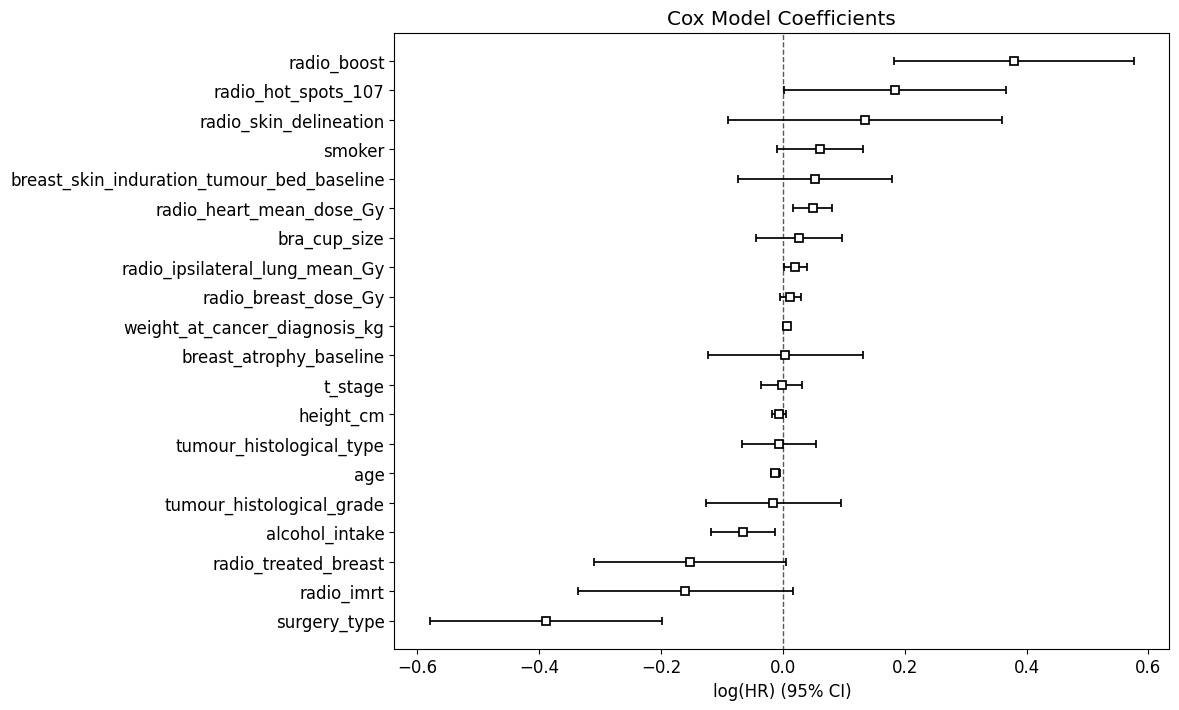

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'age' failed the non-proportional test: p-value is 0.0143.

   Advice 1: the functional form of the variable 'age' might be incorrect. That is, there may be
non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'age' using pd.cut, and then specify it in `strata=['age',
...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


2. Variable 'radio_breast_dose_Gy' failed the non-proportional test: p-value is 0.0054.

   Advice 1: the functional form of the variable 'radio_breast_dose_Gy' might be incorrect. That is,
there may be non-linear terms missing. The proportional hazard test used is very sensitive to
incorrect functional forms. See documentation in link [D] below on how to specify a functi

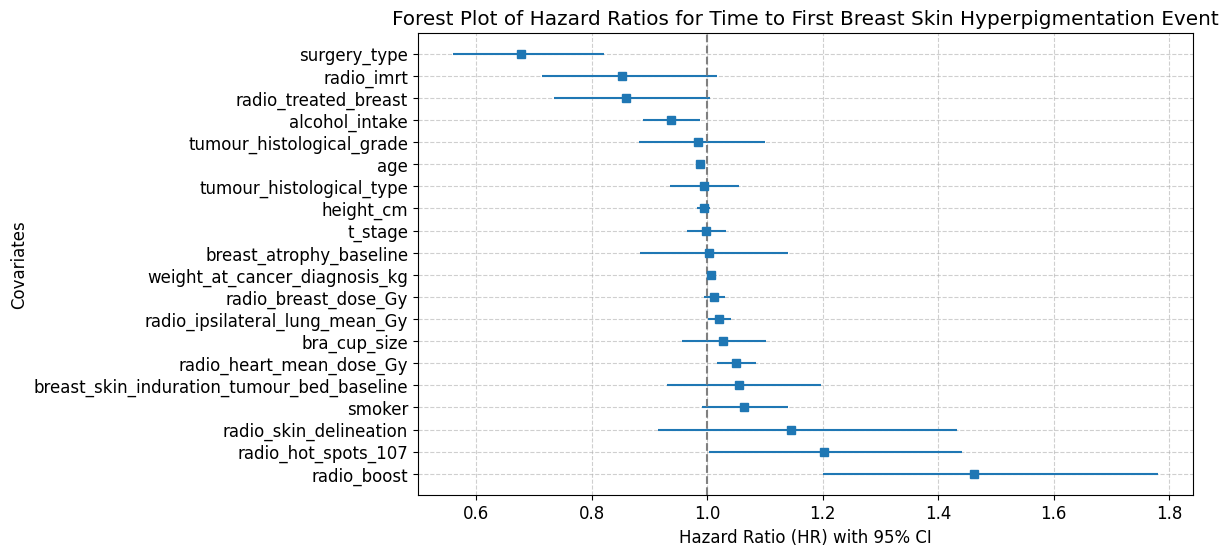

In [87]:
Classic_Cox_fixed(n_df_clean1, clinic, duration_col='Timehyperpigmentation1', event_col='Eventhyperpigmentation1', event_type= 'First') # if you see the number of patents not match with the plotting try to implement the encoded one : n_df_clean1


Using formula:
radio_heart_mean_dose_Gy + radio_ipsilateral_lung_mean_Gy + rs35106661 + surgery_type + radio_breast_dose_Gy + rs11958262 + rs11386090 + age + alcohol_intake + rs11869785 + rs10070847 + rs71628527 + rs75703465 + radio_imrt + weight_at_cancer_diagnosis_kg + rs2805343 + rs12978904 + radio_boost + height_cm + rs280534


<lifelines.CoxPHFitter: fitted with 1448 total observations, 808 right-censored observations>
             duration col = 'Timehyperpigmentation1'
                event col = 'Eventhyperpigmentation1'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 1448
number of events observed = 640
   partial log-likelihood = -4255.51
         time fit was run = 2026-08-10 12:11:10 UTC

---
                                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                       
radio_heart_mean_dose_Gy        0.06      1.06      0.01            0.03            0.09                1.03                1.09
radio_ipsilateral_lung_mean_Gy  0.02      1.02      0.01            0.00            0.04                1.00                1.04
rs35106661                      0.16      1.18      0.05            0.06            0.27                1.06                1.31
surgery_type                   -0.40      0.67      0.09           -0.57           -0.22                0.56                0.81
radio_breast_dose_Gy            0.01      1.01      0.01           -0.00            0.03                1.00                1.03
rs11958262                      0.20      1.22      0.05            0.10            0.30                1.11                1.35
rs11386090                     -0.22      0.81      0.05           -0.32           -0.12                0.73                0.89
age                            -0.01      0.99      0.00           -0.02           -0.01                0.98                0.99
alcohol_intake                 -0.04      0.96      0.03           -0.09            0.01                0.91                1.01
rs11869785                      0.21      1.23      0.05            0.10            0.31                1.11                1.37
rs10070847                      0.22      1.24      0.06            0.11            0.33                1.11                1.39
rs71628527                      0.41      1.50      0.11            0.18            0.63                1.20                1.88
rs75703465                     -0.19      0.83      0.06           -0.31           -0.06                0.73                0.94
radio_imrt                     -0.12      0.89      0.08           -0.29            0.04                0.75                1.05
weight_at_cancer_diagnosis_kg   0.01      1.01      0.00            0.00            0.01                1.00                1.01
rs2805343                       0.05      1.05      0.07           -0.08            0.18                0.92                1.20
rs12978904                     -0.17      0.85      0.06           -0.27           -0.06                0.76                0.94
radio_boost                     0.35      1.42      0.09            0.17            0.53                1.19                1.70
height_cm                      -0.01      0.99      0.01           -0.02            0.00                0.98                1.00
rs280534                       -0.15      0.86      0.05           -0.25           -0.04                0.78                0.96

                                cmp to     z      p  -log2(p)
covariate                                                    
radio_heart_mean_dose_Gy          0.00  4.19 <0.005     15.11
radio_ipsilateral_lung_mean_Gy    0.00  2.23   0.03      5.29
rs35106661                        0.00  3.17 <0.005      9.35
surgery_type                      0.00 -4.33 <0.005     16.00
radio_breast_dose_Gy              0.00  1.65   0.10      3.34
rs11958262                        0.00  3.95 <0.005     13.66
rs11386090                        0.00 -4.21 <0.005     15.26
age                               0.00 -3.79 <0.005     12.70
alcohol_intake                    0.00 -1.74   0.08      3.61
rs11869785         

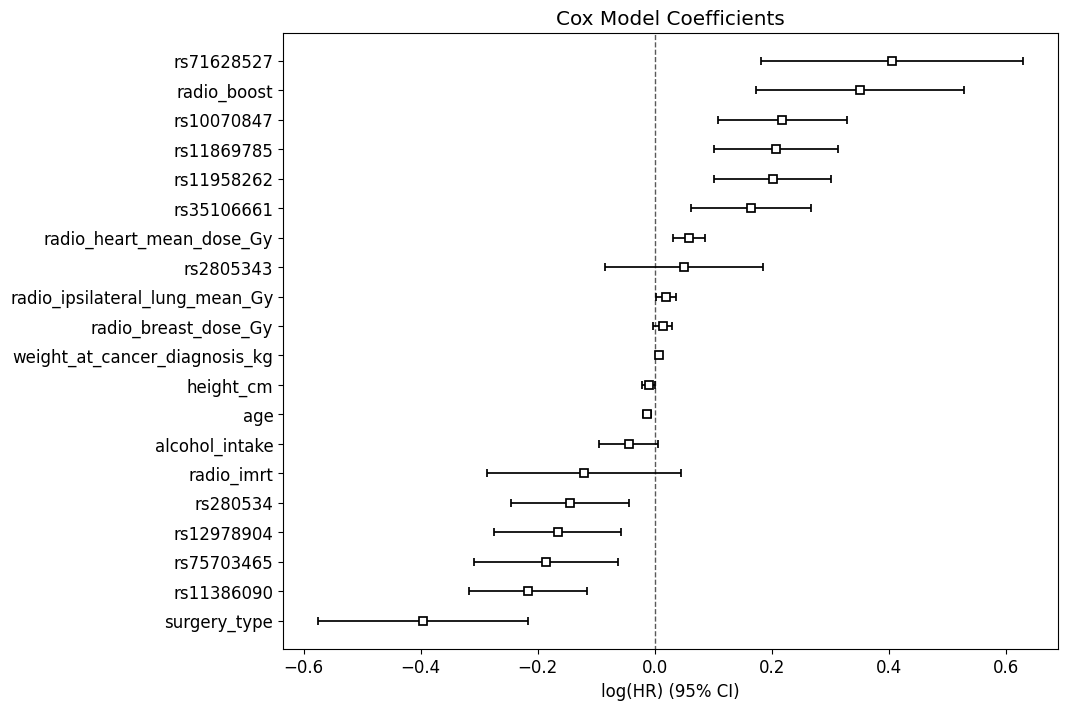

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'surgery_type' failed the non-proportional test: p-value is <5e-05.

   Advice: with so few unique values (only 2), you can include `strata=['surgery_type', ...]` in the
call in `.fit`. See documentation in link [E] below.

2. Variable 'radio_breast_dose_Gy' failed the non-proportional test: p-value is 0.0157.

   Advice 1: the functional form of the variable 'radio_breast_dose_Gy' might be incorrect. That is,
there may be non-linear terms missing. The proportional hazard test used is very sensitive to
incorrect functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'radio_breast_dose_Gy' using pd.cut, and then specify it in
`strata=['radio_breast_dose_Gy', ...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


3. Variable 'age' failed the non-proportional test: p-value is 0.0431.

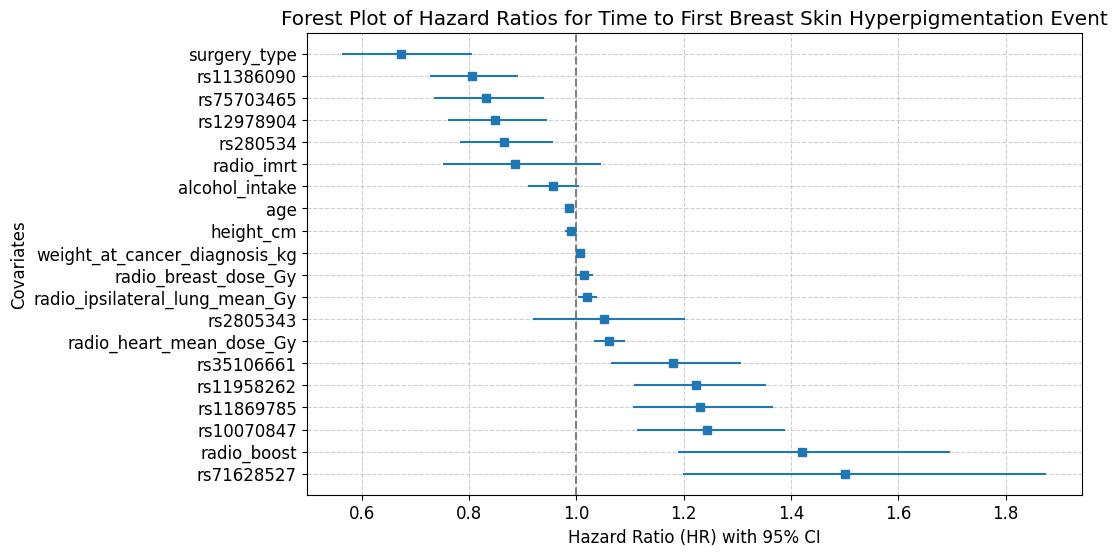

In [89]:
Classic_Cox_fixed(n_df_clean1, combined, duration_col='Timehyperpigmentation1', event_col='Eventhyperpigmentation1', event_type= 'First')


Using formula:
rs11958262 + rs35106661 + rs75703465 + rs11386090 + rs11869785


<lifelines.CoxPHFitter: fitted with 1529 total observations, 846 right-censored observations>
             duration col = 'Timehyperpigmentation1'
                event col = 'Eventhyperpigmentation1'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 1529
number of events observed = 683
   partial log-likelihood = -4696.30
         time fit was run = 2026-08-10 12:38:35 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
rs11958262  0.24      1.27      0.05            0.14            0.33                1.15                1.40
rs35106661  0.12      1.13      0.05            0.02            0.22                1.02                1.24
rs75703465 -0.21      0.81      0.06           -0.33           -0.09                0.72                0.91
rs11386090 -0.20      0.82      0.05           -0.30           -0.10                0.74                0.90
rs11869785  0.24      1.27      0.05            0.14            0.34                1.15                1.41

            cmp to     z      p  -log2(p)
covariate                                
rs11958262    0.00  4.75 <0.005     18.91
rs35106661    0.00  2.46   0.01      6.16
rs75703465    0.00 -3.48 <0.005     10.96
rs11386090    0.00 -4.01 <0.005     14.00
rs11869785    0.00  4.58 <0.005     17.70
---
Concordance = 0.62
Partial AIC = 9402.61
log-likelihood ratio test = 76.47 on 5 df
-log2(p) of ll-ratio test = 47.63

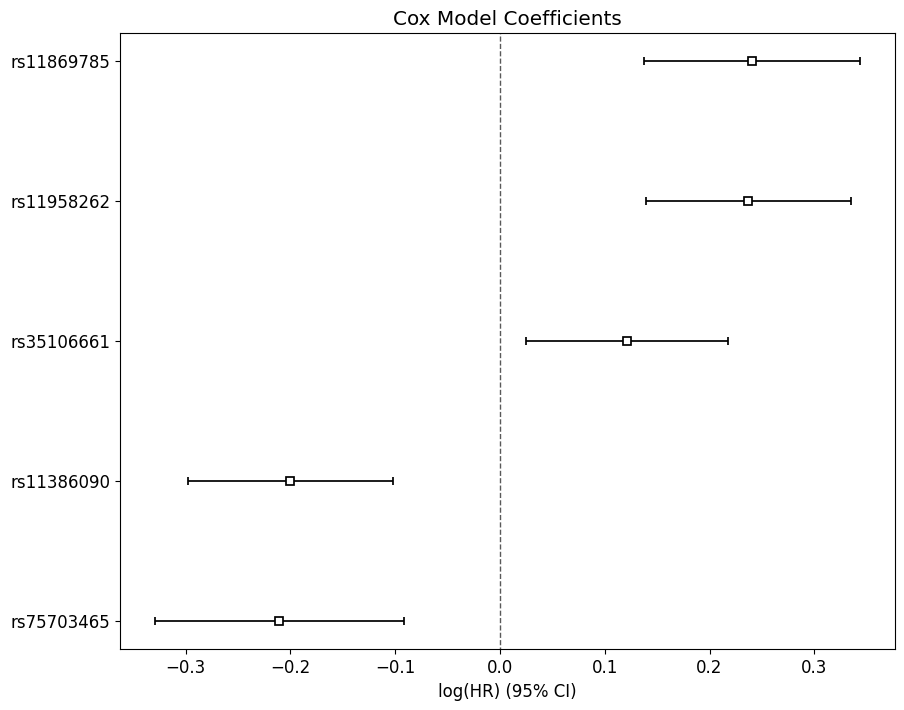

Proportional hazard assumption looks okay.

Hazard Ratio Table:
               Feature  Hazard Ratio (HR)  95% CI Lower  95% CI Upper  \
covariate                                                               
rs11869785  rs11869785           1.271703      1.147351      1.409533   
rs11958262  rs11958262           1.267510      1.149423      1.397730   
rs35106661  rs35106661           1.128610      1.024781      1.242958   
rs11386090  rs11386090           0.818553      0.742228      0.902726   
rs75703465  rs75703465           0.810119      0.719517      0.912130   

             p-value  
covariate             
rs11869785  0.000005  
rs11958262  0.000002  
rs35106661  0.014006  
rs11386090  0.000061  
rs75703465  0.000502  


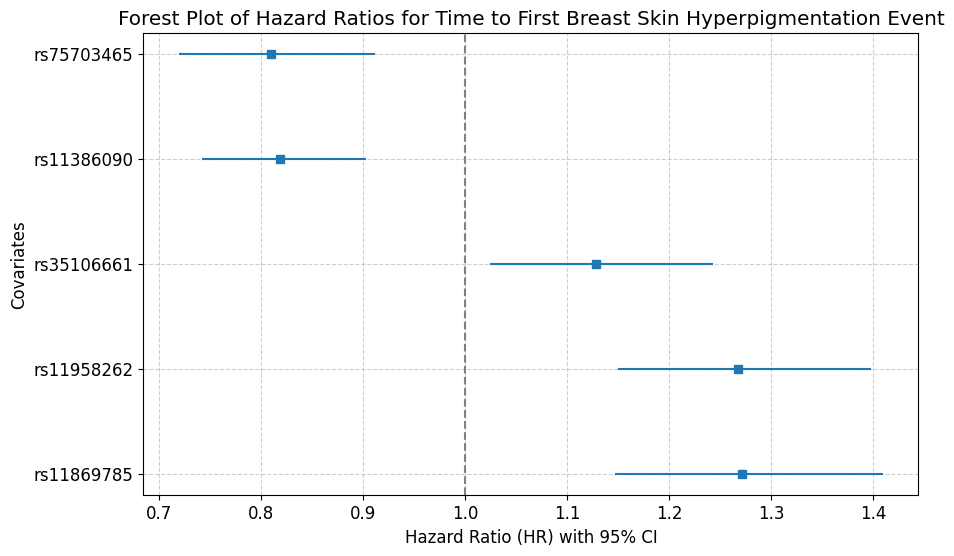

In [101]:
Classic_Cox_fixed(n_df_clean1, snp, duration_col='Timehyperpigmentation1', event_col='Eventhyperpigmentation1', event_type= 'First')

In [ ]:
#cph.plot_partial_effects_on_outcome(covariates=['depression'], values=[0,1])

##Fit model: Random Survival Forest, cox and gradeint Boosting

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sksurv.ensemble import RandomSurvivalForest, GradientBoostingSurvivalAnalysis
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored, brier_score
from sklearn.model_selection import train_test_split
from typing import List

In [ ]:
def Survival_Model(n_df_clean, feature_list, duration_col, event_col, event_type, y_endpoint, y_ranges, color= 'tab:blue'):
    print('data shape:', n_df_clean.shape)
    # Ensure the dataframe only contains the relevant columns for the model, plus duration and event.
    all_cols_for_model = list(feature_list) + [duration_col, event_col]

    n_df_clean = n_df_clean[all_cols_for_model].dropna()
    print('data shape after cleaning:', n_df_clean.shape)

    X = n_df_clean[feature_list]
    y = Surv.from_dataframe(event_col, duration_col, n_df_clean)

    # -------------------------------------------------
    # 2) Train/Test Split
    # -------------------------------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.4, random_state=42
    )

    y_test_events = y_test[event_col]
    y_test_times = y_test[duration_col]

    # -------------------------------------------------
    # 3) Time Grid
    # -------------------------------------------------
    n_time_points = 100
    times = np.linspace(
        y_test_times.min(),
        np.nextafter(y_test_times.max(), -np.inf),
        n_time_points
    )

    # -------------------------------------------------
    # 4) Models
    # -------------------------------------------------
    MLmodels = [
    RandomSurvivalForest(max_depth=3, max_features=0.5, min_samples_split=5,                       n_estimators=100, random_state=42),   CoxPHSurvivalAnalysis(alpha=0.1, n_iter=100),
    GradientBoostingSurvivalAnalysis(n_estimators=100, learning_rate=0.05,
                                     max_depth=3, subsample=0.8, loss='coxph', random_state=42)
]

    results = []

    # -------------------------------------------------
    # 5) Loop Through Models
    # -------------------------------------------------
    for model in MLmodels:
        print(f"\nFitting model: {model.__class__.__name__}")
        model.fit(X_train, y_train)

        # Predict survival curves
        surv_funcs = model.predict_survival_function(X_test)
        survival_probs = np.row_stack([sf(times) for sf in surv_funcs])

        # -------------------------------------------------
        # Risk Score Extraction
        # -------------------------------------------------
        try:
            pred = model.predict(X_test)
            if isinstance(pred, np.ndarray) and pred.ndim == 1:
                risk_scores = pred
            else:
                risk_scores = None
        except:
            risk_scores = None

        if risk_scores is None:
            try:
                chf_list = model.predict_cumulative_hazard_function(X_test)
                risk_scores = np.array([ch(times[-1]) for ch in chf_list])
            except:
                risk_scores = -survival_probs[:, -1]

        # -------------------------------------------------
        # Metrics
        # -------------------------------------------------
        c_index = concordance_index_censored(
            y_test_events, y_test_times, risk_scores
        )[0]

        brier_times, brier_scores = brier_score(
            y_train,
            y_test,
            survival_probs,
            times
        )
        avg_predicted_cumulative_risk = (1 - survival_probs[:, -1]).mean()


        # -------------------------------------------------
        # Plot Survival Curves
        # -------------------------------------------------
        plt.figure(figsize=(10, 6))
        #plt.step(times, survival_probs.mean(axis=0), where="post", linewidth=2, label=f"Average Predicted- No risk (C-index={c_index:.2f})")
        #plt.step(times, 1- survival_probs.mean(axis=0), where="post", color='#FF7F50',      linewidth=2, label=f"Average Predicted Cumulative Risk (C-index={c_index:.2f})")

        plt.step(times, 1 - survival_probs.mean(axis=0), where="post", color=color,
                 linewidth=2, label=f"Mean cumulative risk (40% test set)\n C-index={c_index:.2f}")

        #plt.scatter(times, 1 - survival_probs.mean(axis=0), s=20, zorder=3) # create some dotes

        #.ylabel("Survival Probability of no Risk")
        plt.ylabel("Cumulative Risk") # OR Predicted Probability
        plt.xlabel(f"Time to {event_type} {dep} Event")
        #plt.title(f"Predicted no risk Lymphedema - {model.__class__.__name__}")
        plt.title(f"Predicted {dep} Risk - {model.__class__.__name__}")
        plt.xticks(np.arange(0, 100, 12))
        plt.yticks(np.arange(0, y_endpoint, y_ranges)) # if we delete this, the plot maximize
        plt.grid(True)
        #plt.legend(loc='upper center')
        plt.legend()
        #plt.legend(
        plt.show()

        # Store results
        results.append({
            "model": model.__class__.__name__,
            "c_index": c_index,
            "avg_cum_risk_final": avg_predicted_cumulative_risk,
            "brier": (brier_times, brier_scores)
        })

    # -------------------------------------------------
    # Summary
    # -------------------------------------------------
    for r in results:
      print(f"\nModel: {r['model']}")
      print(f" C-Index: {r['c_index']:.4f}")
      print(f" Mean Cumulative Risk: {r['avg_cum_risk_final']:.4f}")
      times_out, scores_out = r['brier']
      # define the time checkpoints you want
      check_times = [1, 12, 24, 36, 48, 60, 72, 84, 96]
      print(" Brier Score checkpoints:")
      for ct in check_times:
          # find nearest time in the grid
          idx = np.argmin(np.abs(times_out - ct))
          print(f"  t={times_out[idx]:.2f} → Brier={scores_out[idx]:.4f}")

data shape: (1544, 662)
data shape after cleaning: (1400, 22)

Fitting model: RandomSurvivalForest


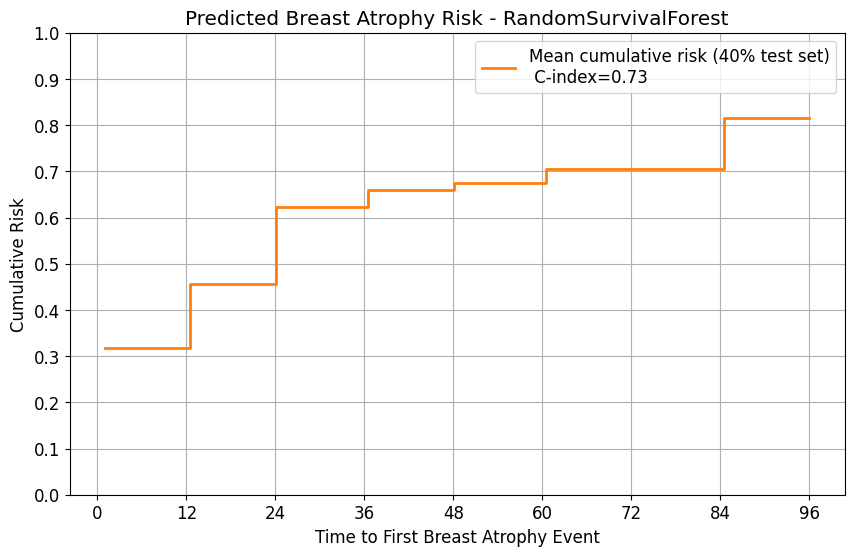


Fitting model: CoxPHSurvivalAnalysis


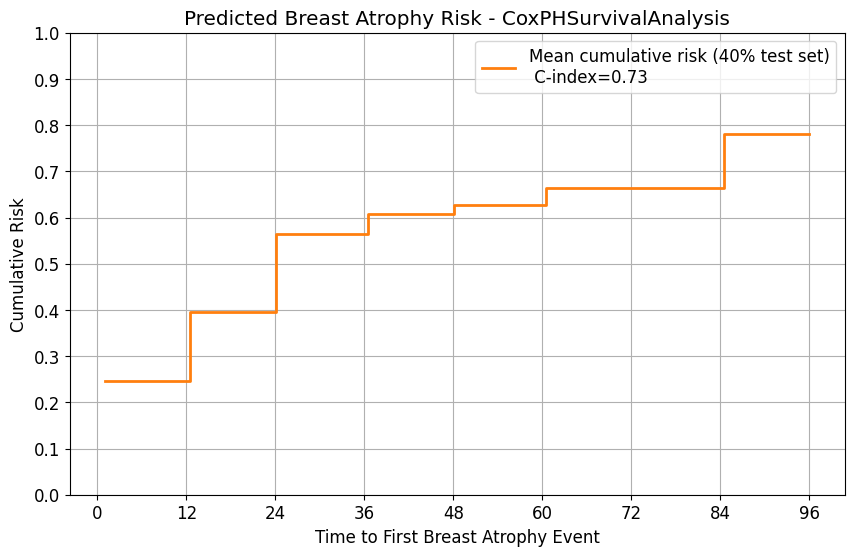


Fitting model: GradientBoostingSurvivalAnalysis


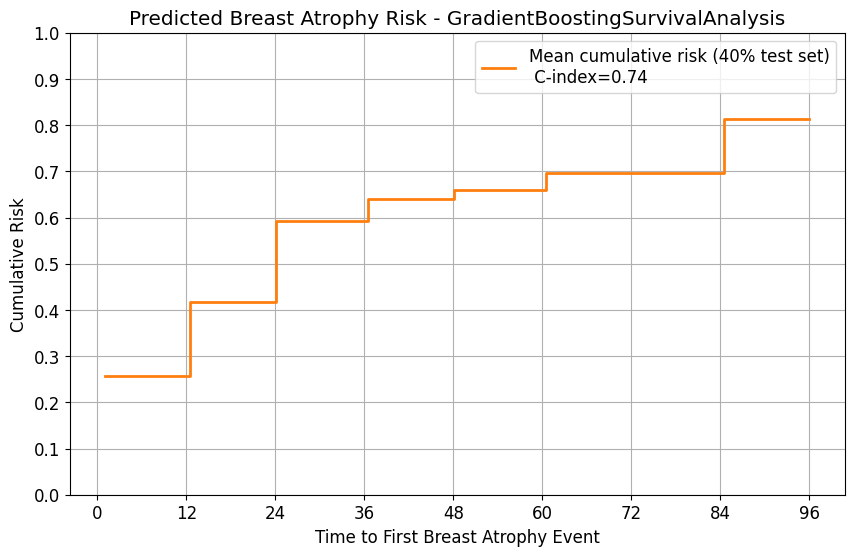


Model: RandomSurvivalForest
 C-Index: 0.7300
 Mean Cumulative Risk: 0.8146
 Brier Score checkpoints:
  t=1.00 → Brier=0.1701
  t=11.56 → Brier=0.1701
  t=24.03 → Brier=0.2248
  t=35.55 → Brier=0.2248
  t=48.02 → Brier=0.2117
  t=59.54 → Brier=0.2117
  t=72.01 → Brier=0.1745
  t=83.53 → Brier=0.1745
  t=96.00 → Brier=0.1093

Model: CoxPHSurvivalAnalysis
 C-Index: 0.7316
 Mean Cumulative Risk: 0.7816
 Brier Score checkpoints:
  t=1.00 → Brier=0.2143
  t=11.56 → Brier=0.2143
  t=24.03 → Brier=0.2350
  t=35.55 → Brier=0.2350
  t=48.02 → Brier=0.2273
  t=59.54 → Brier=0.2273
  t=72.01 → Brier=0.1836
  t=83.53 → Brier=0.1836
  t=96.00 → Brier=0.1336

Model: GradientBoostingSurvivalAnalysis
 C-Index: 0.7412
 Mean Cumulative Risk: 0.8127
 Brier Score checkpoints:
  t=1.00 → Brier=0.2017
  t=11.56 → Brier=0.2017
  t=24.03 → Brier=0.2246
  t=35.55 → Brier=0.2246
  t=48.02 → Brier=0.2126
  t=59.54 → Brier=0.2126
  t=72.01 → Brier=0.1754
  t=83.53 → Brier=0.1754
  t=96.00 → Brier=0.1115


In [ ]:
Survival_Model(
    n_df_train,
    combined2, duration_col='TimeAtrophy1', event_col='EventAtrophy1',
    event_type='First',
    y_endpoint=1.1,
    y_ranges=0.1,
    color='tab:orange')

In [ ]:
n_df1_train.shape

(1544, 89)

In [ ]:
def unpack_surv(s):
  events = np.array([row[0] for row in s], dtype=bool)
  times = np.array([row[1] for row in s], dtype=float)
  return events, times


# Selecting different ML models
RSF gives you a nonlinear tree ensemble.
GradientBoostingSurvivalAnalysis gives you another nonlinear boosted tree model.
CoxPH gives you a classical linear baseline.
Coxnet gives you a penalized linear Cox baseline.
ComponentwiseGradientBoostingSurvivalAnalysis sits closer to the linear/additive side than to RSF, so it overlaps more with CoxPH/Coxnet than with RSF. That makes it more likely to be methodologically interesting only if you want to ask whether a boosted additive Cox-style model performs better than standard Cox-type models.

The main reason is that ComponentwiseGradientBoostingSurvivalAnalysis is still a boosting model with Cox partial-likelihood loss, but its base learner is component-wise least squares, while GradientBoostingSurvivalAnalysis uses regression trees as base learners. scikit-survival describes this distinction directly: tree-based gradient boosting is more versatile and can capture more complicated nonlinear relationships, whereas component-wise boosting is a different, more additive boosting formulation.

In [107]:
# With standarise /coxnet increased other models dont effect, also added SVC without plotting the area as it does not have predict_survival_function
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored
from sksurv.ensemble import RandomSurvivalForest, GradientBoostingSurvivalAnalysis, ComponentwiseGradientBoostingSurvivalAnalysis, ExtraSurvivalTrees
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.svm import FastSurvivalSVM

def cross_validate_survival_models2(
    df,
    feature_list,
    duration_col="Time1",
    event_col="Event1",
    event_type="First",
    time_unit="Months",
    n_splits=10,
    n_time_points=200,
    y_max=1.0,
    y_tick_step=0.1,
    random_state=42,
    models=None,
    plot=True, s='Clinic'):

    print("Data shape before preprocessing:", df.shape)

    required_cols = [duration_col, event_col] + list(feature_list)
    df_model = df[required_cols].copy()

    # User-defined encoding helper
    df_model = encode_dataset(
        df_model,
        duration_col=duration_col,
        event_col=event_col
    )

    # Complete-case analysis
    df_model = df_model.dropna().copy()
    print("Data shape after encoding and cleaning:", df_model.shape)

    # Build design matrix and survival outcome
    X_raw = df_model[feature_list].astype(float)
    scaler = StandardScaler()
    # FIX: Wrap scaled numpy array back into a DataFrame to maintain .iloc support
    X = pd.DataFrame(scaler.fit_transform(X_raw), columns=X_raw.columns, index=X_raw.index)

    y = Surv.from_dataframe(event_col, duration_col, df_model)
    event_indicator = df_model[event_col].astype(int).values

    # Common global evaluation grid
    t_all = df_model[duration_col].astype(float).values
    time_grid = np.linspace(
        t_all.min(),
        np.nextafter(t_all.max(), -np.inf),
        n_time_points
    )

    # Default model set
    if models is None:
        models = {

            "SVM": FastSurvivalSVM(alpha=1, rank_ratio=1.0,
        max_iter=1000,random_state=42),
            "RSF": RandomSurvivalForest(
                n_estimators=300,
                max_depth=None,
                min_samples_split=10,
                min_samples_leaf=5,
                max_features="sqrt",
                n_jobs=-1,
                random_state=12,
            ),
            "CoxPH": CoxPHSurvivalAnalysis(),
            "Coxnet": CoxnetSurvivalAnalysis(l1_ratio=0.5, alpha_min_ratio=0.01, fit_baseline_model=True),
            "GBSA": GradientBoostingSurvivalAnalysis(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
                random_state=12),
            "ComponentwiseGBSA": ComponentwiseGradientBoostingSurvivalAnalysis(loss="coxph", learning_rate=0.03, n_estimators=300, subsample=0.7, random_state=12),
            "EST": ExtraSurvivalTrees( n_estimators=300,max_depth=None,
            min_samples_split=10, min_samples_leaf=5, max_features="sqrt",
            n_jobs=-1, random_state=12,
        ),
        }

    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    results = {
        model_name: {
            "fold_c_index": [],
            "fold_mean_survival": [],
            "mean_c_index": None,
            "std_c_index": None,
            "mean_survival": None,
            "mean_risk": None,
            "time_grid": time_grid,
        }
        for model_name in models
    }

    for fold, (train_idx, test_idx) in enumerate(cv.split(X, event_indicator), start=1):
        print(f"\n===== Fold {fold} =====")

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        y_test_event = y_test[event_col]
        y_test_time = y_test[duration_col]

        for model_name, model in models.items():
            try:
                model.fit(X_train, y_train)
                if model_name == "SVM":
                    if not hasattr(model, 'coef_') or model.coef_ is None:
                         print(f"{model_name}: Model failed to converge (coef_ is None)")
                         continue
                    risks = model.predict(X_test)
                else:
                    surv_fns = model.predict_survival_function(X_test)
                    surv_probs = np.row_stack([fn(time_grid) for fn in surv_fns])
                    results[model_name]["fold_mean_survival"].append(surv_probs.mean(axis=0))
                    risks = 1.0 - surv_probs[:, -1]

                cidx = concordance_index_censored(y_test[event_col], y_test[duration_col], risks)[0]
                results[model_name]["fold_c_index"].append(cidx)
                print(f"{model_name}: C-index = {cidx:.4f}")
            except Exception as e:
                print(f"{model_name}: Error in fold {fold} ({e})")

    # Summarize results
    for model_name, res in results.items():
        if len(res["fold_mean_survival"]) == 0:
            continue

        fold_mean_survival = np.vstack(res["fold_mean_survival"])
        mean_survival = fold_mean_survival.mean(axis=0)
        mean_risk = 1.0 - mean_survival

        res["fold_mean_survival"] = fold_mean_survival
        res["mean_survival"] = mean_survival
        res["mean_risk"] = mean_risk
        res["mean_c_index"] = float(np.mean(res["fold_c_index"]))
        res["std_c_index"] = float(np.std(res["fold_c_index"], ddof=1)) if len(res["fold_c_index"]) > 1 else 0.0

    if plot:
        for model_name, res in results.items():
            if res["mean_risk"] is None:
                continue
            plt.figure(figsize=(8, 6))
            fold_curves = res["fold_mean_survival"]
            fold_c_index = res["fold_c_index"]
            for i in range(fold_curves.shape[0]):
                plt.plot(time_grid, 1.0 - fold_curves[i], alpha=0.35, linewidth=1, label=f"Fold {i+1} (C-index={fold_c_index[i]:.3f})")
            plt.plot(time_grid, res["mean_risk"], color="black", linewidth=2.5, label=f"Mean risk (C-index={res['mean_c_index']:.3f} ± {res['std_c_index']:.3f})")
            plt.title(f"{model_name}: {n_splits}-Fold Cross Validation_{s} ({df_model.shape})")
            plt.xlabel(f"Time to {event_type} Event ({time_unit})")
            plt.ylabel("Cumulative Risk")
            plt.xticks(np.arange(0, np.ceil(time_grid.max()) + 1, 12))
            plt.yticks(np.arange(0, y_max + y_tick_step, y_tick_step))
            plt.ylim(0, y_max)
            plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
            plt.legend(fontsize=9, loc="best")
            plt.tight_layout()
            plt.show()

    print("\n===== Cross-Validation Summary =====")
    summary_rows = []
    for model_name, res in results.items():
        if res["mean_c_index"] is None:
            continue
        summary_rows.append({
            "Model": model_name,
            "Mean C-index": round(res["mean_c_index"], 3),
            "SD C-index": round(res["std_c_index"], 3),
            "N folds": len(res["fold_c_index"]),
            "N samples": df_model.shape[0],
            "N features": len(feature_list),
        })
    summary_df = pd.DataFrame(summary_rows).sort_values(by="Mean C-index", ascending=False)
    print(summary_df.to_string(index=False))
    return {"results": results, "summary_table": summary_df, "time_grid": time_grid}

Data shape before preprocessing: (1544, 109)
Encoded 0 categorical columns:
[]
Data shape after encoding and cleaning: (1448, 22)

===== Fold 1 =====
SVM: C-index = 0.7201
RSF: C-index = 0.7503
CoxPH: C-index = 0.7170
Coxnet: C-index = 0.7428
GBSA: C-index = 0.7490
ComponentwiseGBSA: C-index = 0.7150
EST: C-index = 0.7651

===== Fold 2 =====
SVM: C-index = 0.6851
RSF: C-index = 0.7216
CoxPH: C-index = 0.6955
Coxnet: C-index = 0.5941
GBSA: C-index = 0.7077
ComponentwiseGBSA: C-index = 0.6465
EST: C-index = 0.7197

===== Fold 3 =====
SVM: C-index = 0.7729
RSF: C-index = 0.7605
CoxPH: C-index = 0.7612
Coxnet: C-index = 0.7061
GBSA: C-index = 0.7552
ComponentwiseGBSA: C-index = 0.7429
EST: C-index = 0.7696

===== Fold 4 =====
SVM: C-index = 0.6803
RSF: C-index = 0.7046
CoxPH: C-index = 0.6763
Coxnet: C-index = 0.6735
GBSA: C-index = 0.6910
ComponentwiseGBSA: C-index = 0.6564
EST: C-index = 0.7160

===== Fold 5 =====
SVM: C-index = 0.6684
RSF: C-index = 0.6657
CoxPH: C-index = 0.6638
Coxnet

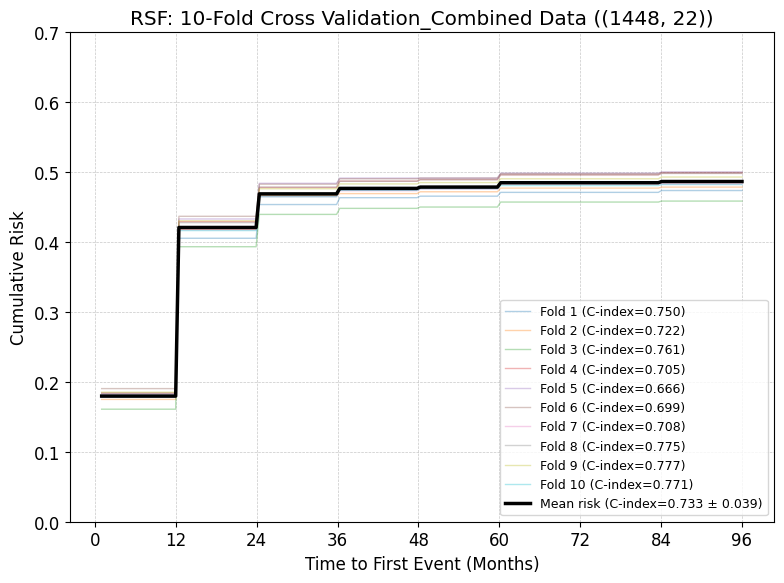

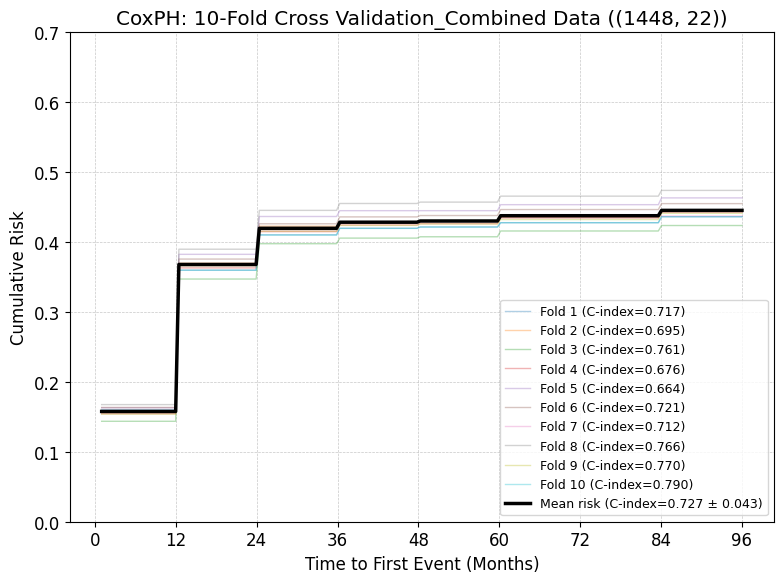

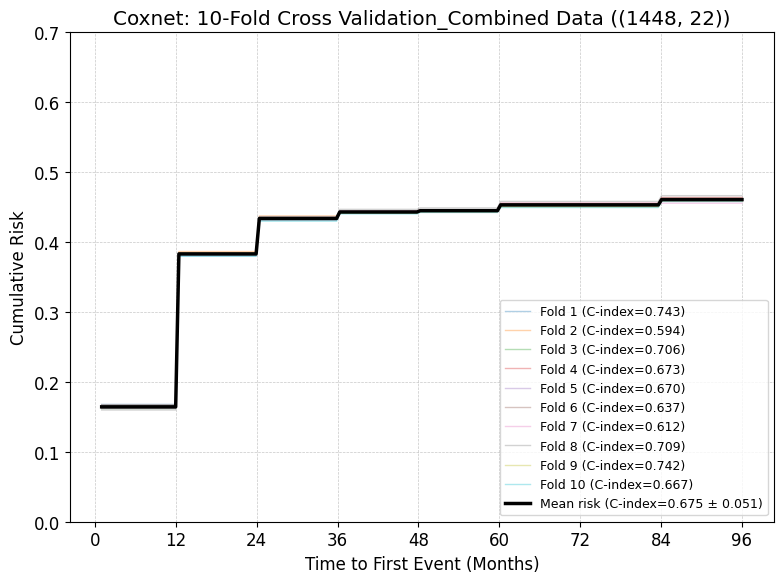

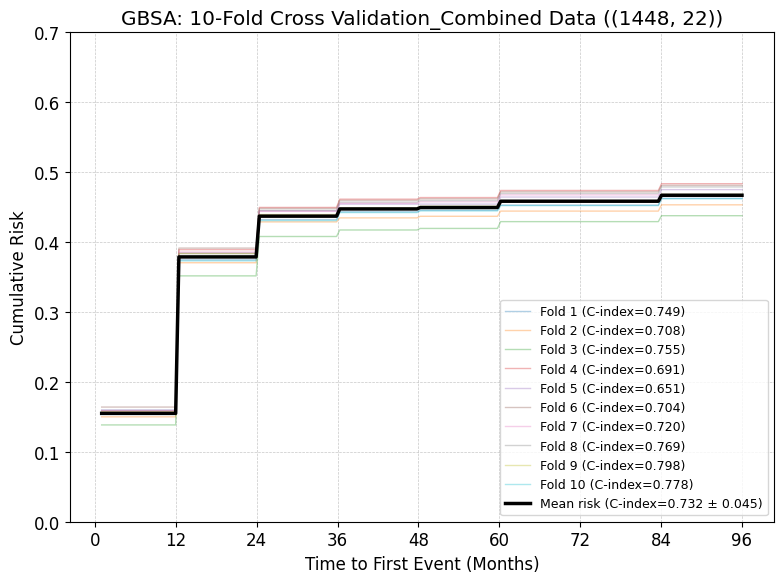

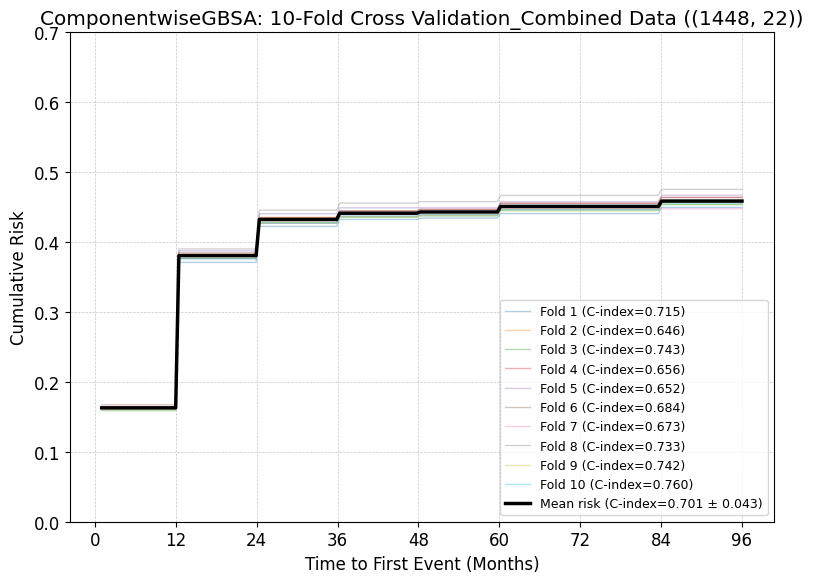

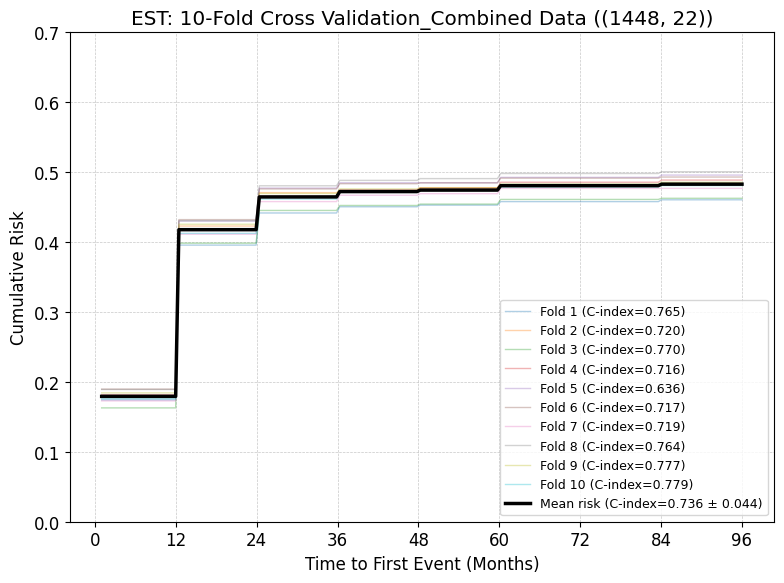


===== Cross-Validation Summary =====
            Model  Mean C-index  SD C-index  N folds  N samples  N features
              EST         0.736       0.044       10       1448          20
              RSF         0.733       0.039       10       1448          20
             GBSA         0.732       0.045       10       1448          20
            CoxPH         0.727       0.043       10       1448          20
ComponentwiseGBSA         0.701       0.043       10       1448          20
           Coxnet         0.675       0.051       10       1448          20


{'results': {'SVM': {'fold_c_index': [np.float64(0.7201315308732189),
    np.float64(0.685097419694576),
    np.float64(0.7728830990743915),
    np.float64(0.6802980419338069),
    np.float64(0.6683745583038869),
    np.float64(0.7252687192566952),
    np.float64(0.7114926895613737),
    np.float64(0.7720626182693962),
    np.float64(0.7767779892715002),
    np.float64(0.782302568981922)],
   'fold_mean_survival': [],
   'mean_c_index': None,
   'std_c_index': None,
   'mean_survival': None,
   'mean_risk': None,
   'time_grid': array([ 1.        ,  1.47738693,  1.95477387,  2.4321608 ,  2.90954774,
           3.38693467,  3.86432161,  4.34170854,  4.81909548,  5.29648241,
           5.77386935,  6.25125628,  6.72864322,  7.20603015,  7.68341709,
           8.16080402,  8.63819095,  9.11557789,  9.59296482, 10.07035176,
          10.54773869, 11.02512563, 11.50251256, 11.9798995 , 12.45728643,
          12.93467337, 13.4120603 , 13.88944724, 14.36683417, 14.84422111,
          15.32160

In [110]:
# to have same patient number put common_df instead oh n_df_train
cross_validate_survival_models2(n_df1_train, combined, duration_col='Timehyperpigmentation1', event_col='Eventhyperpigmentation1', event_type= 'First',  n_splits=10,
    n_time_points=200,    y_max=0.70,    y_tick_step=0.1,    random_state=42,    plot=True, s= 'Combined Data'
)

Data shape before preprocessing: (1544, 109)
Encoded 1 categorical columns:
['t_stage']
Data shape after encoding and cleaning: (1333, 22)

===== Fold 1 =====
SVM: C-index = 0.6362
RSF: C-index = 0.6884
CoxPH: C-index = 0.6419
Coxnet: C-index = 0.6881
GBSA: C-index = 0.6983
ComponentwiseGBSA: C-index = 0.6682
EST: C-index = 0.6541

===== Fold 2 =====
SVM: C-index = 0.7099
RSF: C-index = 0.7256
CoxPH: C-index = 0.7231
Coxnet: C-index = 0.6534
GBSA: C-index = 0.7388
ComponentwiseGBSA: C-index = 0.7022
EST: C-index = 0.7260

===== Fold 3 =====
SVM: C-index = 0.6960
RSF: C-index = 0.7207
CoxPH: C-index = 0.6929
Coxnet: C-index = 0.7087
GBSA: C-index = 0.7081
ComponentwiseGBSA: C-index = 0.7131
EST: C-index = 0.7245

===== Fold 4 =====
SVM: C-index = 0.6866
RSF: C-index = 0.7142
CoxPH: C-index = 0.6876
Coxnet: C-index = 0.5975
GBSA: C-index = 0.7312
ComponentwiseGBSA: C-index = 0.6917
EST: C-index = 0.6710

===== Fold 5 =====
SVM: C-index = 0.6719
RSF: C-index = 0.7222
CoxPH: C-index = 0.67

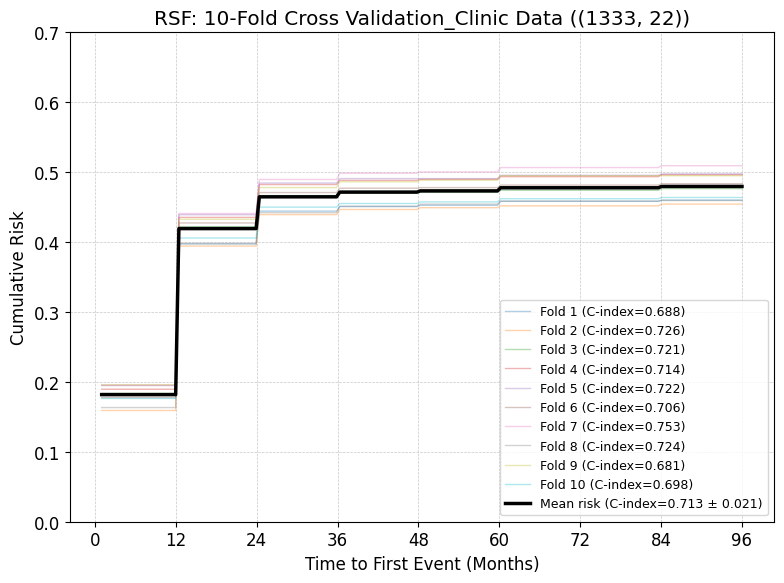

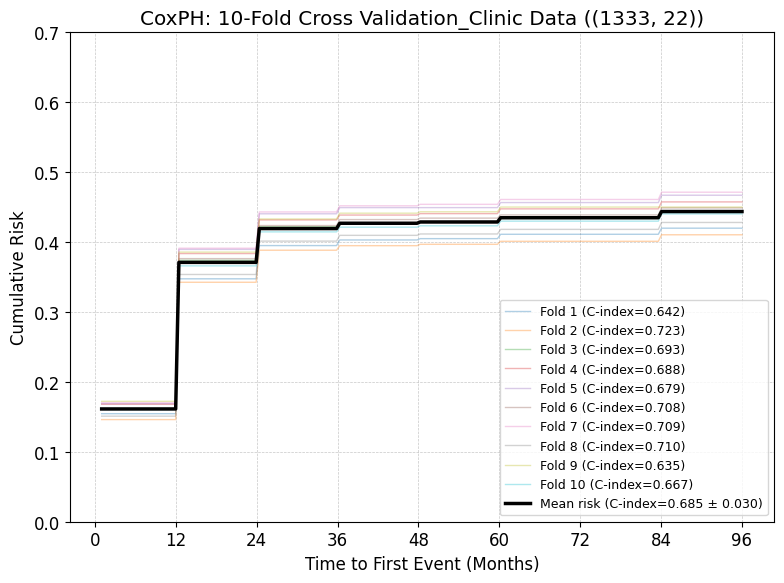

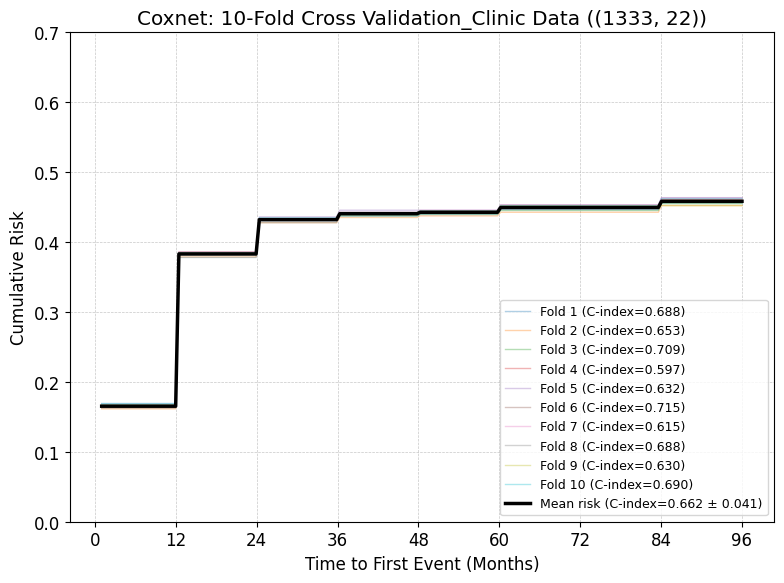

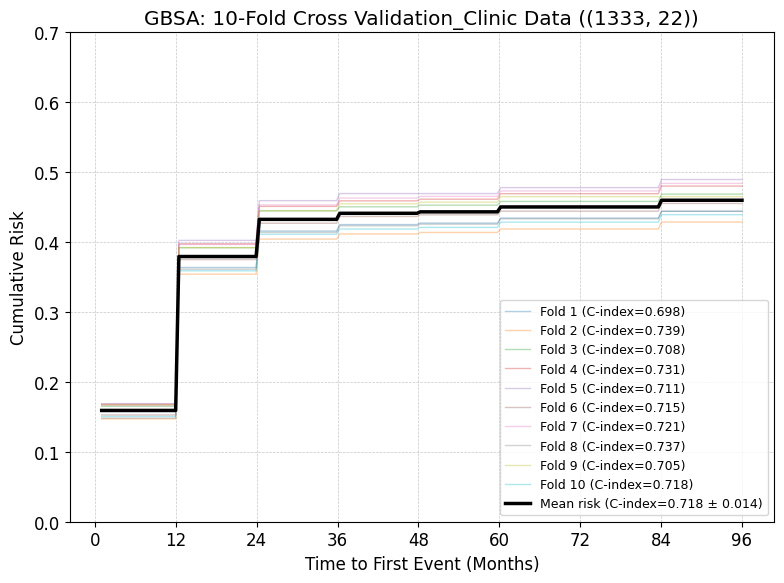

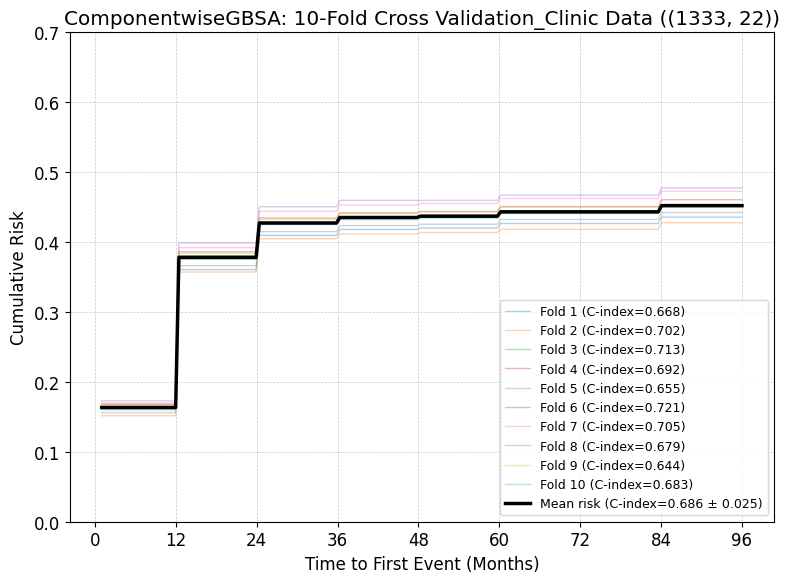

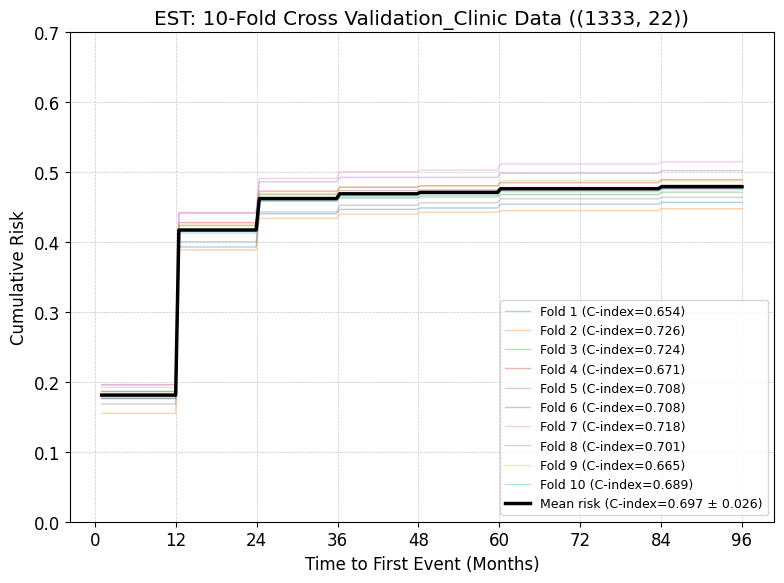


===== Cross-Validation Summary =====
            Model  Mean C-index  SD C-index  N folds  N samples  N features
             GBSA         0.718       0.014       10       1333          20
              RSF         0.713       0.021       10       1333          20
              EST         0.697       0.026       10       1333          20
ComponentwiseGBSA         0.686       0.025       10       1333          20
            CoxPH         0.685       0.030       10       1333          20
           Coxnet         0.662       0.041       10       1333          20


{'results': {'SVM': {'fold_c_index': [np.float64(0.636198684508959),
    np.float64(0.709926854754441),
    np.float64(0.6960370994940978),
    np.float64(0.6866125760649088),
    np.float64(0.671851371786563),
    np.float64(0.7200664038182195),
    np.float64(0.7062320623206232),
    np.float64(0.7039036544850499),
    np.float64(0.6519161549862376),
    np.float64(0.6736111111111112)],
   'fold_mean_survival': [],
   'mean_c_index': None,
   'std_c_index': None,
   'mean_survival': None,
   'mean_risk': None,
   'time_grid': array([ 1.        ,  1.47738693,  1.95477387,  2.4321608 ,  2.90954774,
           3.38693467,  3.86432161,  4.34170854,  4.81909548,  5.29648241,
           5.77386935,  6.25125628,  6.72864322,  7.20603015,  7.68341709,
           8.16080402,  8.63819095,  9.11557789,  9.59296482, 10.07035176,
          10.54773869, 11.02512563, 11.50251256, 11.9798995 , 12.45728643,
          12.93467337, 13.4120603 , 13.88944724, 14.36683417, 14.84422111,
          15.321608

In [111]:
# to have same patient number put common_df instead oh n_df_train
cross_validate_survival_models2(n_df1_train, clinic, duration_col='Timehyperpigmentation1', event_col='Eventhyperpigmentation1', event_type= 'First',  n_splits=10,
    n_time_points=200,    y_max=0.70,    y_tick_step=0.1,    random_state=42,    plot=True, s='Clinic Data'
)

Data shape before preprocessing: (1544, 109)
Encoded 0 categorical columns:
[]
Data shape after encoding and cleaning: (1529, 22)

===== Fold 1 =====
SVM: C-index = 0.6861
RSF: C-index = 0.6812
CoxPH: C-index = 0.6936
Coxnet: C-index = 0.6517
GBSA: C-index = 0.7017
ComponentwiseGBSA: C-index = 0.6872
EST: C-index = 0.6918

===== Fold 2 =====
SVM: C-index = 0.6611
RSF: C-index = 0.6461
CoxPH: C-index = 0.6650
Coxnet: C-index = 0.6200
GBSA: C-index = 0.6841
ComponentwiseGBSA: C-index = 0.6601
EST: C-index = 0.6565

===== Fold 3 =====
SVM: C-index = 0.6110
RSF: C-index = 0.6287
CoxPH: C-index = 0.6156
Coxnet: C-index = 0.5895
GBSA: C-index = 0.6307
ComponentwiseGBSA: C-index = 0.6106
EST: C-index = 0.6337

===== Fold 4 =====
SVM: C-index = 0.5914
RSF: C-index = 0.5781
CoxPH: C-index = 0.5848
Coxnet: C-index = 0.4724
GBSA: C-index = 0.5927
ComponentwiseGBSA: C-index = 0.5471
EST: C-index = 0.5819

===== Fold 5 =====
SVM: C-index = 0.5809
RSF: C-index = 0.5492
CoxPH: C-index = 0.5814
Coxnet

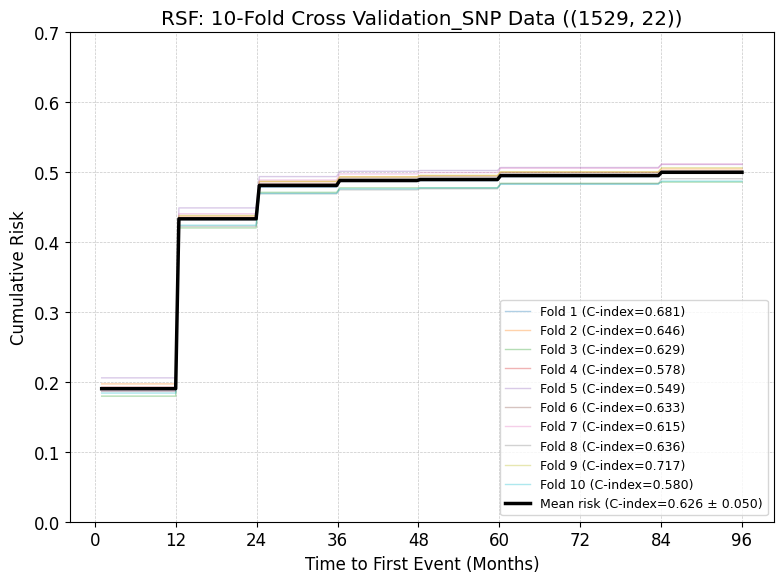

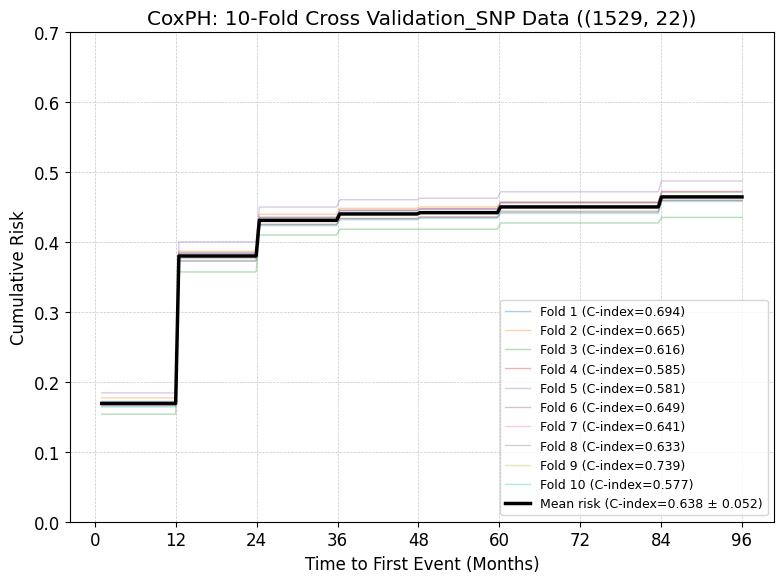

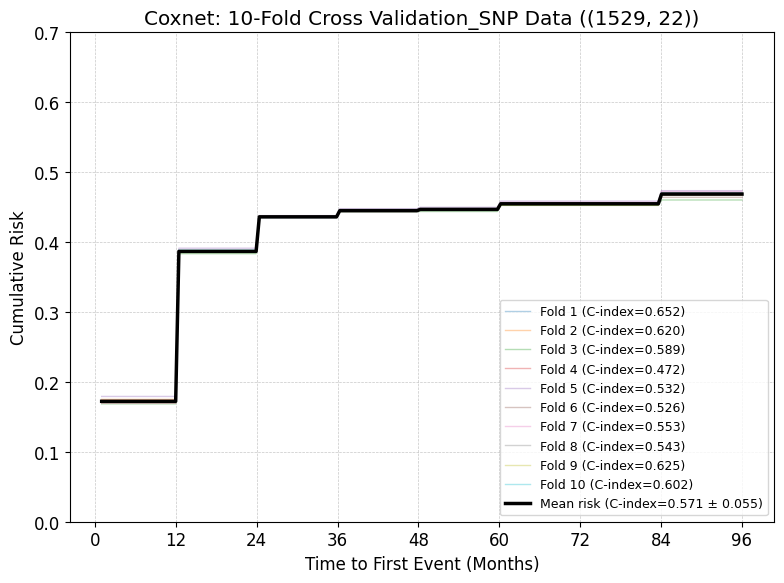

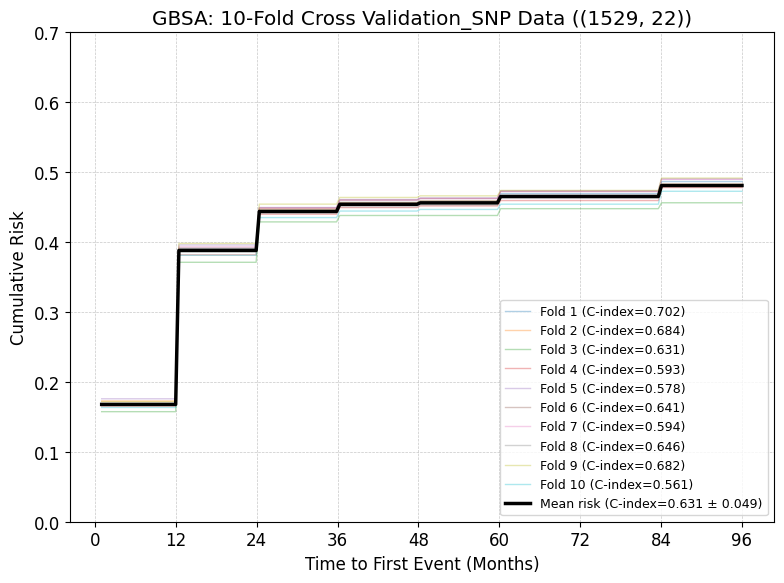

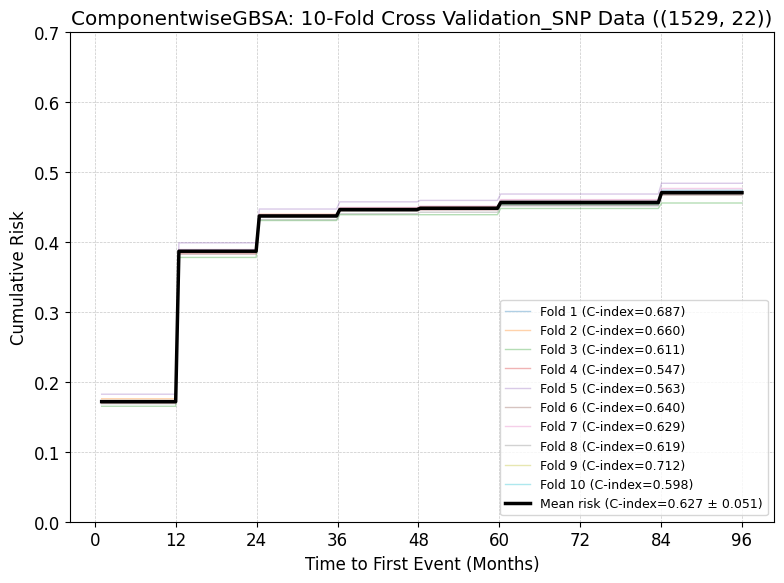

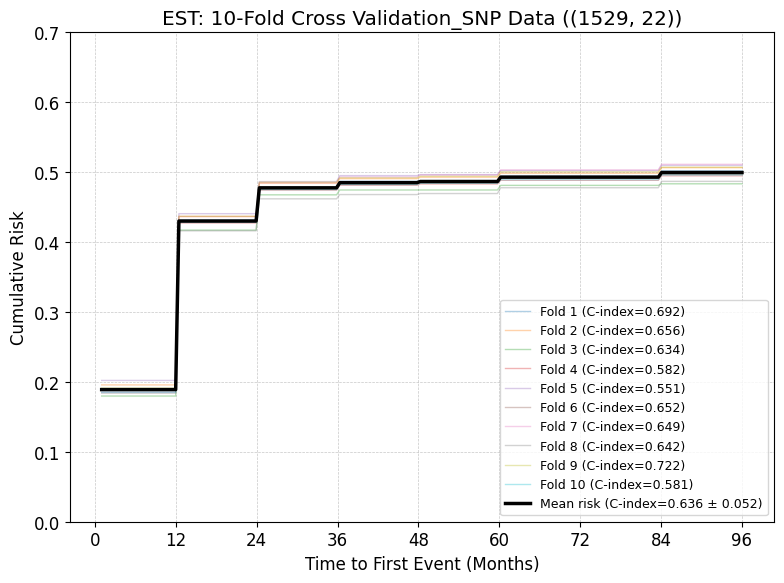


===== Cross-Validation Summary =====
            Model  Mean C-index  SD C-index  N folds  N samples  N features
            CoxPH         0.638       0.052       10       1529          20
              EST         0.636       0.052       10       1529          20
             GBSA         0.631       0.049       10       1529          20
ComponentwiseGBSA         0.627       0.051       10       1529          20
              RSF         0.626       0.050       10       1529          20
           Coxnet         0.571       0.055       10       1529          20


{'results': {'SVM': {'fold_c_index': [np.float64(0.6860821581851625),
    np.float64(0.6610837438423646),
    np.float64(0.6109554933084345),
    np.float64(0.5914199778375812),
    np.float64(0.5809096534653465),
    np.float64(0.6465774980330449),
    np.float64(0.6413327191770306),
    np.float64(0.6300309597523219),
    np.float64(0.7443946188340808),
    np.float64(0.5666768385718645)],
   'fold_mean_survival': [],
   'mean_c_index': None,
   'std_c_index': None,
   'mean_survival': None,
   'mean_risk': None,
   'time_grid': array([ 1.        ,  1.47738693,  1.95477387,  2.4321608 ,  2.90954774,
           3.38693467,  3.86432161,  4.34170854,  4.81909548,  5.29648241,
           5.77386935,  6.25125628,  6.72864322,  7.20603015,  7.68341709,
           8.16080402,  8.63819095,  9.11557789,  9.59296482, 10.07035176,
          10.54773869, 11.02512563, 11.50251256, 11.9798995 , 12.45728643,
          12.93467337, 13.4120603 , 13.88944724, 14.36683417, 14.84422111,
          15.321

In [112]:
# to have same patient number put common_df instead oh n_df_train
cross_validate_survival_models2(n_df1_train, snp, duration_col='Timehyperpigmentation1', event_col='Eventhyperpigmentation1', event_type= 'First',  n_splits=10,
    n_time_points=200,    y_max=0.70,    y_tick_step=0.1,    random_state=42,    plot=True, s= 'SNP Data'
)

Data shape before preprocessing: (1306, 43)
Encoded 1 categorical columns:
['t_stage']
Data shape after encoding and cleaning: (1306, 22)

===== Fold 1 =====
SVM: C-index = 0.6936
RSF: C-index = 0.6982
CoxPH: C-index = 0.6729
Coxnet: C-index = 0.6975
GBSA: C-index = 0.7323
ComponentwiseGBSA: C-index = 0.6883
EST: C-index = 0.6809

===== Fold 2 =====
SVM: C-index = 0.6757
RSF: C-index = 0.6670
CoxPH: C-index = 0.6849
Coxnet: C-index = 0.6491
GBSA: C-index = 0.6846
ComponentwiseGBSA: C-index = 0.6602
EST: C-index = 0.6814

===== Fold 3 =====
SVM: C-index = 0.7346
RSF: C-index = 0.7458
CoxPH: C-index = 0.7244
Coxnet: C-index = 0.7412
GBSA: C-index = 0.7831
ComponentwiseGBSA: C-index = 0.7272
EST: C-index = 0.7321

===== Fold 4 =====
SVM: C-index = 0.7322
RSF: C-index = 0.7792
CoxPH: C-index = 0.7376
Coxnet: C-index = 0.6269
GBSA: C-index = 0.7667
ComponentwiseGBSA: C-index = 0.7462
EST: C-index = 0.7574

===== Fold 5 =====
SVM: C-index = 0.6304
RSF: C-index = 0.6520
CoxPH: C-index = 0.623

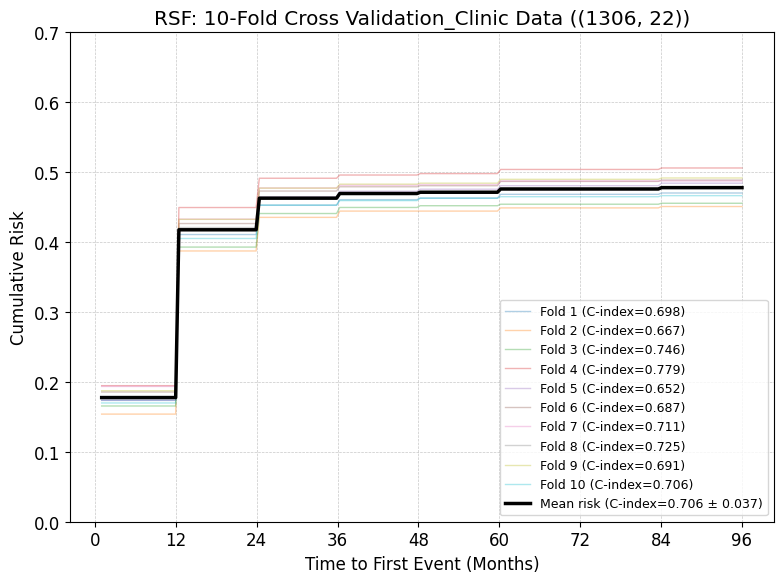

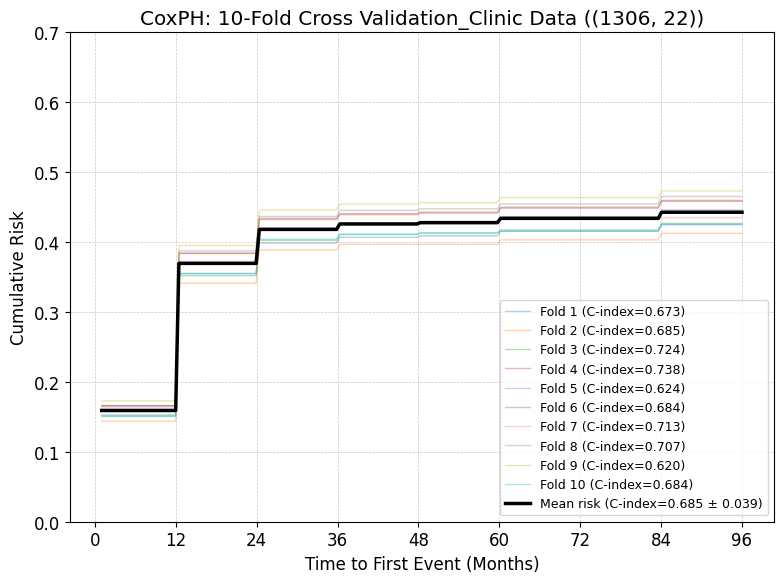

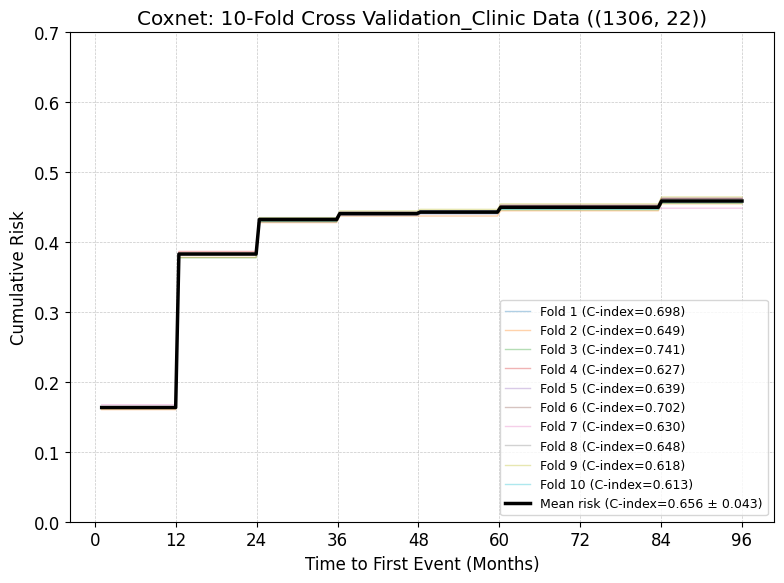

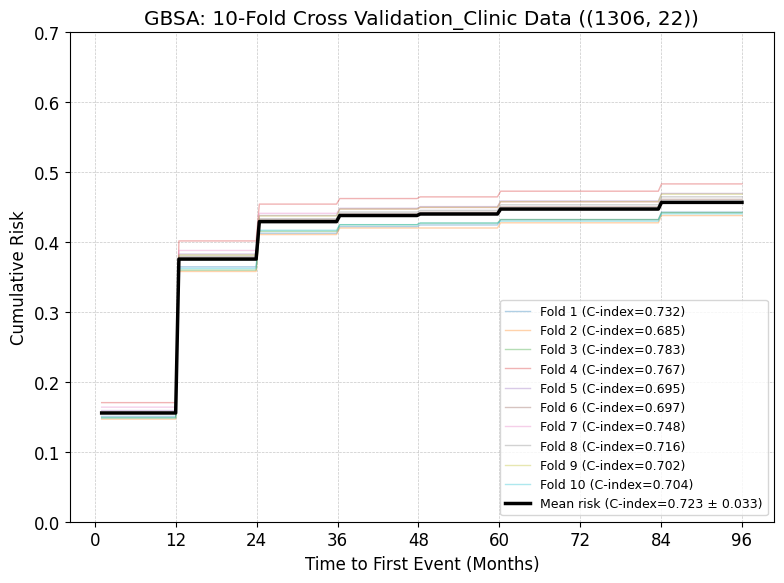

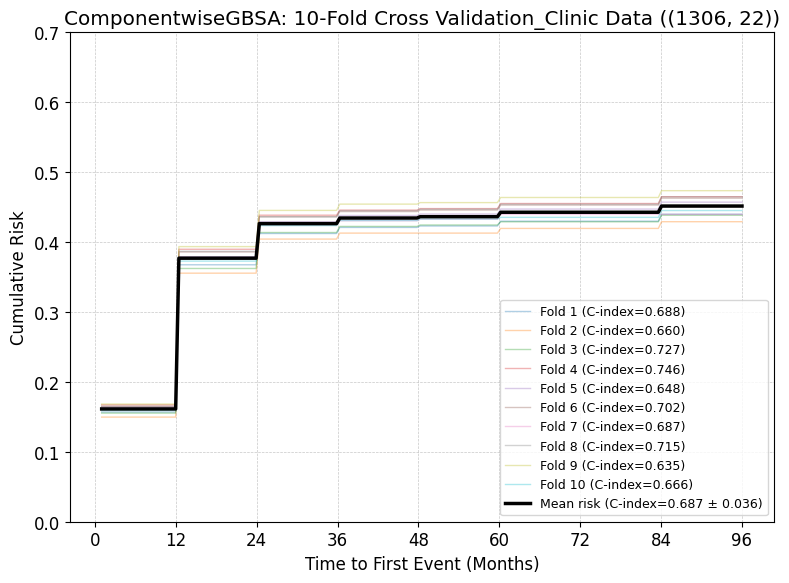

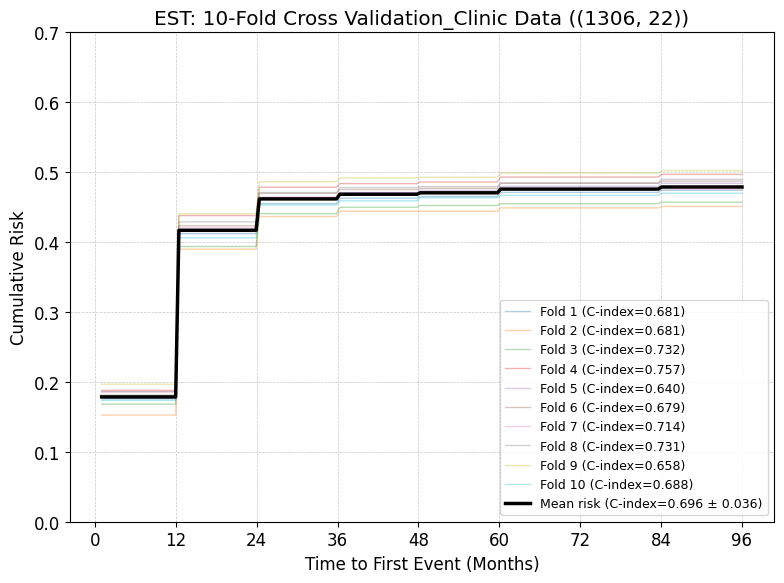


===== Cross-Validation Summary =====
            Model  Mean C-index  SD C-index  N folds  N samples  N features
             GBSA         0.723       0.033       10       1306          20
              RSF         0.706       0.037       10       1306          20
              EST         0.696       0.036       10       1306          20
ComponentwiseGBSA         0.687       0.036       10       1306          20
            CoxPH         0.685       0.039       10       1306          20
           Coxnet         0.656       0.043       10       1306          20


{'results': {'SVM': {'fold_c_index': [np.float64(0.6935927257348277),
    np.float64(0.6757312614259597),
    np.float64(0.7346323358849455),
    np.float64(0.7322393020357292),
    np.float64(0.63042071197411),
    np.float64(0.698976394401504),
    np.float64(0.7078228086710651),
    np.float64(0.7118453585075298),
    np.float64(0.6283566058002148),
    np.float64(0.6787201402586018)],
   'fold_mean_survival': [],
   'mean_c_index': None,
   'std_c_index': None,
   'mean_survival': None,
   'mean_risk': None,
   'time_grid': array([ 1.        ,  1.47738693,  1.95477387,  2.4321608 ,  2.90954774,
           3.38693467,  3.86432161,  4.34170854,  4.81909548,  5.29648241,
           5.77386935,  6.25125628,  6.72864322,  7.20603015,  7.68341709,
           8.16080402,  8.63819095,  9.11557789,  9.59296482, 10.07035176,
          10.54773869, 11.02512563, 11.50251256, 11.9798995 , 12.45728643,
          12.93467337, 13.4120603 , 13.88944724, 14.36683417, 14.84422111,
          15.321608

In [113]:
# to have same patient number put common_df instead oh n_df_train
cross_validate_survival_models2(common_df, clinic, duration_col='Timehyperpigmentation1', event_col='Eventhyperpigmentation1', event_type= 'First',  n_splits=10,
    n_time_points=200,    y_max=0.70,    y_tick_step=0.1,    random_state=42,    plot=True, s= 'Clinic Data'
)

Data shape before preprocessing: (1306, 43)
Encoded 0 categorical columns:
[]
Data shape after encoding and cleaning: (1306, 22)

===== Fold 1 =====
SVM: C-index = 0.7217
RSF: C-index = 0.7243
CoxPH: C-index = 0.7073
Coxnet: C-index = 0.6975
GBSA: C-index = 0.7547
ComponentwiseGBSA: C-index = 0.7029
EST: C-index = 0.7040

===== Fold 2 =====
SVM: C-index = 0.6588
RSF: C-index = 0.6812
CoxPH: C-index = 0.6609
Coxnet: C-index = 0.6491
GBSA: C-index = 0.6993
ComponentwiseGBSA: C-index = 0.6606
EST: C-index = 0.6716

===== Fold 3 =====
SVM: C-index = 0.8093
RSF: C-index = 0.7912
CoxPH: C-index = 0.7977
Coxnet: C-index = 0.7412
GBSA: C-index = 0.8179
ComponentwiseGBSA: C-index = 0.7595
EST: C-index = 0.8244

===== Fold 4 =====
SVM: C-index = 0.7763
RSF: C-index = 0.8041
CoxPH: C-index = 0.7871
Coxnet: C-index = 0.6269
GBSA: C-index = 0.7821
ComponentwiseGBSA: C-index = 0.7532
EST: C-index = 0.7873

===== Fold 5 =====
SVM: C-index = 0.7109
RSF: C-index = 0.6943
CoxPH: C-index = 0.7096
Coxnet:

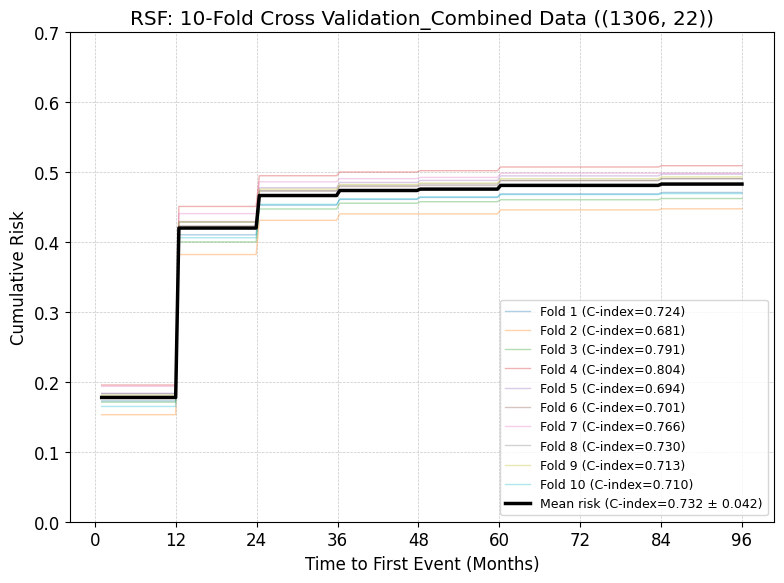

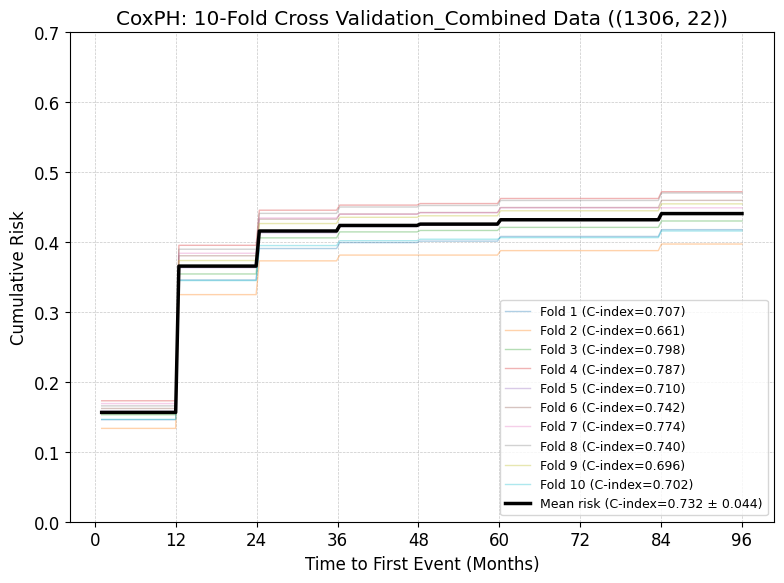

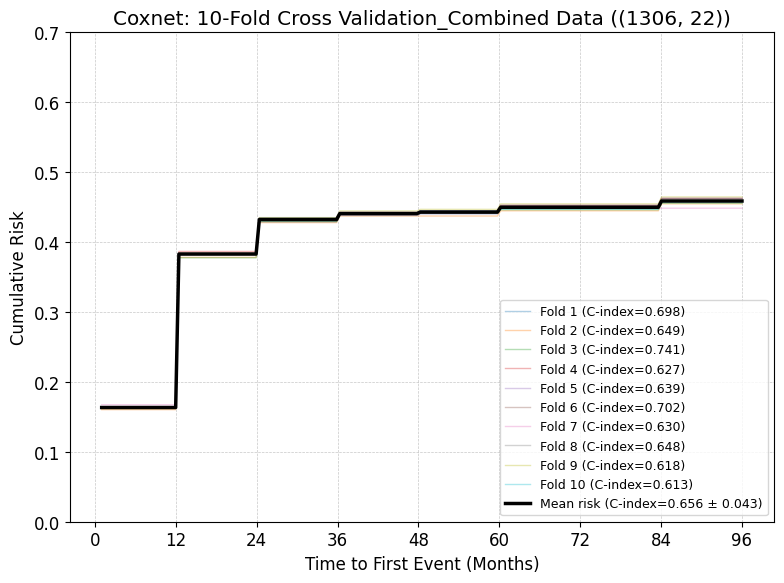

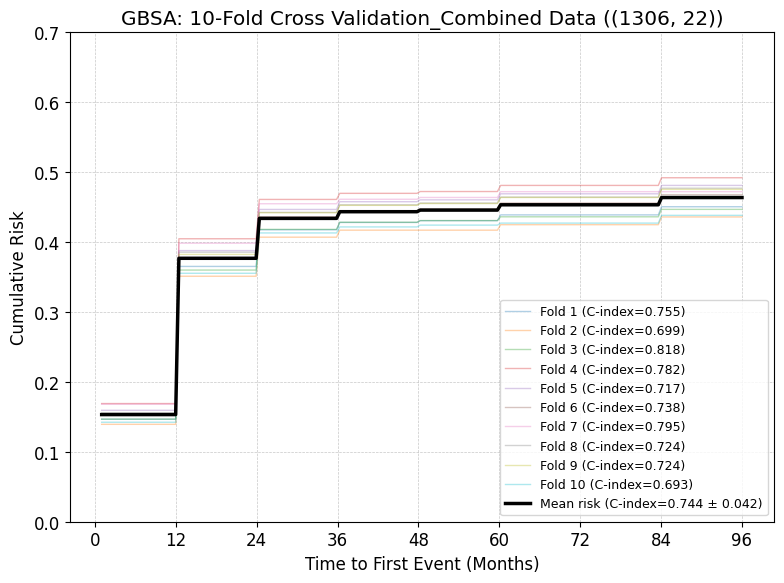

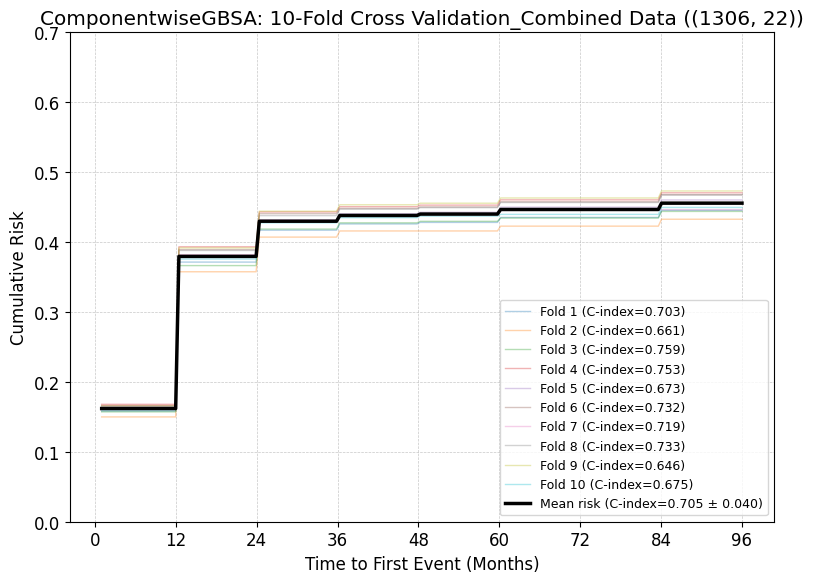

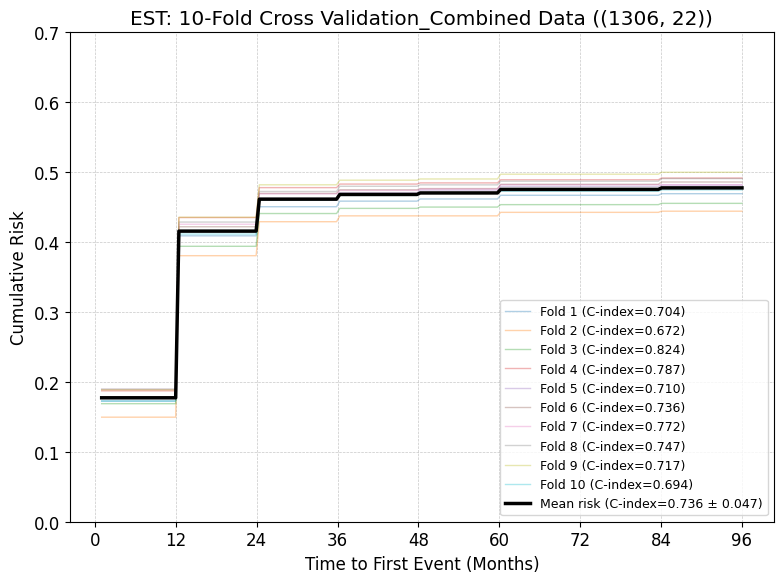


===== Cross-Validation Summary =====
            Model  Mean C-index  SD C-index  N folds  N samples  N features
             GBSA         0.744       0.042       10       1306          20
              EST         0.736       0.047       10       1306          20
            CoxPH         0.732       0.044       10       1306          20
              RSF         0.732       0.042       10       1306          20
ComponentwiseGBSA         0.705       0.040       10       1306          20
           Coxnet         0.656       0.043       10       1306          20


{'results': {'SVM': {'fold_c_index': [np.float64(0.7217170649185874),
    np.float64(0.6588208409506399),
    np.float64(0.8093249826026444),
    np.float64(0.7762775238886581),
    np.float64(0.7108953613807982),
    np.float64(0.7470231878002924),
    np.float64(0.7676720075400566),
    np.float64(0.7403910991233985),
    np.float64(0.6930182599355532),
    np.float64(0.6949375410913873)],
   'fold_mean_survival': [],
   'mean_c_index': None,
   'std_c_index': None,
   'mean_survival': None,
   'mean_risk': None,
   'time_grid': array([ 1.        ,  1.47738693,  1.95477387,  2.4321608 ,  2.90954774,
           3.38693467,  3.86432161,  4.34170854,  4.81909548,  5.29648241,
           5.77386935,  6.25125628,  6.72864322,  7.20603015,  7.68341709,
           8.16080402,  8.63819095,  9.11557789,  9.59296482, 10.07035176,
          10.54773869, 11.02512563, 11.50251256, 11.9798995 , 12.45728643,
          12.93467337, 13.4120603 , 13.88944724, 14.36683417, 14.84422111,
          15.321

In [114]:
# to have same patient number put common_df instead oh n_df_train
cross_validate_survival_models2(common_df, combined, duration_col='Timehyperpigmentation1', event_col='Eventhyperpigmentation1', event_type= 'First',  n_splits=10,
    n_time_points=200,    y_max=0.70,    y_tick_step=0.1,    random_state=42,    plot=True, s= 'Combined Data'
)

Data shape before preprocessing: (1306, 43)
Encoded 0 categorical columns:
[]
Data shape after encoding and cleaning: (1306, 22)

===== Fold 1 =====
SVM: C-index = 0.6342
RSF: C-index = 0.6156
CoxPH: C-index = 0.6263
Coxnet: C-index = 0.5661
GBSA: C-index = 0.6065
ComponentwiseGBSA: C-index = 0.6553
EST: C-index = 0.6120

===== Fold 2 =====
SVM: C-index = 0.5786
RSF: C-index = 0.5971
CoxPH: C-index = 0.5807
Coxnet: C-index = 0.5743
GBSA: C-index = 0.5631
ComponentwiseGBSA: C-index = 0.5768
EST: C-index = 0.6031

===== Fold 3 =====
SVM: C-index = 0.7133
RSF: C-index = 0.7117
CoxPH: C-index = 0.7077
Coxnet: C-index = 0.6435
GBSA: C-index = 0.7082
ComponentwiseGBSA: C-index = 0.7049
EST: C-index = 0.7082

===== Fold 4 =====
SVM: C-index = 0.6489
RSF: C-index = 0.6645
CoxPH: C-index = 0.6390
Coxnet: C-index = 0.5622
GBSA: C-index = 0.6924
ComponentwiseGBSA: C-index = 0.6267
EST: C-index = 0.6350

===== Fold 5 =====
SVM: C-index = 0.6198
RSF: C-index = 0.6095
CoxPH: C-index = 0.6170
Coxnet:

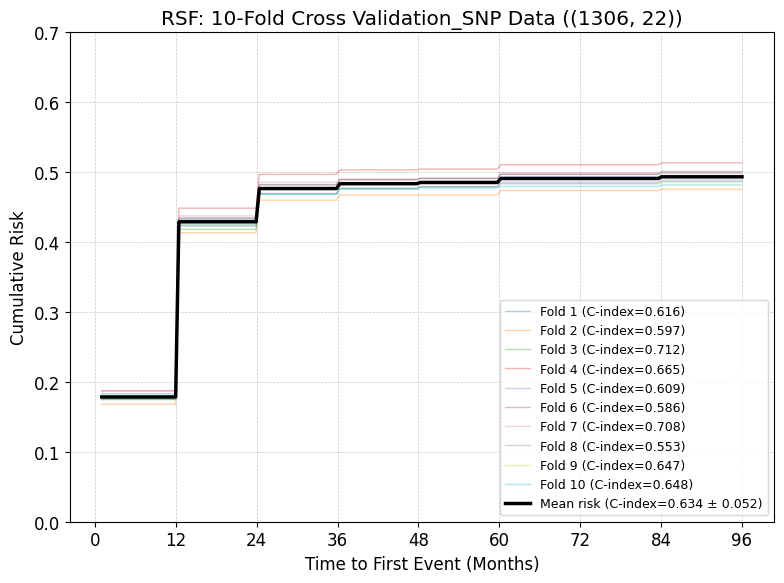

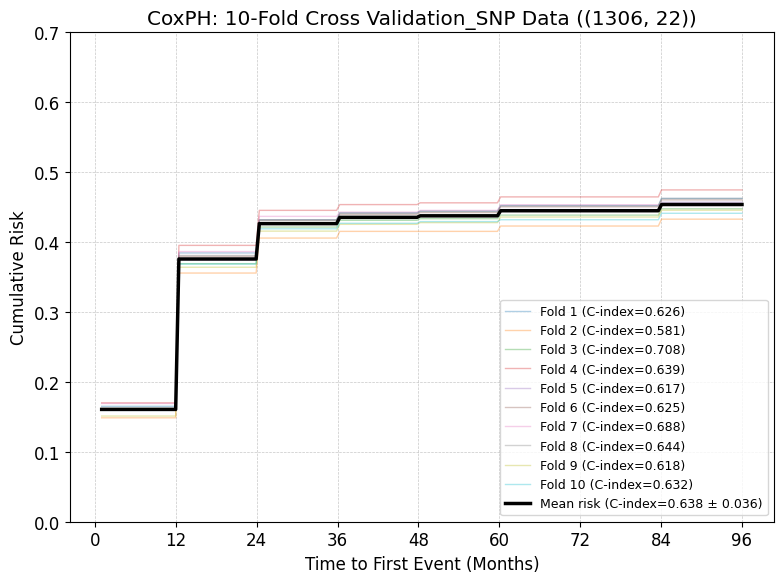

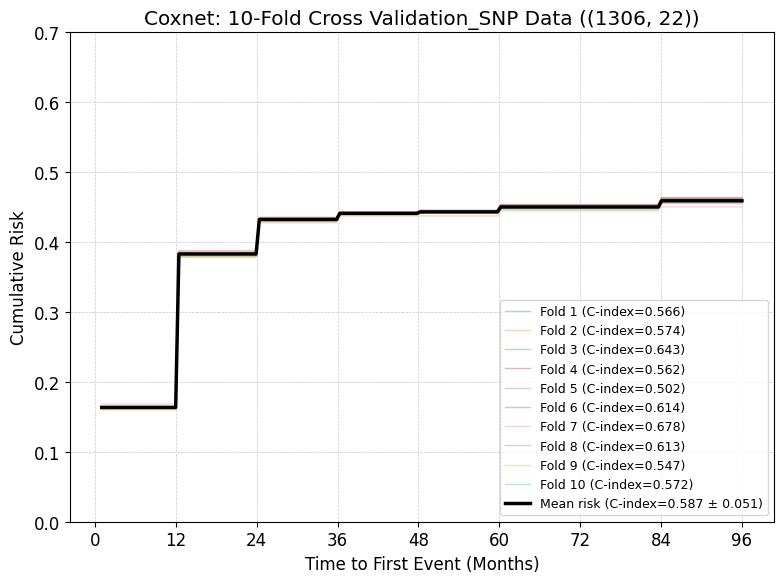

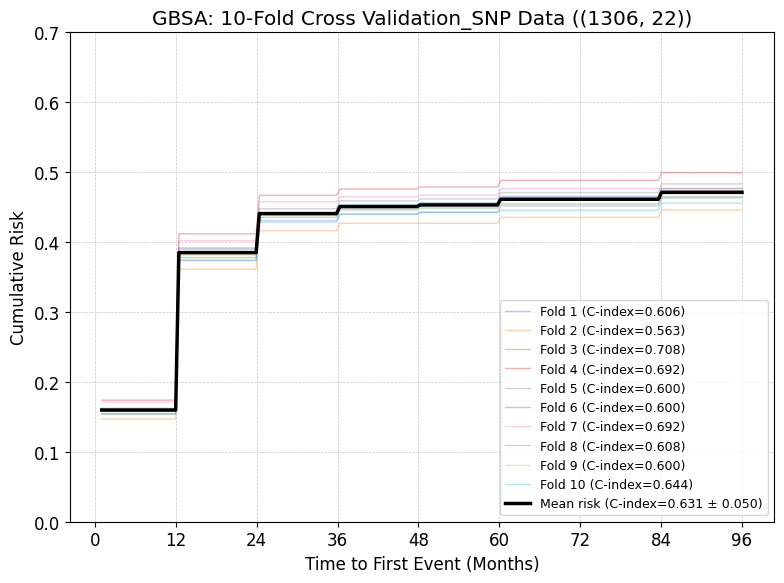

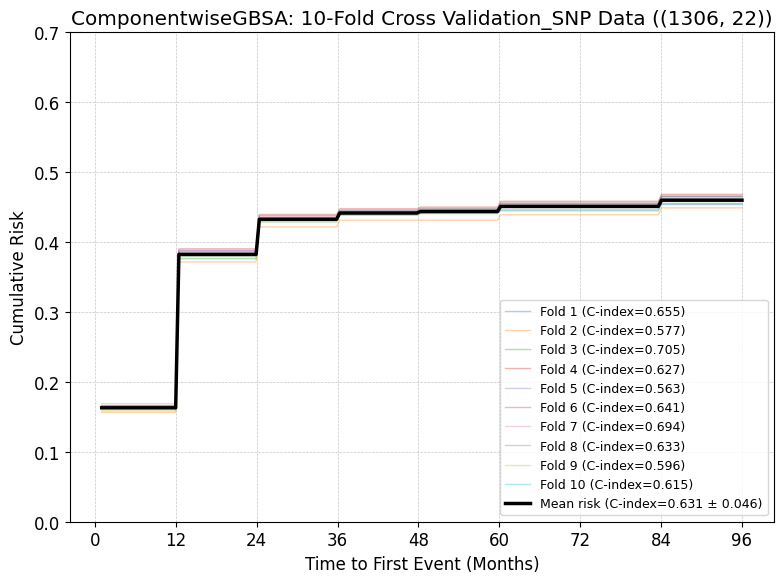

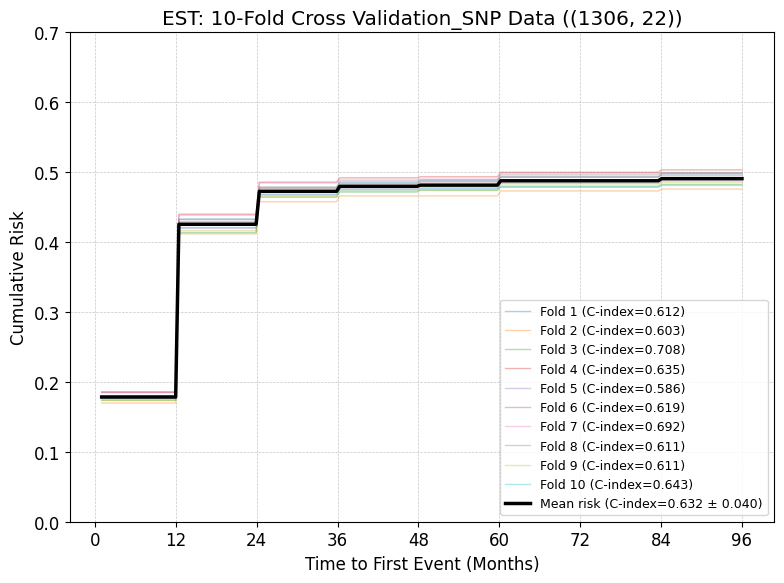


===== Cross-Validation Summary =====
            Model  Mean C-index  SD C-index  N folds  N samples  N features
            CoxPH         0.638       0.036       10       1306          20
              RSF         0.634       0.052       10       1306          20
              EST         0.632       0.040       10       1306          20
             GBSA         0.631       0.050       10       1306          20
ComponentwiseGBSA         0.631       0.046       10       1306          20
           Coxnet         0.587       0.051       10       1306          20


{'results': {'SVM': {'fold_c_index': [np.float64(0.6341721294142525),
    np.float64(0.5786106032906764),
    np.float64(0.7132915796798887),
    np.float64(0.6489405899459909),
    np.float64(0.619848975188781),
    np.float64(0.6239816168790474),
    np.float64(0.6783694627709708),
    np.float64(0.6516071027197123),
    np.float64(0.6098818474758324),
    np.float64(0.6241507779969319)],
   'fold_mean_survival': [],
   'mean_c_index': None,
   'std_c_index': None,
   'mean_survival': None,
   'mean_risk': None,
   'time_grid': array([ 1.        ,  1.47738693,  1.95477387,  2.4321608 ,  2.90954774,
           3.38693467,  3.86432161,  4.34170854,  4.81909548,  5.29648241,
           5.77386935,  6.25125628,  6.72864322,  7.20603015,  7.68341709,
           8.16080402,  8.63819095,  9.11557789,  9.59296482, 10.07035176,
          10.54773869, 11.02512563, 11.50251256, 11.9798995 , 12.45728643,
          12.93467337, 13.4120603 , 13.88944724, 14.36683417, 14.84422111,
          15.3216

In [115]:
# to have same patient number put common_df instead oh n_df_train
cross_validate_survival_models2(common_df, snp, duration_col='Timehyperpigmentation1', event_col='Eventhyperpigmentation1', event_type= 'First',  n_splits=10,
    n_time_points=200,    y_max=0.70,    y_tick_step=0.1,    random_state=42,    plot=True, s= 'SNP Data'
)

In [116]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold

from sksurv.util import Surv
from sksurv.metrics import (
    concordance_index_censored,
    cumulative_dynamic_auc,
    integrated_brier_score,
)
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import RandomSurvivalForest, GradientBoostingSurvivalAnalysis

In [117]:
# without svm and DL
def cross_validate_survival_models_table(
    df,
    feature_list,
    duration_col="Time1",
    event_col="Event1",
    event_type="First",
    time_unit="Months",
    n_splits=10,
    n_time_points=100,
    random_state=42,
    models=None,
    eval_times=None,
    min_eval_time=None,
    max_eval_time=None,
    plot=True,
    verbose=True,):

    # ----------------------------
    # 1) Prepare data
    # ----------------------------
    required_cols = [duration_col, event_col] + list(feature_list)
    df_model = df[required_cols].copy()

    if verbose:
        print("Data shape before preprocessing:", df_model.shape)

    # User-defined helper expected to exist
    df_model = encode_dataset(
        df_model,
        duration_col=duration_col,
        event_col=event_col
    )

    df_model = df_model.dropna().copy()

    if verbose:
        print("Data shape after encoding and cleaning:", df_model.shape)

    X = df_model[feature_list].astype(float)
    scaler = StandardScaler()
    X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

    y = Surv.from_dataframe(event_col, duration_col, df_model)
    event_indicator = df_model[event_col].astype(int).values

    if len(df_model) == 0:
        raise ValueError("No complete cases remain after preprocessing.")

    # ----------------------------
    # 2) Default model set
    # ----------------------------
    if models is None:
        models = {
            "RSF": RandomSurvivalForest(
                n_estimators=300,
                max_depth=None,
                min_samples_split=10,
                min_samples_leaf=5,
                max_features="sqrt",
                n_jobs=-1,
                random_state=12,
            ),
            "CoxPH": CoxPHSurvivalAnalysis(),
            "Coxnet": CoxnetSurvivalAnalysis(
                l1_ratio=0.1,  # mor ridge 0, more lasso 1, 0.5 balance between them
                alpha_min_ratio=0.001,
                fit_baseline_model=True,   # required for predict_survival_function
            ),
            "GBSA": GradientBoostingSurvivalAnalysis(
                loss="coxph",
                learning_rate=0.05,
                n_estimators=200,
                max_depth=3,
                random_state=12,
            ),
            "CWGBSA": ComponentwiseGradientBoostingSurvivalAnalysis(loss="coxph",                                  learning_rate=0.03,
                                        n_estimators=300,
                                        subsample=0.7,
                                        random_state=12),
            "EST": ExtraSurvivalTrees( n_estimators=300,max_depth=None,
            min_samples_split=10, min_samples_leaf=5, max_features="sqrt",
            n_jobs=-1, random_state=12,
        ),

        }


    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    # ----------------------------
    # 3) Storage
    # ----------------------------
    fold_rows = []
    stored_predictions = {
        model_name: {
            "fold_survival": [],
            "fold_risk": [],
            "fold_auc": [],
            "fold_times": [],
        }
        for model_name in models
    }

    # ----------------------------
    # 4) Cross-validation loop
    # ----------------------------
    for fold, (train_idx, test_idx) in enumerate(cv.split(X, event_indicator), start=1):
        if verbose:
            print(f"\n===== Fold {fold} =====")

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        train_times = X.iloc[train_idx].shape[0]  # just to keep fold local logic readable

        # Build a fold-safe evaluation grid.
        # For IPCW-based metrics, test follow-up must lie within the training range,
        # so we cap times below the largest observed training time.
        train_event_times = y_train[duration_col].astype(float)
        test_event_times = y_test[duration_col].astype(float)

        lower_bound = float(np.min(test_event_times))
        upper_bound = float(
            np.nextafter(
                min(np.max(test_event_times), np.max(train_event_times)),
                -np.inf
            )
        )

        if min_eval_time is not None:
            lower_bound = max(lower_bound, float(min_eval_time))
        if max_eval_time is not None:
            upper_bound = min(upper_bound, float(max_eval_time))

        if eval_times is None:
            if lower_bound >= upper_bound:
                # fallback: use percentiles of training times
                lower_bound = float(np.percentile(train_event_times, 10))
                upper_bound = float(np.nextafter(np.percentile(train_event_times, 90), -np.inf))

            times = np.linspace(lower_bound, upper_bound, n_time_points)
        else:
            times = np.asarray(eval_times, dtype=float)
            times = times[(times >= lower_bound) & (times <= upper_bound)]

        if times.size < 2:
            raise ValueError(
                f"Fold {fold}: evaluation time grid is too small after applying "
                "training/test follow-up constraints."
            )

        for model_name, base_model in models.items():
            model = clone(base_model)

            try:
                model.fit(X_train, y_train)

                # ---- survival probabilities on common fold-specific grid
                surv_fns = model.predict_survival_function(X_test)
                surv_probs = np.row_stack([fn(times) for fn in surv_fns])

                # Numerical safety
                surv_probs = np.clip(surv_probs, 0.0, 1.0)

                # ---- risk definitions
                # scalar risk for C-index
                scalar_risk = 1.0 - surv_probs[:, -1]

                # time-dependent risk for AUC
                risk_matrix = 1.0 - surv_probs

                # ---- C-index
                c_index = concordance_index_censored(
                    y_test[event_col],
                    y_test[duration_col],
                    scalar_risk
                )[0]

                # ---- time-dependent AUC
                auc_values, mean_auc = cumulative_dynamic_auc(
                    y_train,
                    y_test,
                    risk_matrix,
                    times
                )

                # ---- IBS
                ibs = integrated_brier_score(
                    y_train,
                    y_test,
                    surv_probs,
                    times
                )

                stored_predictions[model_name]["fold_survival"].append(surv_probs.mean(axis=0))
                stored_predictions[model_name]["fold_risk"].append(risk_matrix.mean(axis=0))
                stored_predictions[model_name]["fold_auc"].append(auc_values)
                stored_predictions[model_name]["fold_times"].append(times)

                fold_rows.append({
                    "fold": fold,
                    "model": model_name,
                    "c_index": float(c_index),
                    "mean_auc": float(mean_auc),
                    "ibs": float(ibs),
                    "n_train": int(len(train_idx)),
                    "n_test": int(len(test_idx)),
                })

                if verbose:
                    print(
                        f"{model_name}: "
                        f"C-index={c_index:.3f}, "
                        f"mean AUC={mean_auc:.3f}, "
                        f"IBS={ibs:.3f}"
                    )

            except Exception as e:
                fold_rows.append({
                    "fold": fold,
                    "model": model_name,
                    "c_index": np.nan,
                    "mean_auc": np.nan,
                    "ibs": np.nan,
                    "n_train": int(len(train_idx)),
                    "n_test": int(len(test_idx)),
                    "error": str(e),
                })

                if verbose:
                    print(f"{model_name}: failed on fold {fold} with error: {e}")

    fold_metrics = pd.DataFrame(fold_rows)

    # ----------------------------
    # 5) Summary table
    # ----------------------------
    summary_table = (
        fold_metrics
        .groupby("model", dropna=False)
        .agg(
            mean_c_index=("c_index", "mean"),
            sd_c_index=("c_index", "std"),
            mean_auc=("mean_auc", "mean"),
            sd_auc=("mean_auc", "std"),
            mean_ibs=("ibs", "mean"),
            sd_ibs=("ibs", "std"),
            successful_folds=("fold", "count"),
        )
        .reset_index()
        .sort_values(
            by=["mean_c_index", "mean_auc", "mean_ibs"],
            ascending=[False, False, True]
        )
    )

    # ----------------------------
    # 6) Plotting
    # ----------------------------
    if plot:
        # A) Metric comparison
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))

        order = summary_table["model"].tolist()

        axes[0].bar(order, summary_table["mean_c_index"])
        axes[0].set_title("Mean C-index")
        axes[0].set_ylabel("C-index")

        axes[1].bar(order, summary_table["mean_auc"])
        axes[1].set_title("Mean Time-dependent AUC")
        axes[1].set_ylabel("AUC")

        axes[2].bar(order, summary_table["mean_ibs"])
        axes[2].set_title("Mean IBS")
        axes[2].set_ylabel("IBS")

        for ax in axes:
            ax.tick_params(axis="x", rotation=45)
            ax.grid(True, axis="y", linestyle="--", alpha=0.5)

        plt.tight_layout()
        plt.show()

        # B) Mean cumulative risk per model
        for model_name, pred in stored_predictions.items():
            if len(pred["fold_survival"]) == 0:
                continue

            # Fold-specific times can differ slightly. Interpolate onto a shared plot grid.
            common_min = max(np.min(t) for t in pred["fold_times"])
            common_max = min(np.max(t) for t in pred["fold_times"])

            if common_min >= common_max:
                continue

            plot_grid = np.linspace(common_min, common_max, n_time_points)
            fold_risks_interp = []

            for fold_times, fold_surv in zip(pred["fold_times"], pred["fold_survival"]):
                fold_risk = 1.0 - fold_surv
                interp_risk = np.interp(plot_grid, fold_times, fold_risk)
                fold_risks_interp.append(interp_risk)

            fold_risks_interp = np.vstack(fold_risks_interp)
            mean_risk = fold_risks_interp.mean(axis=0)

            plt.figure(figsize=(8, 5))
            for i in range(fold_risks_interp.shape[0]):
                plt.plot(plot_grid, fold_risks_interp[i], alpha=0.30, linewidth=1)

            plt.plot(plot_grid, mean_risk, color="black", linewidth=2.5)

            row = summary_table.loc[summary_table["model"] == model_name].iloc[0]

            plt.title(
                f"{model_name}: {n_splits}-Fold Cross-Validation\n"
                f"C-index={row['mean_c_index']:.3f}, "
                f"AUC={row['mean_auc']:.3f}, "
                f"IBS={row['mean_ibs']:.3f}"
            )
            plt.xlabel(f"Time to {event_type} Event ({time_unit})")
            plt.ylabel("Cumulative Risk")
            plt.ylim(0, 1)
            plt.grid(True, linestyle="--", alpha=0.5)
            plt.tight_layout()
            plt.show()

    return {
        "summary_table": summary_table,
        "fold_metrics": fold_metrics,
        "predictions": stored_predictions,
        "time_grid": None if eval_times is None else np.asarray(eval_times, dtype=float),
    }

Data shape before preprocessing: (1544, 22)
Encoded 1 categorical columns:
['t_stage']
Data shape after encoding and cleaning: (1387, 22)

===== Fold 1 =====
RSF: C-index=0.760, mean AUC=0.840, IBS=0.158
CoxPH: C-index=0.718, mean AUC=0.762, IBS=0.174
Coxnet: C-index=0.691, mean AUC=0.721, IBS=0.198
GBSA: C-index=0.744, mean AUC=0.792, IBS=0.160
CWGBSA: C-index=0.723, mean AUC=0.770, IBS=0.173
EST: C-index=0.729, mean AUC=0.817, IBS=0.173

===== Fold 2 =====
RSF: C-index=0.723, mean AUC=0.693, IBS=0.198
CoxPH: C-index=0.738, mean AUC=0.701, IBS=0.192
Coxnet: C-index=0.706, mean AUC=0.732, IBS=0.209
GBSA: C-index=0.759, mean AUC=0.715, IBS=0.193
CWGBSA: C-index=0.730, mean AUC=0.677, IBS=0.190
EST: C-index=0.717, mean AUC=0.835, IBS=0.194

===== Fold 3 =====
RSF: C-index=0.749, mean AUC=0.829, IBS=0.214
CoxPH: C-index=0.765, mean AUC=0.814, IBS=0.215
Coxnet: C-index=0.720, mean AUC=0.727, IBS=0.234
GBSA: C-index=0.784, mean AUC=0.827, IBS=0.204
CWGBSA: C-index=0.735, mean AUC=0.789, IBS

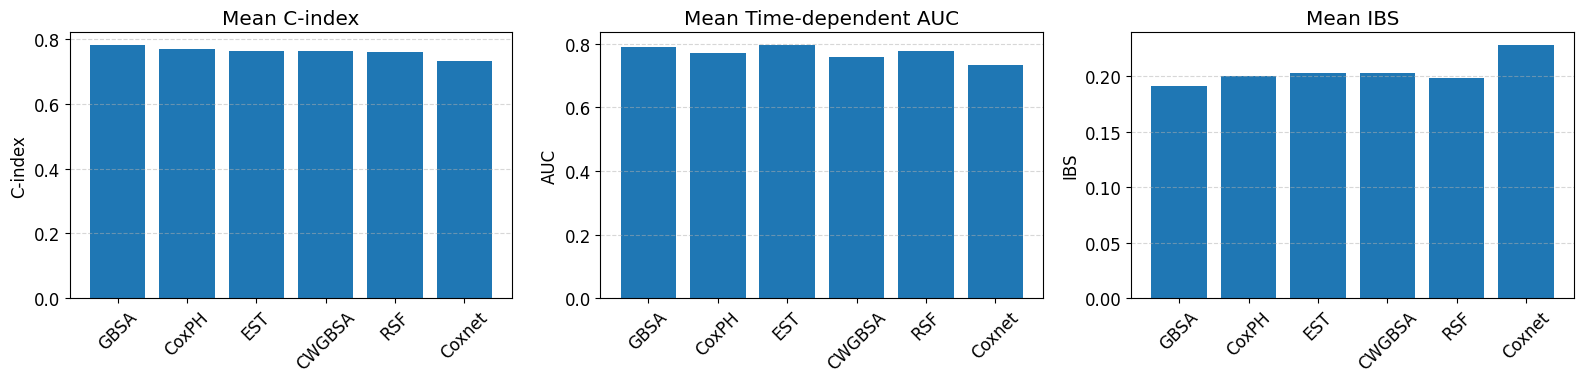

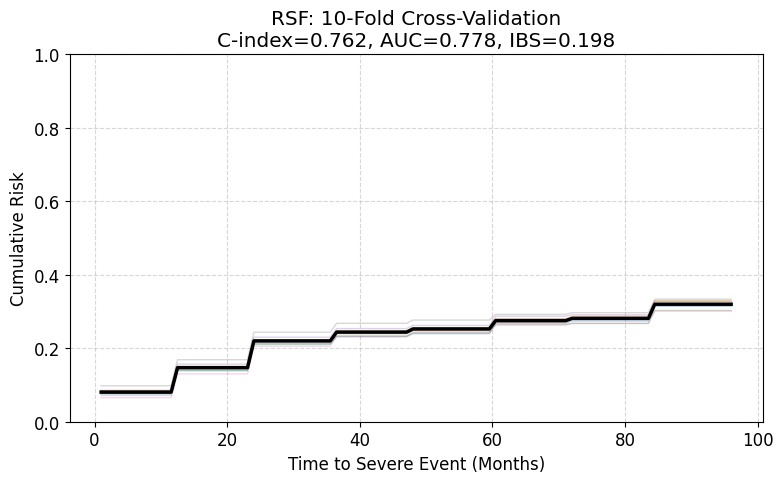

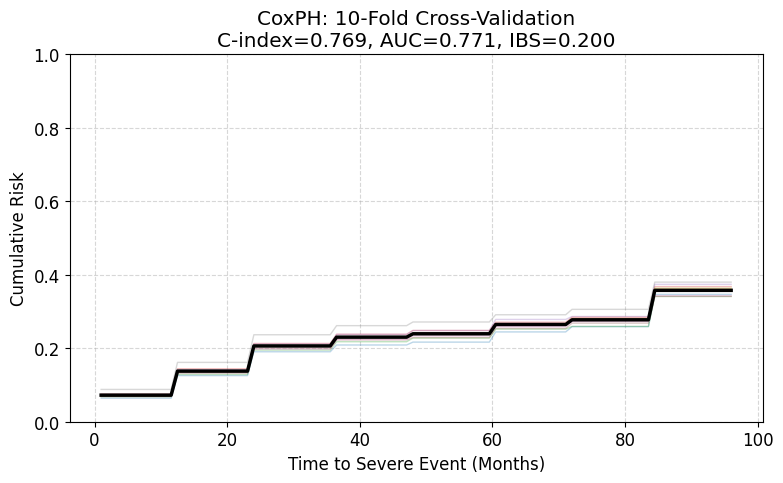

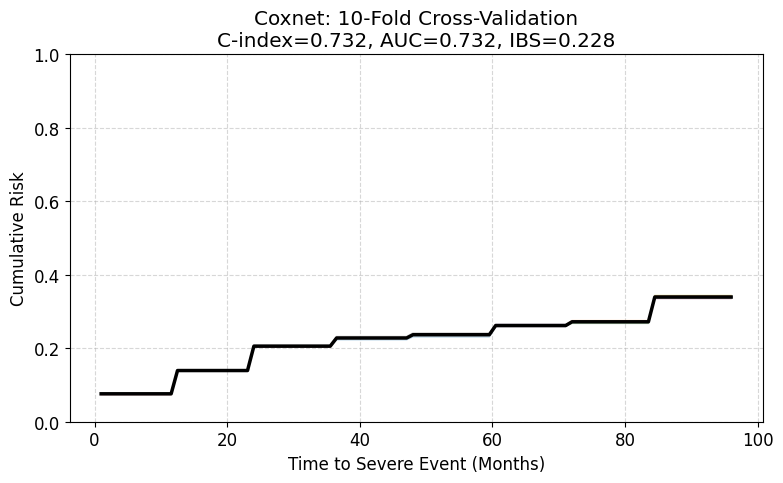

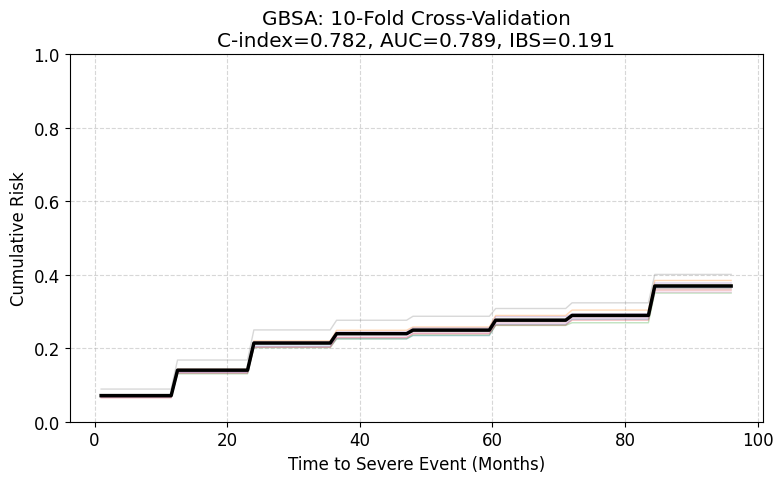

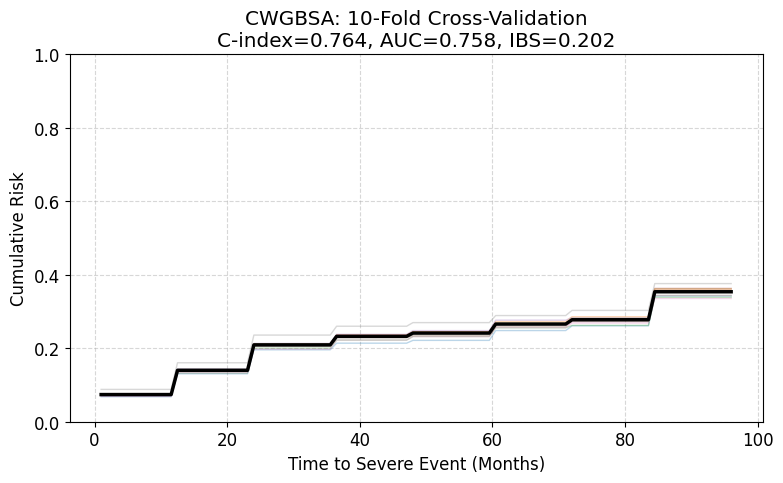

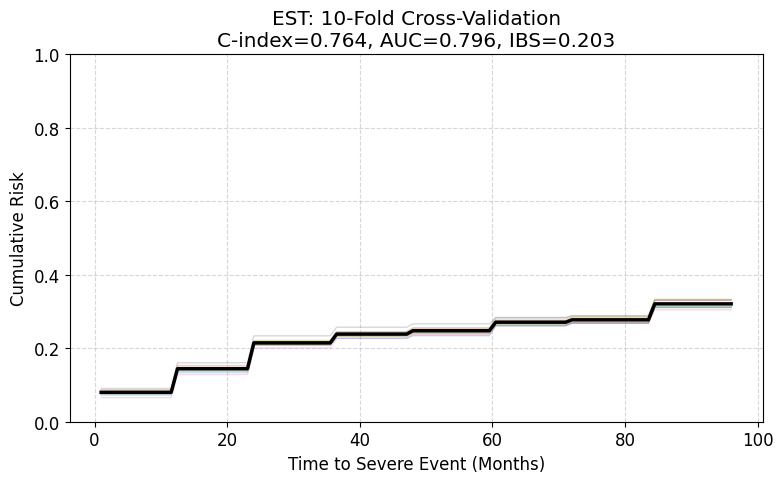

,model,mean_c_index,sd_c_index,mean_auc,sd_auc,mean_ibs,sd_ibs,successful_folds
4,GBSA,0.781927,0.047021,0.788553,0.062075,0.191199,0.023341,10
1,CoxPH,0.769244,0.044910,0.770866,0.090624,0.200052,0.026075,10
3,EST,0.763801,0.054087,0.795975,0.083091,0.202716,0.025780,10
0,CWGBSA,0.763597,0.044474,0.757758,0.092210,0.202309,0.025974,10
5,RSF,0.761685,0.051094,0.777653,0.098112,0.198308,0.030511,10
2,Coxnet,0.732437,0.041153,0.731618,0.050099,0.227927,0.026128,10


In [ ]:
'''results = cross_validate_survival_models_table(
    df=n_df1_train,
    feature_list=clinic,
    duration_col="TimeAtrophy2",
    event_col="EventAtrophy2",
    event_type="Severe",
    time_unit="Months",
    n_splits=10,
    n_time_points=100,
    plot=True,
    verbose=True,
)
results["summary_table"]
'''

## Deep Learning + ML Models

In [118]:
pip install pycox torchtuples

In [119]:
import torch
from pycox.models import CoxPH
import torchtuples as tt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

from sksurv.util import Surv
from sksurv.metrics import (
    concordance_index_censored,
    cumulative_dynamic_auc,
    integrated_brier_score,)

from sksurv.linear_model import (
    CoxPHSurvivalAnalysis,
    CoxnetSurvivalAnalysis,)

from sksurv.ensemble import (
    RandomSurvivalForest,
    GradientBoostingSurvivalAnalysis,
    ExtraSurvivalTrees,
    ComponentwiseGradientBoostingSurvivalAnalysis,)
# SVM
from sksurv.svm import FastSurvivalSVM
# Deep learning imports
import torch
import torchtuples as tt
from pycox.models import CoxPH as PyCoxCoxPH


In [120]:
def plot_cumulative_risk_curves(
    stored_predictions,
    summary_table,
    n_time_points=100,
    event_type="First",
    time_unit="Months",):
    """
    Plot fold-specific and mean cumulative risk curves for all models
    stored in `stored_predictions`.

    Parameters
    ----------
    stored_predictions : dict
        Dictionary like:
        {
            model_name: {
                "fold_survival": [array(T), array(T), ...],
                "fold_times": [array(T), array(T), ...]
            }
        }
    summary_table : pd.DataFrame
        Summary table containing model-level metrics.
    n_time_points : int
        Number of points in the common plotting grid.
    event_type : str
        Label for plot titles.
    time_unit : str
        Label for x-axis.
    """
    for model_name, pred in stored_predictions.items():
        if len(pred["fold_survival"]) == 0:
            continue

        # find overlapping time window across folds
        common_min = max(np.min(t) for t in pred["fold_times"])
        common_max = min(np.max(t) for t in pred["fold_times"])

        if common_min >= common_max:
            print(f"Skipping {model_name}: no overlapping time range across folds.")
            continue

        plot_grid = np.linspace(common_min, common_max, n_time_points)

        fold_risks_interp = []
        for fold_times, fold_surv in zip(pred["fold_times"], pred["fold_survival"]):
            fold_risk = 1.0 - np.asarray(fold_surv)
            interp_risk = np.interp(plot_grid, fold_times, fold_risk)
            fold_risks_interp.append(interp_risk)

        fold_risks_interp = np.vstack(fold_risks_interp)
        mean_risk = fold_risks_interp.mean(axis=0)

        plt.figure(figsize=(8, 5))

        for i in range(fold_risks_interp.shape[0]):
            plt.plot(
                plot_grid,
                fold_risks_interp[i],
                alpha=0.30,
                linewidth=1,
                label=f"Fold {i+1}" if i < 1 else None  # avoid huge legends
            )

        plt.plot(
            plot_grid,
            mean_risk,
            color="black",
            linewidth=2.5,
            label="Mean cumulative risk"
        )

        row = summary_table.loc[summary_table["model"] == model_name]
        if not row.empty:
            row = row.iloc[0]
            title = (
                f"{model_name}: Cumulative Risk Curve\n"
                f"C-index={row['mean_c_index']:.3f}, "
                f"AUC={row['mean_auc']:.3f}, "
                f"IBS={row['mean_ibs']:.3f}"
            )
        else:
            title = f"{model_name}: Cumulative Risk Curve"

        plt.title(title)
        plt.xlabel(f"Time to {event_type} Event ({time_unit})")
        plt.ylabel("Cumulative Risk")
        plt.ylim(0, 1)
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.legend()
        plt.tight_layout()
        plt.show()

In [121]:
# THIS FUNCTION TO PLOT THE CURVE FOR ALL MODELS
def plot_cumulative_risk_curves_combined(
    stored_predictions,
    summary_table,
    n_time_points=200,
    event_type="First",
    time_unit="Months",
    y_limits=None, s= 'clinic'):
    plt.figure(figsize=(10, 8))
    ax = plt.gca()

    # Highest C-index → lowest C-index
    model_order = (
        summary_table
        .sort_values("mean_c_index", ascending=False)["model"]
        .tolist()
    )

    for model_name in model_order:

        if model_name not in stored_predictions:
            continue

        pred = stored_predictions[model_name]

        if len(pred["fold_survival"]) == 0:
            continue

        common_min = max(
            np.min(t) for t in pred["fold_times"]
        )
        common_max = min(
            np.max(t) for t in pred["fold_times"]
        )

        if common_min >= common_max:
            continue

        plot_grid = np.linspace(
            common_min,
            common_max,
            n_time_points
        )

        fold_risks_interp = []

        for fold_times, fold_surv in zip(
            pred["fold_times"],
            pred["fold_survival"]
        ):
            fold_risk = 1.0 - np.asarray(fold_surv)

            interp_risk = np.interp(
                plot_grid,
                fold_times,
                fold_risk
            )

            fold_risks_interp.append(interp_risk)

        fold_risks_interp = np.vstack(fold_risks_interp)

        mean_risk = fold_risks_interp.mean(axis=0)
        q25 = np.percentile(fold_risks_interp, 25, axis=0)
        q75 = np.percentile(fold_risks_interp, 75, axis=0)

        row = summary_table.loc[
            summary_table["model"] == model_name
        ]

        if not row.empty:
            row = row.iloc[0]

            metric_text = (
                f"{model_name} "
                f"(C-index={row['mean_c_index']:.3f}, "
                f"AUC={row['mean_auc']:.3f}, "
                f"IBS={row['mean_ibs']:.3f})"
            )
        else:
            metric_text = model_name

        # IQR
        #ax.fill_between(plot_grid, q25, q75, alpha=0.12, zorder=1)

        # Mean curve
        ax.step(
            plot_grid,
            mean_risk,
            where="post",
            linewidth=2.4,
            label=metric_text,
            zorder=2
        )

    ax.set_title(
        f"Cumulative Risk Curves {s} ",
        fontsize=16,
        pad=15
    )

    ax.set_xlabel(
        f"Time to {event_type} Event ({time_unit})",
        fontsize=12
    )

    ax.set_ylabel(
        "Cumulative Risk",
        fontsize=12
    )

    if y_limits is not None:
        ax.set_ylim(*y_limits)
    else:
        ax.set_ylim(0, 1)

    x_max = ax.get_xlim()[1]

    if x_max <= 24:
        step = 3
    elif x_max <= 60:
        step = 6
    else:
        step = 12

    ax.set_xticks(
        np.arange(0, np.ceil(x_max) + 1, step)
    )

    ax.grid(
        True,
        linestyle="--",
        linewidth=0.6,
        alpha=0.5
    )

    ax.legend(
        frameon=True,
        loc="upper left",
        fontsize=10
    )

    plt.tight_layout()
    plt.show()

In [122]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

from sksurv.util import Surv
from sksurv.metrics import (
    concordance_index_censored,
    cumulative_dynamic_auc,
    integrated_brier_score,
)
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (
    RandomSurvivalForest,
    GradientBoostingSurvivalAnalysis,
)
# ensemble
from sksurv.ensemble import ExtraSurvivalTrees
# Deep learning imports
import torch
import torchtuples as tt
from pycox.models import CoxPH as PyCoxCoxPH


def make_deepsurv_model(in_features, lr=1e-3, num_nodes=[32, 32], dropout=0.1):
    """
    Create a DeepSurv-style neural Cox model using pycox.
    """
    net = tt.practical.MLPVanilla(
        in_features=in_features,
        num_nodes=num_nodes,
        out_features=1,
        batch_norm=True,
        dropout=dropout,
        output_bias=False
    )
    model = PyCoxCoxPH(net, tt.optim.Adam(lr=lr))
    return model


def cross_validate_survival_models_with_deepsurv(
    df,
    feature_list,
    duration_col="Time1",
    event_col="Event1",
    event_type="First",
    time_unit="Months",
    n_splits=10,
    n_time_points=100,
    random_state=42,
    eval_times=None,
    min_eval_time=None,
    max_eval_time=None,
    plot=True,
    verbose=True,
    deepsurv_epochs=100,
    deepsurv_patience=10,):
    """
    Cross-validate RSF, CoxPH, Coxnet, GBSA, and DeepSurv using:
      - Harrell's C-index
      - cumulative/dynamic AUC
      - IBS

    Assumes encode_dataset() exists.
    """

    # ----------------------------
    # 1) Data prep
    # ----------------------------
    required_cols = [duration_col, event_col] + list(feature_list)
    df_model = df[required_cols].copy()

    if verbose:
        print("Data shape before preprocessing:", df_model.shape)

    df_model = encode_dataset(
        df_model,
        duration_col=duration_col,
        event_col=event_col
    )

    df_model = df_model.dropna().copy()

    if verbose:
        print("Data shape after encoding and cleaning:", df_model.shape)

    X = df_model[feature_list].astype(float)
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    X = pd.DataFrame(X, columns=feature_list)
    y = Surv.from_dataframe(event_col, duration_col, df_model)
    event_indicator = df_model[event_col].astype(int).values

    if len(df_model) == 0:
        raise ValueError("No complete cases remain after preprocessing.")

    # ----------------------------
    # 2) Classical / ML models
    # ----------------------------
    classical_models = {
        "RSF": RandomSurvivalForest(
            n_estimators=300,
            max_depth=None,
            min_samples_split=10,
            min_samples_leaf=5,
            max_features="sqrt",
            n_jobs=-1,
            random_state=12,
        ),
        "CoxPH": CoxPHSurvivalAnalysis(),
        "Coxnet": CoxnetSurvivalAnalysis(
            l1_ratio=0.5,
            alpha_min_ratio=0.01,
            fit_baseline_model=True,
        ),
        "GBSA": GradientBoostingSurvivalAnalysis(
            loss="coxph",
            learning_rate=0.05,
            n_estimators=200,
            max_depth=3,
            random_state=12,
        ),
        "CWGBSA": ComponentwiseGradientBoostingSurvivalAnalysis(
            loss="coxph", learning_rate=0.03,                                   n_estimators=300, subsample=0.7,                                        random_state=12),
        "EST": ExtraSurvivalTrees( n_estimators=300,max_depth=None,
            min_samples_split=10, min_samples_leaf=5, max_features="sqrt",
            n_jobs=-1, random_state=12,
        ),
    }

    all_model_names = list(classical_models.keys()) + ["DeepSurv"]

    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    # ----------------------------
    # 3) Storage
    # ----------------------------
    fold_rows = []
    stored_predictions = {
        model_name: {
            "fold_survival": [],
            "fold_risk": [],
            "fold_auc": [],
            "fold_times": [],
        }
        for model_name in all_model_names
    }

    # ----------------------------
    # 4) CV loop
    # ----------------------------
    for fold, (train_idx, test_idx) in enumerate(cv.split(X, event_indicator), start=1):
        if verbose:
            print(f"\n===== Fold {fold} =====")

        X_train_df, X_test_df = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        train_event_times = y_train[duration_col].astype(float)
        test_event_times = y_test[duration_col].astype(float)

        #lower_bound = float(np.min(test_event_times))
        #upper_bound = float(np.nextafter(np.max(train_event_times), -np.inf))
        lower_bound = float(np.min(test_event_times))
        upper_bound = float(
            np.nextafter(
                min(np.max(test_event_times), np.max(train_event_times)),
                -np.inf
            )
        )

        if min_eval_time is not None:
            lower_bound = max(lower_bound, float(min_eval_time))
        if max_eval_time is not None:
            upper_bound = min(upper_bound, float(max_eval_time))

        if eval_times is None:
            if lower_bound >= upper_bound:
                lower_bound = float(np.percentile(train_event_times, 10))
                upper_bound = float(np.nextafter(np.percentile(train_event_times, 90), -np.inf))
            times = np.linspace(lower_bound, upper_bound, n_time_points)
        else:
            times = np.asarray(eval_times, dtype=float)
            times = times[(times >= lower_bound) & (times <= upper_bound)]

        if times.size < 2:
            raise ValueError(f"Fold {fold}: evaluation time grid too small.")

        # ---------------------------------
        # 4A) scikit-survival models
        # ---------------------------------
        for model_name, base_model in classical_models.items():
            model = clone(base_model)

            try:
                model.fit(X_train_df, y_train)

                surv_fns = model.predict_survival_function(X_test_df)
                surv_probs = np.row_stack([fn(times) for fn in surv_fns])
                surv_probs = np.clip(surv_probs, 0.0, 1.0)

                scalar_risk = 1.0 - surv_probs[:, -1]
                risk_matrix = 1.0 - surv_probs

                c_index = concordance_index_censored(
                    y_test[event_col],
                    y_test[duration_col],
                    scalar_risk
                )[0]

                auc_values, mean_auc = cumulative_dynamic_auc(
                    y_train,
                    y_test,
                    risk_matrix,
                    times
                )

                ibs = integrated_brier_score(
                    y_train,
                    y_test,
                    surv_probs,
                    times
                )

                stored_predictions[model_name]["fold_survival"].append(surv_probs.mean(axis=0))
                stored_predictions[model_name]["fold_risk"].append(risk_matrix.mean(axis=0))
                stored_predictions[model_name]["fold_auc"].append(auc_values)
                stored_predictions[model_name]["fold_times"].append(times)

                fold_rows.append({
                    "fold": fold,
                    "model": model_name,
                    "c_index": float(c_index),
                    "mean_auc": float(mean_auc),
                    "ibs": float(ibs),
                })

                if verbose:
                    print(
                        f"{model_name}: "
                        f"C-index={c_index:.3f}, "
                        f"mean AUC={mean_auc:.3f}, "
                        f"IBS={ibs:.3f}"
                    )

            except Exception as e:
                fold_rows.append({
                    "fold": fold,
                    "model": model_name,
                    "c_index": np.nan,
                    "mean_auc": np.nan,
                    "ibs": np.nan,
                    "error": str(e),
                })
                if verbose:
                    print(f"{model_name} failed on fold {fold}: {e}")

        # ---------------------------------
        # 4B) DeepSurv (pycox)
        # ---------------------------------
        try:
            # Scale features for neural net
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train_df).astype("float32")
            X_test = scaler.transform(X_test_df).astype("float32")

            # pycox target format: (durations, events)
            y_train_pycox = (
                df_model.iloc[train_idx][duration_col].values.astype("float32"),
                df_model.iloc[train_idx][event_col].values.astype("float32"),
            )

            # small validation split from training fold
            rng = np.random.default_rng(seed=random_state + fold)
            perm = rng.permutation(len(X_train))
            val_size = max(1, int(0.15 * len(X_train)))
            val_idx = perm[:val_size]
            tr_idx = perm[val_size:]

            X_tr, X_val = X_train[tr_idx], X_train[val_idx]
            y_tr = (y_train_pycox[0][tr_idx], y_train_pycox[1][tr_idx])
            y_val = (y_train_pycox[0][val_idx], y_train_pycox[1][val_idx])

            in_features = X_train.shape[1]
            deepsurv_model = make_deepsurv_model(
                in_features=in_features,
                lr=1e-3,
                num_nodes=[32, 32],
                dropout=0.1
            )

            callbacks = [tt.callbacks.EarlyStopping(patience=deepsurv_patience)]

            _ = deepsurv_model.fit(
                X_tr,
                y_tr,
                batch_size=256,
                epochs=deepsurv_epochs,
                callbacks=callbacks,
                verbose=False,
                val_data=(X_val, y_val),
            )

            deepsurv_model.compute_baseline_hazards()

            # pycox returns a DataFrame: index=time, columns=patients
            surv_df = deepsurv_model.predict_surv_df(X_test)

            # interpolate survival predictions onto the same evaluation grid
            surv_probs = np.row_stack([
                np.interp(
                    times,
                    surv_df.index.values.astype(float),
                    surv_df.iloc[:, i].values.astype(float),
                    left=1.0,
                    right=surv_df.iloc[:, i].values.astype(float)[-1]
                )
                for i in range(surv_df.shape[1])
            ])

            surv_probs = np.clip(surv_probs, 0.0, 1.0)

            scalar_risk = 1.0 - surv_probs[:, -1]
            risk_matrix = 1.0 - surv_probs

            c_index = concordance_index_censored(
                y_test[event_col],
                y_test[duration_col],
                scalar_risk
            )[0]

            auc_values, mean_auc = cumulative_dynamic_auc(
                y_train,
                y_test,
                risk_matrix,
                times
            )

            ibs = integrated_brier_score(
                y_train,
                y_test,
                surv_probs,
                times
            )

            stored_predictions["DeepSurv"]["fold_survival"].append(surv_probs.mean(axis=0))
            stored_predictions["DeepSurv"]["fold_risk"].append(risk_matrix.mean(axis=0))
            stored_predictions["DeepSurv"]["fold_auc"].append(auc_values)
            stored_predictions["DeepSurv"]["fold_times"].append(times)

            fold_rows.append({
                "fold": fold,
                "model": "DeepSurv",
                "c_index": float(c_index),
                "mean_auc": float(mean_auc),
                "ibs": float(ibs),
            })

            if verbose:
                print(
                    f"DeepSurv: "
                    f"C-index={c_index:.3f}, "
                    f"mean AUC={mean_auc:.3f}, "
                    f"IBS={ibs:.3f}"
                )

        except Exception as e:
            fold_rows.append({
                "fold": fold,
                "model": "DeepSurv",
                "c_index": np.nan,
                "mean_auc": np.nan,
                "ibs": np.nan,
                "error": str(e),
            })
            if verbose:
                print(f"DeepSurv failed on fold {fold}: {e}")

    # ----------------------------
    # 5) Tables
    # ----------------------------
    fold_metrics = pd.DataFrame(fold_rows)

    summary_table = (
        fold_metrics
        .groupby("model", dropna=False)
        .agg(
            mean_c_index=("c_index", "mean"),
            sd_c_index=("c_index", "std"),
            mean_auc=("mean_auc", "mean"),
            sd_auc=("mean_auc", "std"),
            mean_ibs=("ibs", "mean"),
            sd_ibs=("ibs", "std"),
            successful_folds=("fold", "count"),
        )
        .reset_index()
        .sort_values(
            by=["mean_c_index", "mean_auc", "mean_ibs"],
            ascending=[False, False, True]
        )
    )

    # ----------------------------
    # 6) Plots
    # ----------------------------
    if plot:
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))
        order = summary_table["model"].tolist()

        axes[0].bar(order, summary_table["mean_c_index"])
        axes[0].set_title("Mean C-index")
        axes[0].set_ylabel("C-index")
        axes[0].set_ylim(0, 0.81)

        axes[1].bar(order, summary_table["mean_auc"])
        axes[1].set_title("Mean Time-dependent AUC")
        axes[1].set_ylabel("AUC")
        axes[1].set_ylim(0, 0.81)

        axes[2].bar(order, summary_table["mean_ibs"])
        axes[2].set_title("Mean IBS")
        axes[2].set_ylabel("IBS")

        for ax in axes:
            ax.tick_params(axis="x", rotation=45)
            ax.grid(True, axis="y", linestyle="--", alpha=0.5)

        plt.tight_layout()
        plt.show()

    return {
        "summary_table": summary_table,
        "fold_metrics": fold_metrics,
        "predictions": stored_predictions,
    }

Data shape before preprocessing: (1544, 22)
Encoded 1 categorical columns:
['t_stage']
Data shape after encoding and cleaning: (1333, 22)

===== Fold 1 =====
RSF: C-index=0.688, mean AUC=0.711, IBS=0.168
CoxPH: C-index=0.642, mean AUC=0.633, IBS=0.204
Coxnet: C-index=0.688, mean AUC=0.678, IBS=0.218
GBSA: C-index=0.698, mean AUC=0.695, IBS=0.183
CWGBSA: C-index=0.668, mean AUC=0.660, IBS=0.201
EST: C-index=0.649, mean AUC=0.672, IBS=0.182
DeepSurv: C-index=0.583, mean AUC=0.566, IBS=0.222

===== Fold 2 =====
RSF: C-index=0.723, mean AUC=0.745, IBS=0.236
CoxPH: C-index=0.723, mean AUC=0.725, IBS=0.250
Coxnet: C-index=0.653, mean AUC=0.659, IBS=0.262
GBSA: C-index=0.739, mean AUC=0.749, IBS=0.234
CWGBSA: C-index=0.702, mean AUC=0.704, IBS=0.251
EST: C-index=0.727, mean AUC=0.725, IBS=0.235
DeepSurv: C-index=0.698, mean AUC=0.693, IBS=0.259

===== Fold 3 =====
RSF: C-index=0.721, mean AUC=0.711, IBS=0.221
CoxPH: C-index=0.693, mean AUC=0.659, IBS=0.245
Coxnet: C-index=0.709, mean AUC=0.69

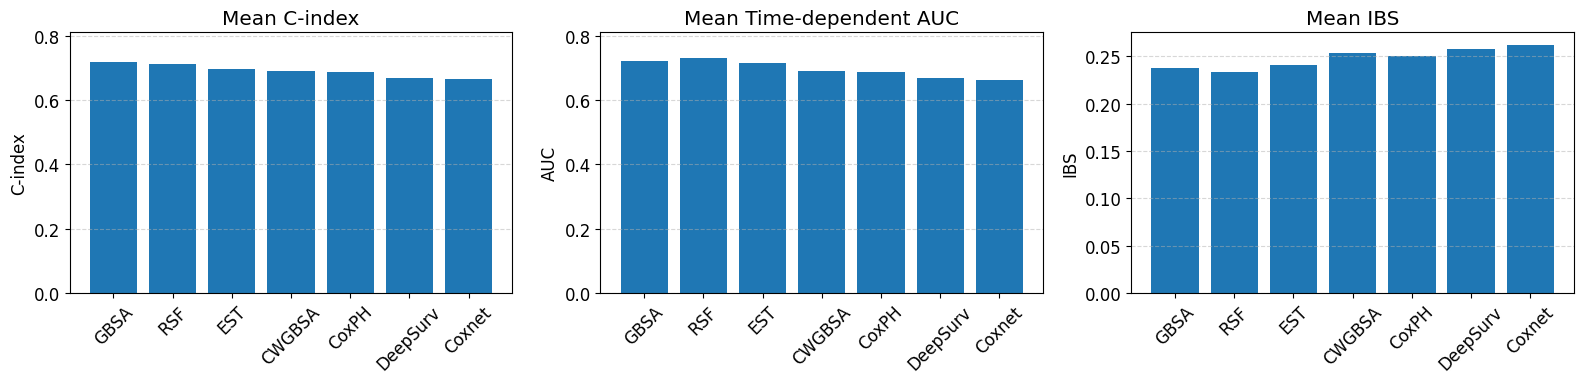

In [141]:
results2 = cross_validate_survival_models_with_deepsurv(
    df=n_df_train,
    feature_list=clinic,
duration_col='Timehyperpigmentation1',
    event_col='Eventhyperpigmentation1',
    event_type= 'First',
    time_unit="Months",
    n_splits=10,
    n_time_points=100,
    plot=True,
    verbose=True,
    deepsurv_epochs=100,
    deepsurv_patience=10,
)

In [ ]:
# dONT TAKE THIS AS IT DOES NOT CONTAIN THE SVM model
# Take the table from below as it contain SVM
#results2["summary_table"]

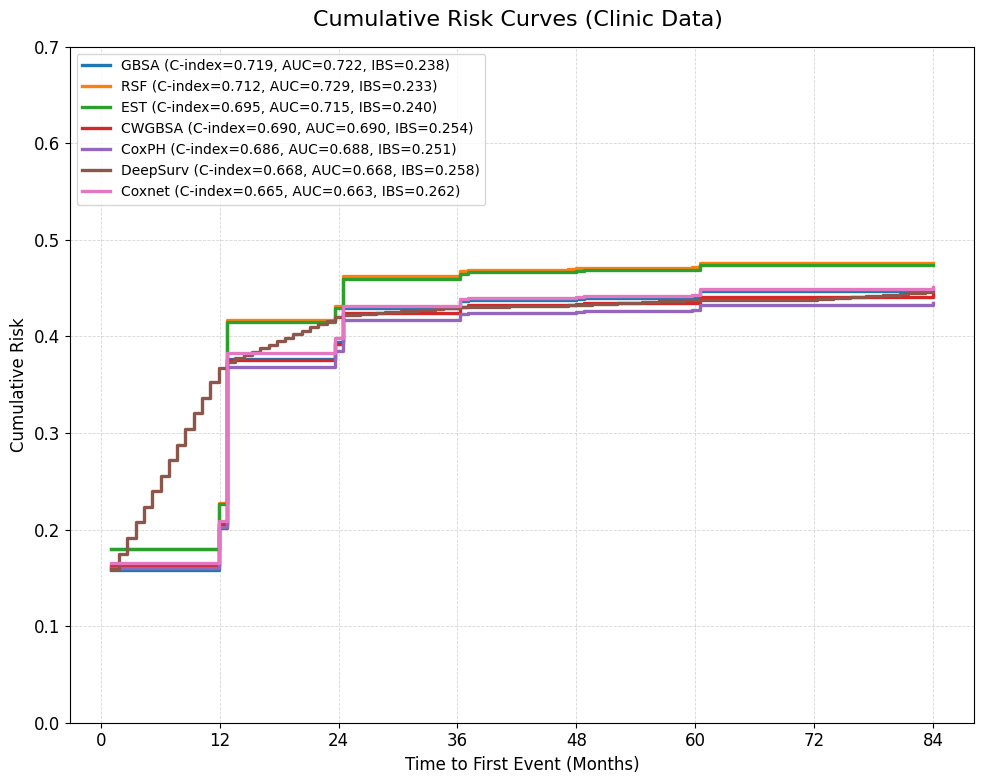

In [142]:
plot_cumulative_risk_curves_combined(
    stored_predictions=results2["predictions"],
    summary_table=results2["summary_table"],
    n_time_points=100,
    event_type="First",
    time_unit="Months",
    y_limits=(0, 0.70), # Using y_limits instead of y_max, for a range from 0 to 1
    s= '(Clinic Data)')

Data shape before preprocessing: (1544, 22)
Encoded 0 categorical columns:
[]
Data shape after encoding and cleaning: (1529, 22)

===== Fold 1 =====
RSF: C-index=0.681, mean AUC=0.690, IBS=0.228
CoxPH: C-index=0.694, mean AUC=0.712, IBS=0.226
Coxnet: C-index=0.652, mean AUC=0.661, IBS=0.255
GBSA: C-index=0.702, mean AUC=0.722, IBS=0.227
CWGBSA: C-index=0.687, mean AUC=0.708, IBS=0.241
EST: C-index=0.692, mean AUC=0.697, IBS=0.227
DeepSurv: C-index=0.638, mean AUC=0.663, IBS=0.250

===== Fold 2 =====
RSF: C-index=0.646, mean AUC=0.647, IBS=0.215
CoxPH: C-index=0.665, mean AUC=0.695, IBS=0.213
Coxnet: C-index=0.620, mean AUC=0.646, IBS=0.233
GBSA: C-index=0.684, mean AUC=0.703, IBS=0.212
CWGBSA: C-index=0.660, mean AUC=0.685, IBS=0.223
EST: C-index=0.656, mean AUC=0.661, IBS=0.213
DeepSurv: C-index=0.632, mean AUC=0.651, IBS=0.226

===== Fold 3 =====
RSF: C-index=0.629, mean AUC=0.593, IBS=0.291
CoxPH: C-index=0.616, mean AUC=0.543, IBS=0.318
Coxnet: C-index=0.589, mean AUC=0.529, IBS=0.

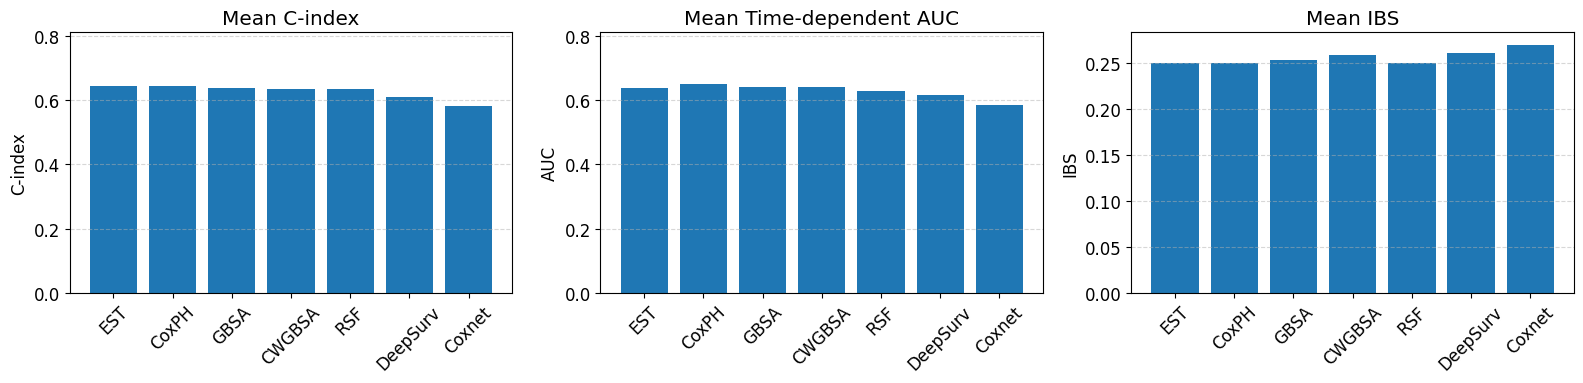

In [139]:
results2 = cross_validate_survival_models_with_deepsurv(
    df=n_df_train,
    feature_list=snp,
    duration_col='Timehyperpigmentation1',
    event_col='Eventhyperpigmentation1', event_type= 'First',
    time_unit="Months",
    n_splits=10,
    n_time_points=100,
    plot=True,
    verbose=True,
    deepsurv_epochs=100,
    deepsurv_patience=10,
)

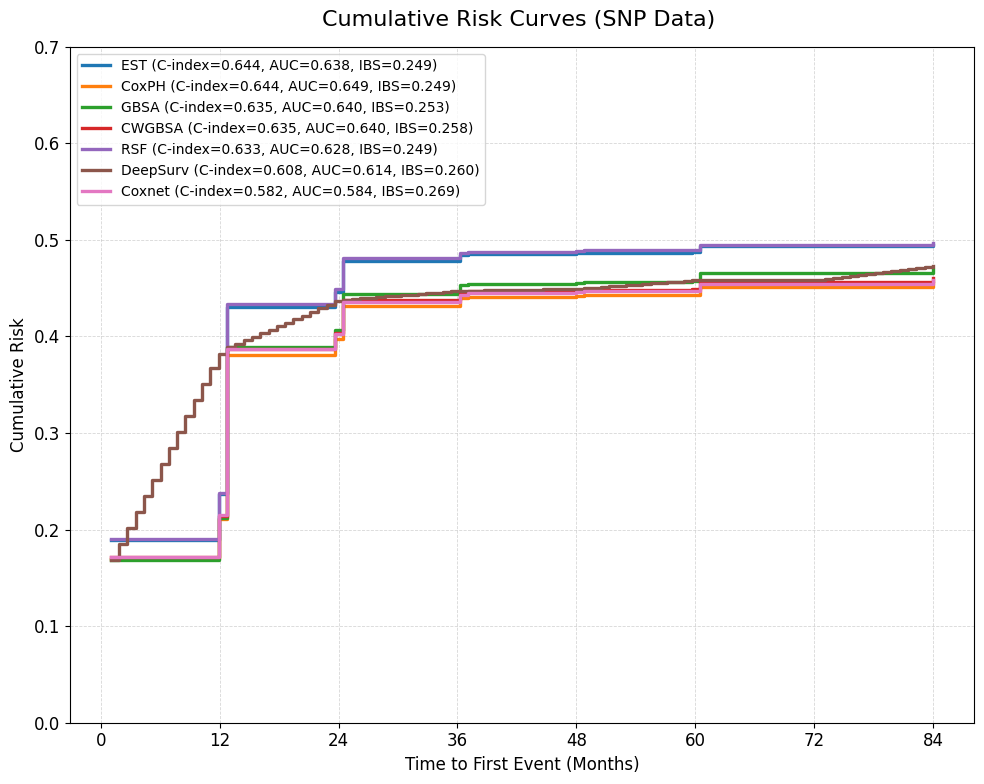

In [140]:
plot_cumulative_risk_curves_combined(
    stored_predictions=results2["predictions"],
    summary_table=results2["summary_table"],
    n_time_points=100,
    event_type="First",
    time_unit="Months",
    y_limits=(0, 0.70), # Using y_limits instead of y_max, for a range from 0 to 1
    s= '(SNP Data)')

Data shape before preprocessing: (1544, 22)
Encoded 0 categorical columns:
[]
Data shape after encoding and cleaning: (1448, 22)

===== Fold 1 =====
RSF: C-index=0.750, mean AUC=0.768, IBS=0.235
CoxPH: C-index=0.717, mean AUC=0.722, IBS=0.241
Coxnet: C-index=0.743, mean AUC=0.751, IBS=0.274
GBSA: C-index=0.749, mean AUC=0.755, IBS=0.230
CWGBSA: C-index=0.715, mean AUC=0.718, IBS=0.262
EST: C-index=0.765, mean AUC=0.790, IBS=0.229
DeepSurv: C-index=0.733, mean AUC=0.737, IBS=0.270

===== Fold 2 =====
RSF: C-index=0.723, mean AUC=0.742, IBS=0.201
CoxPH: C-index=0.695, mean AUC=0.723, IBS=0.217
Coxnet: C-index=0.594, mean AUC=0.595, IBS=0.244
GBSA: C-index=0.708, mean AUC=0.729, IBS=0.213
CWGBSA: C-index=0.646, mean AUC=0.655, IBS=0.236
EST: C-index=0.722, mean AUC=0.734, IBS=0.205
DeepSurv: C-index=0.681, mean AUC=0.708, IBS=0.228

===== Fold 3 =====
RSF: C-index=0.760, mean AUC=0.779, IBS=0.184
CoxPH: C-index=0.761, mean AUC=0.771, IBS=0.199
Coxnet: C-index=0.706, mean AUC=0.702, IBS=0.

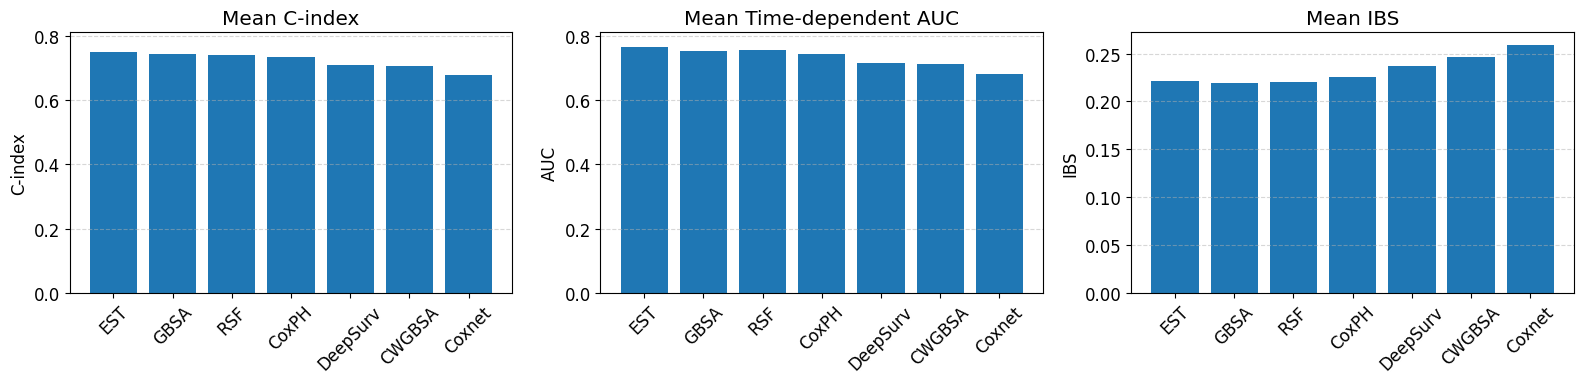

In [127]:
results2 = cross_validate_survival_models_with_deepsurv(
    df=n_df_train,
    feature_list=combined,
duration_col='Timehyperpigmentation1',
    event_col='Eventhyperpigmentation1',
    event_type= 'First',
    time_unit="Months",
    n_splits=10,
    n_time_points=100,
    plot=True,
    verbose=True,
    deepsurv_epochs=100,
    deepsurv_patience=10,
)

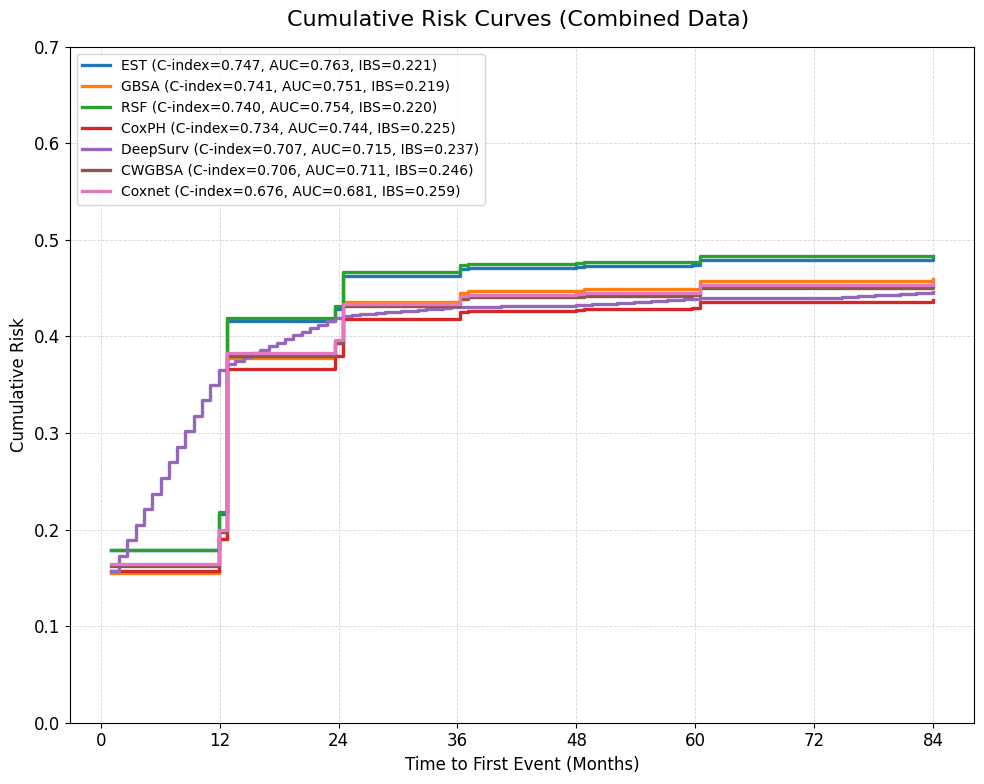

In [138]:
plot_cumulative_risk_curves_combined(
    stored_predictions=results2["predictions"],
    summary_table=results2["summary_table"],
    n_time_points=100,
    event_type="First",
    time_unit="Months",
    y_limits=(0, 0.70), # Using y_limits instead of y_max, for a range from 0 to 1
    s= '(Combined Data)')

In [129]:
# ALL model including SVM and DL

def cross_validate_survival_models_with_deepsurv2(
    df,
    feature_list,
    duration_col="Time1",
    event_col="Event1",
    event_type="First",
    time_unit="Months",
    n_splits=10,
    n_time_points=100,
    random_state=42,
    eval_times=None,
    min_eval_time=None,
    max_eval_time=None,
    plot=True,
    verbose=True,
    deepsurv_epochs=100,
    deepsurv_patience=10,):


    # ========================================================
    # 1) DATA PREPARATION
    # ========================================================

    required_cols = [
        duration_col,
        event_col
    ] + list(feature_list)

    df_model = df[required_cols].copy()

    if verbose:
        print(
            "Data shape before preprocessing:",
            df_model.shape
        )

    df_model = encode_dataset(
        df_model,
        duration_col=duration_col,
        event_col=event_col
    )

    df_model = df_model.dropna().copy()

    if verbose:
        print(
            "Data shape after encoding and cleaning:",
            df_model.shape
        )

    if len(df_model) == 0:
        raise ValueError(
            "No complete cases remain after preprocessing."
        )

    X = df_model[feature_list].astype(float)

    scaler = StandardScaler()

    X = scaler.fit_transform(X)

    X = pd.DataFrame(
        X,
        columns=feature_list
    )

    y = Surv.from_dataframe(
        event_col,
        duration_col,
        df_model
    )

    event_indicator = (
        df_model[event_col]
        .astype(int)
        .values
    )


    # ========================================================
    # 2) CLASSICAL / ML MODELS
    # ========================================================

    classical_models = {

        # ----------------------------------------------------
        # SVM
        # ----------------------------------------------------
        "SVM": FastSurvivalSVM(
            alpha=1.0,
            rank_ratio=1.0,
            max_iter=1000,
            random_state=random_state
        ),

        # ----------------------------------------------------
        # Random Survival Forest
        # ----------------------------------------------------
        "RSF": RandomSurvivalForest(
            n_estimators=300,
            max_depth=None,
            min_samples_split=10,
            min_samples_leaf=5,
            max_features="sqrt",
            n_jobs=-1,
            random_state=12,
        ),

        # ----------------------------------------------------
        # Cox PH
        # ----------------------------------------------------
        "CoxPH": CoxPHSurvivalAnalysis(),

        # ----------------------------------------------------
        # Coxnet
        # ----------------------------------------------------
        "Coxnet": CoxnetSurvivalAnalysis(
            l1_ratio=0.5,
            alpha_min_ratio=0.01,
            fit_baseline_model=True,
        ),

        # ----------------------------------------------------
        # Gradient Boosting Survival Analysis
        # ----------------------------------------------------
        "GBSA": GradientBoostingSurvivalAnalysis(
            loss="coxph",
            learning_rate=0.05,
            n_estimators=200,
            max_depth=3,
            random_state=12,
        ),

        # ----------------------------------------------------
        # Componentwise GBSA
        # ----------------------------------------------------
        "CWGBSA": ComponentwiseGradientBoostingSurvivalAnalysis(
            loss="coxph",
            learning_rate=0.03,
            n_estimators=300,
            subsample=0.7,
            random_state=12
        ),

        # ----------------------------------------------------
        # Extra Survival Trees
        # ----------------------------------------------------
        "EST": ExtraSurvivalTrees(
            n_estimators=300,
            max_depth=None,
            min_samples_split=10,
            min_samples_leaf=5,
            max_features="sqrt",
            n_jobs=-1,
            random_state=12,
        ),
    }


    all_model_names = (
        list(classical_models.keys())
        + ["DeepSurv"]
    )


    # ========================================================
    # 3) CROSS-VALIDATION
    # ========================================================

    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )


    # ========================================================
    # 4) STORAGE
    # ========================================================

    fold_rows = []

    stored_predictions = {

        model_name: {

            "fold_survival": [],

            "fold_risk": [],

            "fold_auc": [],

            "fold_times": [],

        }

        for model_name in all_model_names
    }


    # ========================================================
    # 5) CV LOOP
    # ========================================================

    for fold, (
        train_idx,
        test_idx
    ) in enumerate(
        cv.split(X, event_indicator),
        start=1
    ):

        if verbose:
            print(
                f"\n===== Fold {fold} ====="
            )


        X_train_df = X.iloc[train_idx]
        X_test_df = X.iloc[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]


        # ====================================================
        # Evaluation time range
        # ====================================================

        train_event_times = (
            y_train[duration_col]
            .astype(float)
        )

        test_event_times = (
            y_test[duration_col]
            .astype(float)
        )


        lower_bound = float(
            np.min(test_event_times)
        )

        upper_bound = float(
            np.nextafter(
                min(
                    np.max(test_event_times),
                    np.max(train_event_times)
                ),
                -np.inf
            )
        )


        if min_eval_time is not None:

            lower_bound = max(
                lower_bound,
                float(min_eval_time)
            )


        if max_eval_time is not None:

            upper_bound = min(
                upper_bound,
                float(max_eval_time)
            )


        if eval_times is None:

            if lower_bound >= upper_bound:

                lower_bound = float(
                    np.percentile(
                        train_event_times,
                        10
                    )
                )

                upper_bound = float(
                    np.nextafter(
                        np.percentile(
                            train_event_times,
                            90
                        ),
                        -np.inf
                    )
                )

            times = np.linspace(
                lower_bound,
                upper_bound,
                n_time_points
            )

        else:

            times = np.asarray(
                eval_times,
                dtype=float
            )

            times = times[
                (times >= lower_bound)
                &
                (times <= upper_bound)
            ]


        if times.size < 2:

            raise ValueError(
                f"Fold {fold}: "
                "evaluation time grid too small."
            )


        # ====================================================
        # 5A) CLASSICAL MODELS
        # ====================================================

        for model_name, base_model in classical_models.items():

            model = clone(base_model)

            try:

                # ------------------------------------------------
                # Fit
                # ------------------------------------------------

                model.fit(
                    X_train_df,
                    y_train
                )


                # =================================================
                # SPECIAL CASE: SVM
                # =================================================

                if model_name == "SVM":

                    # FastSurvivalSVM returns a risk score
                    # directly using predict().
                    #
                    # Higher risk score = higher predicted risk.

                    scalar_risk = model.predict(
                        X_test_df
                    )


                    # ---------------------------------------------
                    # C-index
                    # ---------------------------------------------

                    c_index = concordance_index_censored(
                        y_test[event_col],
                        y_test[duration_col],
                        scalar_risk
                    )[0]


                    # ------------------------------------------------
                    # SVM does NOT have:
                    #
                    # predict_survival_function()
                    #
                    # Therefore AUC and IBS are not calculated.
                    # ------------------------------------------------

                    mean_auc = np.nan
                    ibs = np.nan


                    if verbose:

                        print(
                            f"{model_name}: "
                            f"C-index={c_index:.3f}, "
                            f"mean AUC=NA, "
                            f"IBS=NA"
                        )


                    # ------------------------------------------------
                    # Save only C-index-related result
                    # ------------------------------------------------

                    fold_rows.append({

                        "fold": fold,

                        "model": model_name,

                        "c_index": float(
                            c_index
                        ),

                        "mean_auc": np.nan,

                        "ibs": np.nan,

                    })


                    # Move to next model
                    continue


                # =================================================
                # ALL OTHER CLASSICAL MODELS
                # =================================================

                surv_fns = (
                    model
                    .predict_survival_function(
                        X_test_df
                    )
                )


                surv_probs = np.row_stack(
                    [
                        fn(times)
                        for fn in surv_fns
                    ]
                )


                surv_probs = np.clip(
                    surv_probs,
                    0.0,
                    1.0
                )


                # ------------------------------------------------
                # Risk at final evaluation time
                # ------------------------------------------------

                scalar_risk = (
                    1.0
                    - surv_probs[:, -1]
                )


                # ------------------------------------------------
                # Risk across evaluation times
                # ------------------------------------------------

                risk_matrix = (
                    1.0
                    - surv_probs
                )


                # =================================================
                # C-INDEX
                # =================================================

                c_index = concordance_index_censored(
                    y_test[event_col],
                    y_test[duration_col],
                    scalar_risk
                )[0]


                # =================================================
                # TIME-DEPENDENT AUC
                # =================================================

                auc_values, mean_auc = (
                    cumulative_dynamic_auc(
                        y_train,
                        y_test,
                        risk_matrix,
                        times
                    )
                )


                # =================================================
                # INTEGRATED BRIER SCORE
                # =================================================

                ibs = integrated_brier_score(
                    y_train,
                    y_test,
                    surv_probs,
                    times
                )


                # =================================================
                # STORE PREDICTIONS
                # =================================================

                stored_predictions[
                    model_name
                ][
                    "fold_survival"
                ].append(
                    surv_probs.mean(axis=0)
                )


                stored_predictions[
                    model_name
                ][
                    "fold_risk"
                ].append(
                    risk_matrix.mean(axis=0)
                )


                stored_predictions[
                    model_name
                ][
                    "fold_auc"
                ].append(
                    auc_values
                )


                stored_predictions[
                    model_name
                ][
                    "fold_times"
                ].append(
                    times
                )


                # =================================================
                # STORE METRICS
                # =================================================

                fold_rows.append({

                    "fold": fold,

                    "model": model_name,

                    "c_index": float(
                        c_index
                    ),

                    "mean_auc": float(
                        mean_auc
                    ),

                    "ibs": float(
                        ibs
                    ),

                })


                # =================================================
                # PRINT RESULTS
                # =================================================

                if verbose:

                    print(
                        f"{model_name}: "
                        f"C-index={c_index:.3f}, "
                        f"mean AUC={mean_auc:.3f}, "
                        f"IBS={ibs:.3f}"
                    )


            except Exception as e:

                fold_rows.append({

                    "fold": fold,

                    "model": model_name,

                    "c_index": np.nan,

                    "mean_auc": np.nan,

                    "ibs": np.nan,

                    "error": str(e),

                })


                if verbose:

                    print(
                        f"{model_name} "
                        f"failed on fold {fold}: {e}"
                    )


        # ========================================================
        # 5B) DEEPSURV
        # ========================================================

        try:

            # ----------------------------------------------------
            # Scale features for neural network
            # ----------------------------------------------------

            scaler = StandardScaler()

            X_train = scaler.fit_transform(
                X_train_df
            ).astype("float32")

            X_test = scaler.transform(
                X_test_df
            ).astype("float32")


            # ----------------------------------------------------
            # pycox target format
            # ----------------------------------------------------

            y_train_pycox = (

                df_model.iloc[
                    train_idx
                ][duration_col]
                .values
                .astype("float32"),

                df_model.iloc[
                    train_idx
                ][event_col]
                .values
                .astype("float32"),

            )


            # ----------------------------------------------------
            # Validation split
            # ----------------------------------------------------

            rng = np.random.default_rng(
                seed=random_state + fold
            )

            perm = rng.permutation(
                len(X_train)
            )

            val_size = max(
                1,
                int(0.15 * len(X_train))
            )

            val_idx = perm[:val_size]

            tr_idx = perm[val_size:]


            X_tr = X_train[tr_idx]

            X_val = X_train[val_idx]


            y_tr = (

                y_train_pycox[0][tr_idx],

                y_train_pycox[1][tr_idx]

            )


            y_val = (

                y_train_pycox[0][val_idx],

                y_train_pycox[1][val_idx]

            )


            # ----------------------------------------------------
            # Create DeepSurv
            # ----------------------------------------------------

            in_features = X_train.shape[1]

            deepsurv_model = make_deepsurv_model(

                in_features=in_features,

                lr=1e-3,

                num_nodes=[32, 32],

                dropout=0.1

            )


            callbacks = [

                tt.callbacks.EarlyStopping(
                    patience=deepsurv_patience
                )

            ]


            # ----------------------------------------------------
            # Train
            # ----------------------------------------------------

            _ = deepsurv_model.fit(

                X_tr,

                y_tr,

                batch_size=256,

                epochs=deepsurv_epochs,

                callbacks=callbacks,

                verbose=False,

                val_data=(
                    X_val,
                    y_val
                )

            )


            # ----------------------------------------------------
            # Baseline hazards
            # ----------------------------------------------------

            deepsurv_model.compute_baseline_hazards()


            # ----------------------------------------------------
            # Survival predictions
            # ----------------------------------------------------

            surv_df = (
                deepsurv_model
                .predict_surv_df(
                    X_test
                )
            )


            # ----------------------------------------------------
            # Interpolate survival predictions
            # ----------------------------------------------------

            surv_probs = np.row_stack(

                [

                    np.interp(

                        times,

                        surv_df.index.values.astype(
                            float
                        ),

                        surv_df.iloc[
                            :, i
                        ].values.astype(
                            float
                        ),

                        left=1.0,

                        right=(
                            surv_df
                            .iloc[:, i]
                            .values.astype(
                                float
                            )[-1]
                        )

                    )

                    for i in range(
                        surv_df.shape[1]
                    )

                ]

            )


            surv_probs = np.clip(
                surv_probs,
                0.0,
                1.0
            )


            # ----------------------------------------------------
            # Risk
            # ----------------------------------------------------

            scalar_risk = (
                1.0
                - surv_probs[:, -1]
            )


            risk_matrix = (
                1.0
                - surv_probs
            )


            # =================================================
            # C-INDEX
            # =================================================

            c_index = concordance_index_censored(

                y_test[event_col],

                y_test[duration_col],

                scalar_risk

            )[0]


            # =================================================
            # AUC
            # =================================================

            auc_values, mean_auc = (
                cumulative_dynamic_auc(

                    y_train,

                    y_test,

                    risk_matrix,

                    times

                )
            )


            # =================================================
            # IBS
            # =================================================

            ibs = integrated_brier_score(

                y_train,

                y_test,

                surv_probs,

                times

            )


            # =================================================
            # STORE DEEPSURV RESULTS
            # =================================================

            stored_predictions[
                "DeepSurv"
            ][
                "fold_survival"
            ].append(
                surv_probs.mean(axis=0)
            )


            stored_predictions[
                "DeepSurv"
            ][
                "fold_risk"
            ].append(
                risk_matrix.mean(axis=0)
            )


            stored_predictions[
                "DeepSurv"
            ][
                "fold_auc"
            ].append(
                auc_values
            )


            stored_predictions[
                "DeepSurv"
            ][
                "fold_times"
            ].append(
                times
            )


            # =================================================
            # STORE DEEPSURV METRICS
            # =================================================

            fold_rows.append({

                "fold": fold,

                "model": "DeepSurv",

                "c_index": float(
                    c_index
                ),

                "mean_auc": float(
                    mean_auc
                ),

                "ibs": float(
                    ibs
                ),

            })


            if verbose:

                print(

                    f"DeepSurv: "

                    f"C-index={c_index:.3f}, "

                    f"mean AUC={mean_auc:.3f}, "

                    f"IBS={ibs:.3f}"

                )


        except Exception as e:

            fold_rows.append({

                "fold": fold,

                "model": "DeepSurv",

                "c_index": np.nan,

                "mean_auc": np.nan,

                "ibs": np.nan,

                "error": str(e),

            })


            if verbose:

                print(
                    f"DeepSurv failed "
                    f"on fold {fold}: {e}"
                )


    # ========================================================
    # 6) FOLD METRICS TABLE
    # ========================================================

    fold_metrics = pd.DataFrame(
        fold_rows
    )


    # ========================================================
    # 7) SUMMARY TABLE
    # ========================================================

    summary_table = (

        fold_metrics

        .groupby(
            "model",
            dropna=False
        )

        .agg(

            mean_c_index=(
                "c_index",
                "mean"
            ),

            sd_c_index=(
                "c_index",
                "std"
            ),

            mean_auc=(
                "mean_auc",
                "mean"
            ),

            sd_auc=(
                "mean_auc",
                "std"
            ),

            mean_ibs=(
                "ibs",
                "mean"
            ),

            sd_ibs=(
                "ibs",
                "std"
            ),

            successful_folds=(
                "fold",
                "count"
            ),

        )

        .reset_index()

        .sort_values(

            by=[
                "mean_c_index",
                "mean_auc",
                "mean_ibs"
            ],

            ascending=[
                False,
                False,
                True
            ]

        )

    )


    # ========================================================
    # 8) C-INDEX PLOT ONLY
    # ========================================================

    if plot:

        # Sort models according to mean C-index
        plot_table = (
            summary_table
            .sort_values(
                "mean_c_index",
                ascending=False
            )
            .copy()
        )


        plt.figure(
            figsize=(8, 5)
        )


        bars = plt.bar(

            plot_table["model"],

            plot_table["mean_c_index"]

        )


        plt.title(
            "Mean C-index by Survival Model"
        )

        plt.ylabel(
            "C-index"
        )

        plt.xlabel(
            "Model"
        )


        plt.ylim(
            0,
            0.85
        )


        plt.xticks(

            rotation=45,

            ha="right"

        )


        plt.grid(

            True,

            axis="y",

            linestyle="--",

            alpha=0.5

        )


        # ----------------------------------------------------
        # Add C-index values above bars
        # ----------------------------------------------------

        for bar, value in zip(

            bars,

            plot_table["mean_c_index"]

        ):

            if pd.notna(value):

                plt.text(

                    bar.get_x()
                    + bar.get_width() / 2,

                    value + 0.01,

                    f"{value:.3f}",

                    ha="center",

                    va="bottom",

                    fontsize=10

                )


        plt.tight_layout()

        plt.show()


    # ========================================================
    # 9) RETURN RESULTS
    # ========================================================

    return {

        "summary_table": summary_table,

        "fold_metrics": fold_metrics,

        "predictions": stored_predictions,

    }


Data shape before preprocessing: (1544, 22)
Encoded 1 categorical columns:
['t_stage']
Data shape after encoding and cleaning: (1333, 22)

===== Fold 1 =====
SVM: C-index=0.636, mean AUC=NA, IBS=NA
RSF: C-index=0.688, mean AUC=0.711, IBS=0.168
CoxPH: C-index=0.642, mean AUC=0.633, IBS=0.204
Coxnet: C-index=0.688, mean AUC=0.678, IBS=0.218
GBSA: C-index=0.698, mean AUC=0.695, IBS=0.183
CWGBSA: C-index=0.668, mean AUC=0.660, IBS=0.201
EST: C-index=0.649, mean AUC=0.672, IBS=0.182
DeepSurv: C-index=0.677, mean AUC=0.665, IBS=0.201

===== Fold 2 =====
SVM: C-index=0.710, mean AUC=NA, IBS=NA
RSF: C-index=0.723, mean AUC=0.745, IBS=0.236
CoxPH: C-index=0.723, mean AUC=0.725, IBS=0.250
Coxnet: C-index=0.653, mean AUC=0.659, IBS=0.262
GBSA: C-index=0.739, mean AUC=0.749, IBS=0.234
CWGBSA: C-index=0.702, mean AUC=0.704, IBS=0.251
EST: C-index=0.727, mean AUC=0.725, IBS=0.235
DeepSurv: C-index=0.722, mean AUC=0.715, IBS=0.261

===== Fold 3 =====
SVM: C-index=0.696, mean AUC=NA, IBS=NA
RSF: C-ind

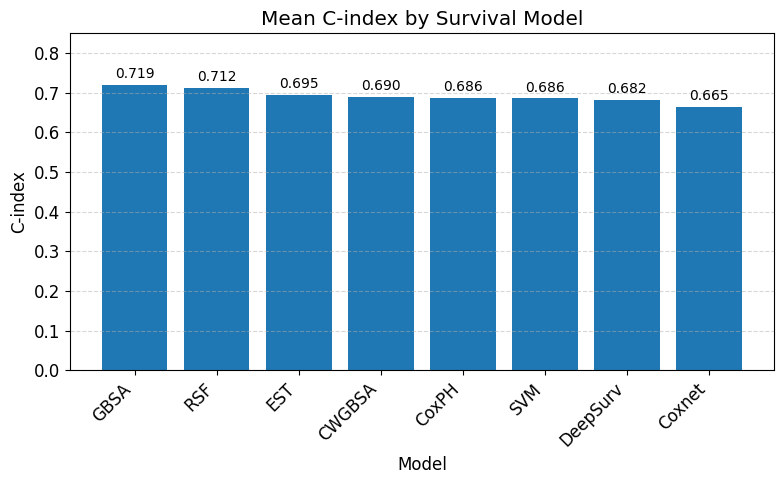

In [134]:
# take the table from here if you want and shape include the c index with SVM
results22 = cross_validate_survival_models_with_deepsurv2(df=n_df_train,
    feature_list=clinic,
    duration_col='Timehyperpigmentation1', event_col='Eventhyperpigmentation1', event_type= 'First',
    time_unit="Months", n_splits=10, n_time_points=100, plot=True, verbose=True,
    deepsurv_epochs=100, deepsurv_patience=10,)

In [135]:
results22["summary_table"]

,model,mean_c_index,sd_c_index,mean_auc,sd_auc,mean_ibs,sd_ibs,successful_folds
5,GBSA,0.719096,0.014347,0.721784,0.028104,0.237847,0.026312,10
6,RSF,0.711721,0.021807,0.729478,0.017463,0.233376,0.028706,10
4,EST,0.695077,0.028129,0.715222,0.021676,0.240401,0.028587,10
0,CWGBSA,0.689636,0.024178,0.689800,0.024309,0.253612,0.024303,10
1,CoxPH,0.686065,0.031511,0.687812,0.036414,0.250571,0.020449,10
7,SVM,0.685636,0.026994,NaN,NaN,NaN,NaN,10
3,DeepSurv,0.682152,0.028340,0.681311,0.029868,0.258756,0.024022,10
2,Coxnet,0.665062,0.042566,0.663061,0.049331,0.262115,0.019718,10


Data shape before preprocessing: (1544, 22)
Encoded 0 categorical columns:
[]
Data shape after encoding and cleaning: (1448, 22)

===== Fold 1 =====
SVM: C-index=0.720, mean AUC=NA, IBS=NA
RSF: C-index=0.750, mean AUC=0.768, IBS=0.235
CoxPH: C-index=0.717, mean AUC=0.722, IBS=0.241
Coxnet: C-index=0.743, mean AUC=0.751, IBS=0.274
GBSA: C-index=0.749, mean AUC=0.755, IBS=0.230
CWGBSA: C-index=0.715, mean AUC=0.718, IBS=0.262
EST: C-index=0.765, mean AUC=0.790, IBS=0.229
DeepSurv: C-index=0.743, mean AUC=0.757, IBS=0.231

===== Fold 2 =====
SVM: C-index=0.685, mean AUC=NA, IBS=NA
RSF: C-index=0.723, mean AUC=0.742, IBS=0.201
CoxPH: C-index=0.695, mean AUC=0.723, IBS=0.217
Coxnet: C-index=0.594, mean AUC=0.595, IBS=0.244
GBSA: C-index=0.708, mean AUC=0.729, IBS=0.213
CWGBSA: C-index=0.646, mean AUC=0.655, IBS=0.236
EST: C-index=0.722, mean AUC=0.734, IBS=0.205
DeepSurv: C-index=0.668, mean AUC=0.701, IBS=0.229

===== Fold 3 =====
SVM: C-index=0.773, mean AUC=NA, IBS=NA
RSF: C-index=0.760,

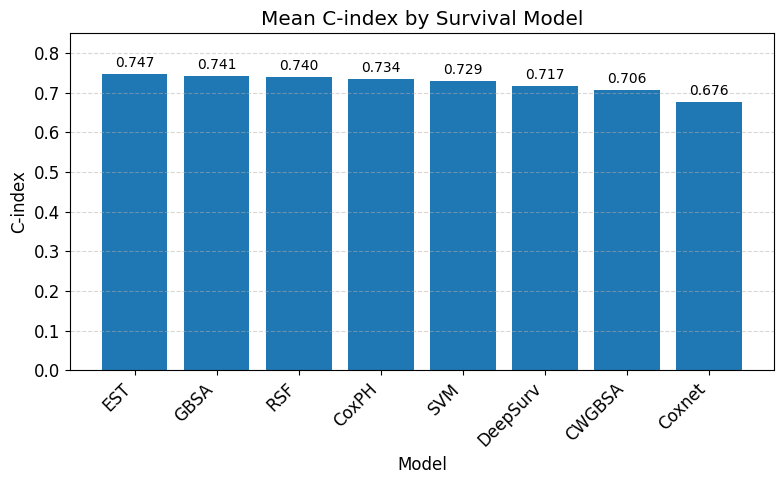

In [130]:
# take the table from here if you want and shape include the c index with SVM
results22 = cross_validate_survival_models_with_deepsurv2(df=n_df_train,
    feature_list=combined,
    duration_col='Timehyperpigmentation1', event_col='Eventhyperpigmentation1', event_type= 'First',
    time_unit="Months", n_splits=10, n_time_points=100, plot=True, verbose=True,
    deepsurv_epochs=100, deepsurv_patience=10,)

In [131]:
results22["summary_table"]

,model,mean_c_index,sd_c_index,mean_auc,sd_auc,mean_ibs,sd_ibs,successful_folds
4,EST,0.747456,0.028065,0.763062,0.034360,0.221469,0.023444,10
5,GBSA,0.741326,0.037271,0.751442,0.038692,0.218987,0.016139,10
6,RSF,0.740471,0.031859,0.753617,0.035901,0.220132,0.022786,10
1,CoxPH,0.734203,0.038594,0.744004,0.038352,0.225403,0.021245,10
7,SVM,0.729469,0.043812,NaN,NaN,NaN,NaN,10
3,DeepSurv,0.717459,0.040715,0.725812,0.042401,0.231078,0.025989,10
0,CWGBSA,0.705944,0.041814,0.710603,0.043672,0.246214,0.017424,10
2,Coxnet,0.675979,0.053840,0.680812,0.053411,0.259217,0.013761,10


Data shape before preprocessing: (1544, 22)
Encoded 0 categorical columns:
[]
Data shape after encoding and cleaning: (1529, 22)

===== Fold 1 =====
SVM: C-index=0.686, mean AUC=NA, IBS=NA
RSF: C-index=0.681, mean AUC=0.690, IBS=0.228
CoxPH: C-index=0.694, mean AUC=0.712, IBS=0.226
Coxnet: C-index=0.652, mean AUC=0.661, IBS=0.255
GBSA: C-index=0.702, mean AUC=0.722, IBS=0.227
CWGBSA: C-index=0.687, mean AUC=0.708, IBS=0.241
EST: C-index=0.692, mean AUC=0.697, IBS=0.227
DeepSurv: C-index=0.673, mean AUC=0.699, IBS=0.244

===== Fold 2 =====
SVM: C-index=0.661, mean AUC=NA, IBS=NA
RSF: C-index=0.646, mean AUC=0.647, IBS=0.215
CoxPH: C-index=0.665, mean AUC=0.695, IBS=0.213
Coxnet: C-index=0.620, mean AUC=0.646, IBS=0.233
GBSA: C-index=0.684, mean AUC=0.703, IBS=0.212
CWGBSA: C-index=0.660, mean AUC=0.685, IBS=0.223
EST: C-index=0.656, mean AUC=0.661, IBS=0.213
DeepSurv: C-index=0.587, mean AUC=0.604, IBS=0.225

===== Fold 3 =====
SVM: C-index=0.611, mean AUC=NA, IBS=NA
RSF: C-index=0.629,

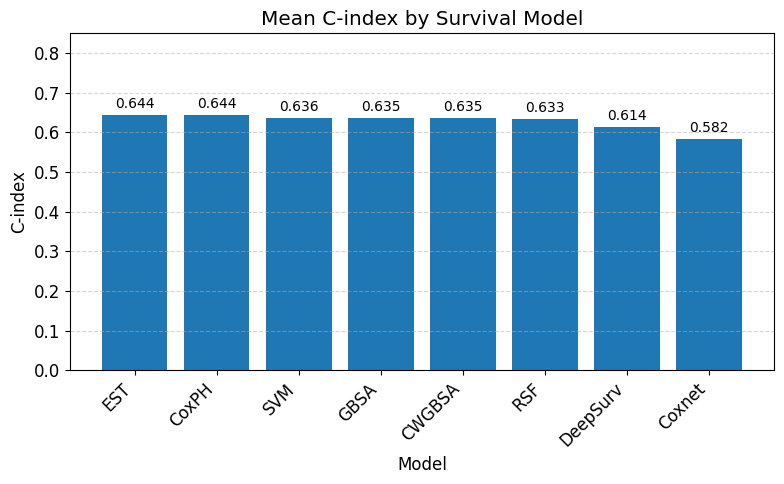

In [132]:
# take the table from here if you want and shape include the c index with SVM
results22 = cross_validate_survival_models_with_deepsurv2(df=n_df_train,
    feature_list=snp,
    duration_col='Timehyperpigmentation1', event_col='Eventhyperpigmentation1', event_type= 'First',
    time_unit="Months", n_splits=10, n_time_points=100, plot=True, verbose=True,
    deepsurv_epochs=100, deepsurv_patience=10,)

In [133]:
results22["summary_table"]

,model,mean_c_index,sd_c_index,mean_auc,sd_auc,mean_ibs,sd_ibs,successful_folds
4,EST,0.643976,0.050664,0.638246,0.060484,0.249219,0.032995,10
1,CoxPH,0.643927,0.051657,0.648770,0.068703,0.249333,0.036904,10
7,SVM,0.635946,0.053248,NaN,NaN,NaN,NaN,10
5,GBSA,0.635462,0.049554,0.639546,0.057828,0.252618,0.034210,10
0,CWGBSA,0.635348,0.045660,0.639710,0.063814,0.257810,0.028335,10
6,RSF,0.632984,0.048875,0.628280,0.051045,0.249062,0.030582,10
3,DeepSurv,0.614171,0.043962,0.615903,0.055637,0.261942,0.041079,10
2,Coxnet,0.582427,0.045516,0.584216,0.057798,0.269430,0.028502,10


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_cumulative_risk_curves_v2(
    stored_predictions,
    summary_table,
    n_time_points=200,
    event_type="First",
    time_unit="Months",
    y_limits=None,   # e.g. (0.25, 0.85)
    ):
    for model_name, pred in stored_predictions.items():
        if len(pred["fold_survival"]) == 0:
            continue

        common_min = max(np.min(t) for t in pred["fold_times"])
        common_max = min(np.max(t) for t in pred["fold_times"])

        if common_min >= common_max:
            continue

        plot_grid = np.linspace(common_min, common_max, n_time_points)

        fold_risks_interp = []
        for fold_times, fold_surv in zip(pred["fold_times"], pred["fold_survival"]):
            fold_risk = 1.0 - np.asarray(fold_surv)
            interp_risk = np.interp(plot_grid, fold_times, fold_risk)
            fold_risks_interp.append(interp_risk)

        fold_risks_interp = np.vstack(fold_risks_interp)

        mean_risk = fold_risks_interp.mean(axis=0)
        q25 = np.percentile(fold_risks_interp, 25, axis=0)
        q75 = np.percentile(fold_risks_interp, 75, axis=0)

        row = summary_table.loc[summary_table["model"] == model_name]
        if not row.empty:
            row = row.iloc[0]
            metric_text = (
                f"C-index = {row['mean_c_index']:.3f}    "
                f"AUC = {row['mean_auc']:.3f}    "
                f"IBS = {row['mean_ibs']:.3f}"
            )
        else:
            metric_text = ""

        plt.figure(figsize=(8.2, 5.2))

        # IQR band
        plt.fill_between(
            plot_grid,
            q25,
            q75,
            alpha=0.18,
            label="Interquartile range",
            zorder=1
        )

        # Mean step curve
        plt.step(
            plot_grid,
            mean_risk,
            where="post",
            color="black",
            linewidth=2.4,
            label="Mean cumulative risk",
            zorder=2
        )

        plt.title(f"\n{model_name}:Cumulative Risk Curve\n", fontsize=16, pad=12)

        # Put metrics inside figure rather than as cramped suptitle
        plt.text(
            0.5, 1.02,
            metric_text,
            transform=plt.gca().transAxes,
            ha="center",
            va="bottom",
            fontsize=11
        )

        plt.xlabel(f"Time to {event_type} Event ({time_unit})", fontsize=12)
        plt.ylabel("Cumulative Risk", fontsize=12)

        #plt.xlim(plot_grid.min(), plot_grid.max())
        plt.xticks(np.arange(0, 101, 12))

        if y_limits is not None:
            plt.ylim(*y_limits)
        else:
            plt.ylim(0, 1)

        x_max = int(np.ceil(plot_grid.max()))
        if x_max <= 24:
            step = 3
        elif x_max <= 60:
            step = 6
        else:
            step = 12

        plt.xticks(np.arange(0, x_max + 1, step))
        plt.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
        plt.legend(frameon=True, loc="upper right")
        plt.tight_layout()
        plt.show()

In [ ]:
# these results based on the
'''plot_cumulative_risk_curves_v2(stored_predictions=results2["predictions"],
    summary_table=results2["summary_table"],n_time_points=100, event_type="First",    time_unit="Months",   y_limits=(0, 1) # Using y_limits instead of y_max, for a range from 0 to 1
                               )
                               '''

##Validation SET

In [143]:
def Survival_Model_validation(
    n_df_train,
    n_df1_test,
    feature_list,
    duration_col,
    event_col,
    event_type,
    y_endpoint,
    y_ranges,
    color='tab:blue', s= 'clinic'
):
    print('train data shape (before encoding):', n_df_train.shape)
    print('test data shape (before encoding):', n_df1_test.shape)

    # Encode categorical features in both train and test dataframes
    n_df_train_encoded = encode_dataset(n_df_train.copy(), duration_col=duration_col, event_col=event_col)
    n_df1_test_encoded = encode_dataset(n_df1_test.copy(), duration_col=duration_col, event_col=event_col)

    # Keep only needed columns and drop NaNs
    all_cols_for_model = list(feature_list) + [duration_col, event_col]

    n_df_train_cleaned = n_df_train_encoded[all_cols_for_model].dropna()
    n_df1_test_cleaned = n_df1_test_encoded[all_cols_for_model].dropna()

    print('train data shape after cleaning:', n_df_train_cleaned.shape)
    print('test data shape after cleaning:', n_df1_test_cleaned.shape)

    # Build X and y from cleaned and encoded data
    X_train = n_df_train_cleaned[feature_list]
    y_train = Surv.from_dataframe(event_col, duration_col, n_df_train_cleaned)

    X_test = n_df1_test_cleaned[feature_list]
    y_test = Surv.from_dataframe(event_col, duration_col, n_df1_test_cleaned)

    y_test_events = y_test[event_col]
    y_test_times = y_test[duration_col]

    # -------------------------------------------------
    # Time Grid
    # -------------------------------------------------
    n_time_points = 100
    times = np.linspace(
        y_test_times.min(),
        np.nextafter(y_test_times.max(), -np.inf),
        n_time_points
    )

    # -------------------------------------------------
    # Models
    # -------------------------------------------------
    MLmodels = [

        RandomSurvivalForest(
            n_estimators=300,
            max_depth=3,
            min_samples_split=10,
            min_samples_leaf=5,
            max_features="sqrt",
            n_jobs=-1,
            random_state=12,
        ),
        CoxPHSurvivalAnalysis(),
        GradientBoostingSurvivalAnalysis(
            loss="coxph",
            learning_rate=0.05,
            n_estimators=200,
            max_depth=3,
            random_state=12,
        ),
        ComponentwiseGradientBoostingSurvivalAnalysis(
            loss="coxph", learning_rate=0.03,                                   n_estimators=300, subsample=0.7,                                        random_state=12),
        ExtraSurvivalTrees( n_estimators=300,max_depth=None,
            min_samples_split=10, min_samples_leaf=5, max_features="sqrt",
            n_jobs=-1, random_state=12,
        ),
    ]

    results = []

    # -------------------------------------------------
    # Loop Through Models
    # -------------------------------------------------
    for model in MLmodels:
        print(f"\nFitting model: {model.__class__.__name__}")
        model.fit(X_train, y_train)

        # Predict survival curves on external test set
        surv_funcs = model.predict_survival_function(X_test)
        survival_probs = np.row_stack([sf(times) for sf in surv_funcs])

        # -------------------------------------------------
        # Risk Score Extraction
        # -------------------------------------------------
        try:
            pred = model.predict(X_test)
            if isinstance(pred, np.ndarray) and pred.ndim == 1:
                risk_scores = pred
            else:
                risk_scores = None
        except Exception:
            risk_scores = None

        if risk_scores is None:
            try:
                chf_list = model.predict_cumulative_hazard_function(X_test)
                risk_scores = np.array([ch(times[-1]) for ch in chf_list])
            except Exception:
                risk_scores = 1 - survival_probs[:, -1]

        # -------------------------------------------------
        # Metrics
        # -------------------------------------------------
        c_index = concordance_index_censored(
            y_test_events,
            y_test_times,
            risk_scores
        )[0]

        brier_times, brier_scores = brier_score(
            y_train,
            y_test,
            survival_probs,
            times
        )

        avg_predicted_cumulative_risk = (1 - survival_probs[:, -1]).mean()

        # -------------------------------------------------
        # Plot Survival / Risk Curves
        # -------------------------------------------------
        plt.figure(figsize=(10, 6))
        plt.step(
            times,
            1 - survival_probs.mean(axis=0),
            where="post",
            color=color,
            linewidth=2,
            label=f"Mean cumulative risk (Validation test set)\nC-index={c_index:.2f}"
        )

        plt.ylabel("Cumulative Risk")
        plt.xlabel(f"Time to {event_type} {dep} Event")
        plt.title(f"Predicted {dep} Risk - {model.__class__.__name__} {s}")
        plt.xticks(np.arange(0, 100, 12))
        plt.yticks(np.arange(0, y_endpoint, y_ranges))
        plt.grid(True)
        plt.legend()
        plt.show()

        # Store results
        results.append({
            "model": model.__class__.__name__,
            "c_index": c_index,
            "avg_cum_risk_final": avg_predicted_cumulative_risk,
            "brier": (brier_times, brier_scores)
        })

    # -------------------------------------------------
    # Summary
    # -------------------------------------------------
    for r in results:
        print(f"\nModel: {r['model']}")
        print(f" C-Index: {r['c_index']:.4f}")
        print(f" Mean Cumulative Risk: {r['avg_cum_risk_final']:.4f}")

        times_out, scores_out = r['brier']
        check_times = [1, 12, 24, 36, 48, 60, 72, 84, 96]

        print(" Brier Score checkpoints:")
        for ct in check_times:
            idx = np.argmin(np.abs(times_out - ct))
            print(f"  t={times_out[idx]:.2f} → Brier={scores_out[idx]:.4f}")

train data shape (before encoding): (1544, 109)
test data shape (before encoding): (523, 109)
Encoded 4 categorical columns:
['subject_id', 't_stage', 'n_stage', 'CRFversion_baseline']
Encoded 4 categorical columns:
['subject_id', 't_stage', 'n_stage', 'CRFversion_baseline']
train data shape after cleaning: (1529, 22)
test data shape after cleaning: (388, 22)

Fitting model: RandomSurvivalForest


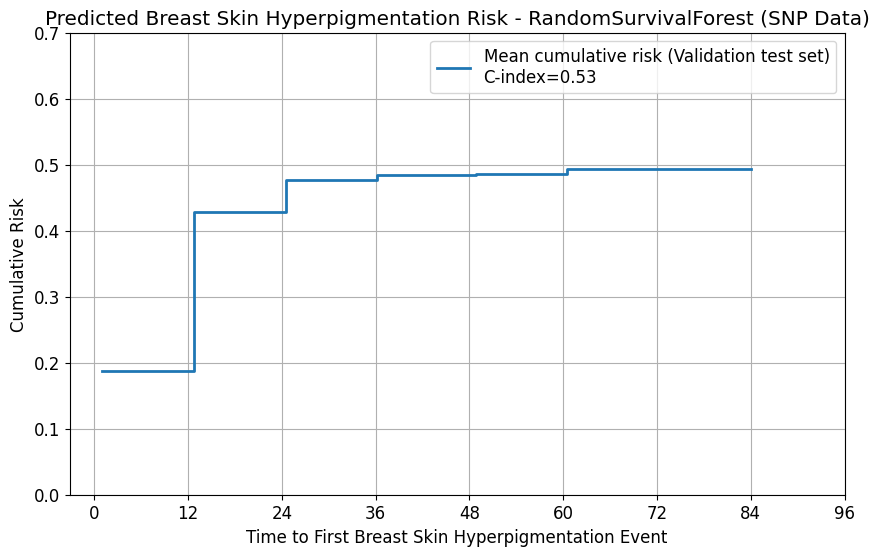


Fitting model: CoxPHSurvivalAnalysis


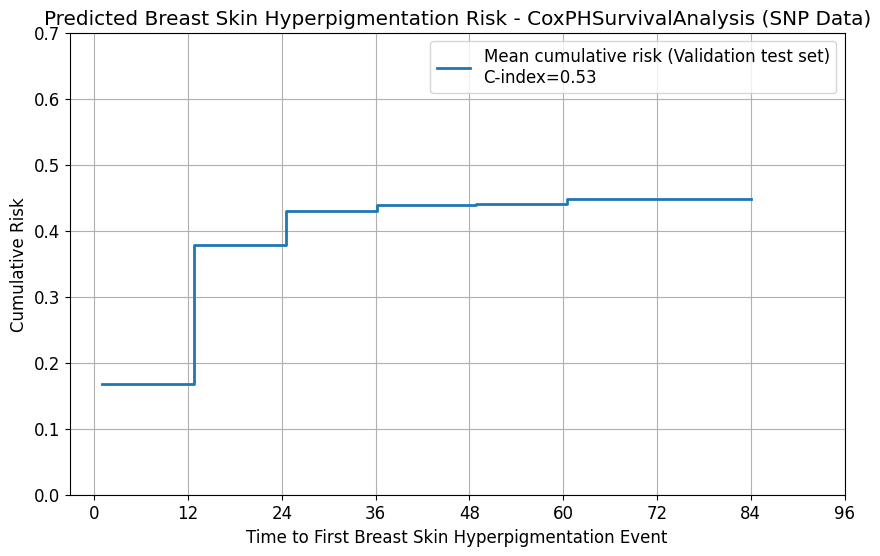


Fitting model: GradientBoostingSurvivalAnalysis


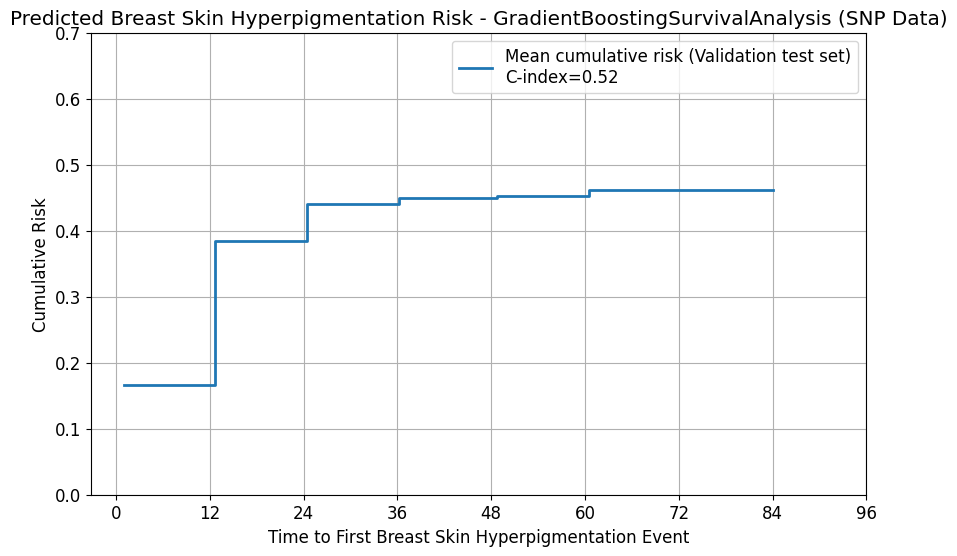


Fitting model: ComponentwiseGradientBoostingSurvivalAnalysis


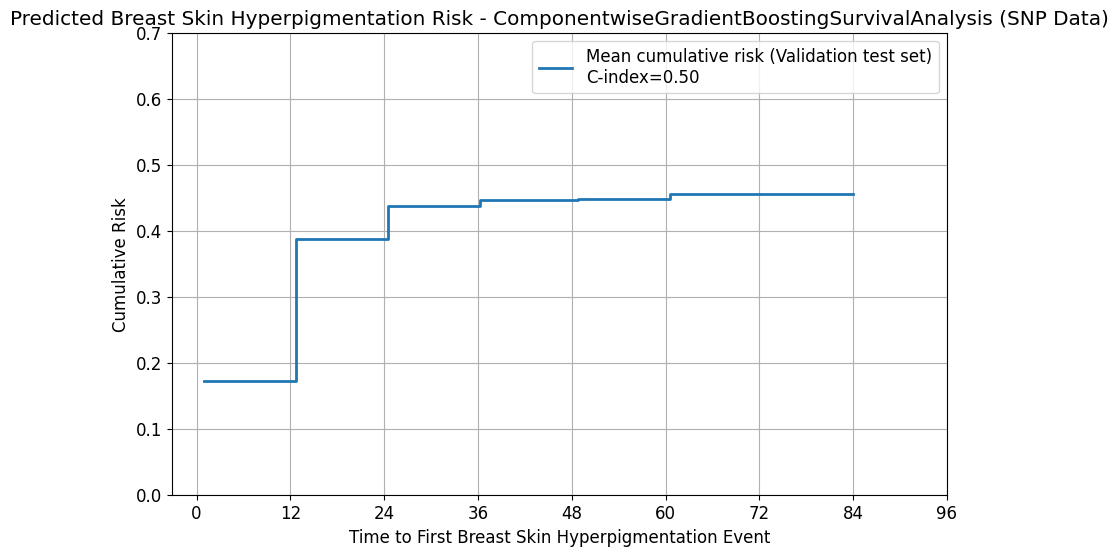


Fitting model: ExtraSurvivalTrees


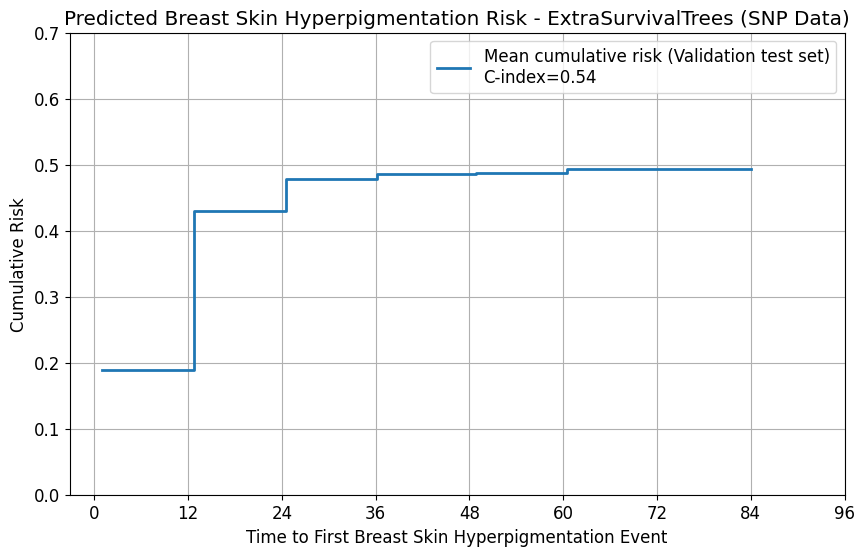


Model: RandomSurvivalForest
 C-Index: 0.5346
 Mean Cumulative Risk: 0.4941
 Brier Score checkpoints:
  t=1.00 → Brier=0.1667
  t=11.90 → Brier=0.1667
  t=23.64 → Brier=0.2553
  t=36.21 → Brier=0.2640
  t=47.95 → Brier=0.2640
  t=59.69 → Brier=0.2593
  t=72.26 → Brier=0.2380
  t=84.00 → Brier=0.2380
  t=84.00 → Brier=0.2380

Model: CoxPHSurvivalAnalysis
 C-Index: 0.5295
 Mean Cumulative Risk: 0.4486
 Brier Score checkpoints:
  t=1.00 → Brier=0.1732
  t=11.90 → Brier=0.1732
  t=23.64 → Brier=0.2643
  t=36.21 → Brier=0.2755
  t=47.95 → Brier=0.2755
  t=59.69 → Brier=0.2692
  t=72.26 → Brier=0.2531
  t=84.00 → Brier=0.2531
  t=84.00 → Brier=0.2531

Model: GradientBoostingSurvivalAnalysis
 C-Index: 0.5244
 Mean Cumulative Risk: 0.4613
 Brier Score checkpoints:
  t=1.00 → Brier=0.1707
  t=11.90 → Brier=0.1707
  t=23.64 → Brier=0.2649
  t=36.21 → Brier=0.2734
  t=47.95 → Brier=0.2734
  t=59.69 → Brier=0.2691
  t=72.26 → Brier=0.2547
  t=84.00 → Brier=0.2547
  t=84.00 → Brier=0.2547

Model: C

In [147]:
from sksurv.metrics import brier_score
Survival_Model_validation(n_df1_train, n_df1_test,
    snp, duration_col='Timehyperpigmentation1', event_col='Eventhyperpigmentation1', event_type= 'First',
    y_endpoint=0.75,
    y_ranges=0.1, color='tab:blue', s= '(SNP Data)')

train data shape (before encoding): (1544, 109)
test data shape (before encoding): (523, 109)
Encoded 4 categorical columns:
['subject_id', 't_stage', 'n_stage', 'CRFversion_baseline']
Encoded 4 categorical columns:
['subject_id', 't_stage', 'n_stage', 'CRFversion_baseline']
train data shape after cleaning: (1448, 22)
test data shape after cleaning: (369, 22)

Fitting model: RandomSurvivalForest


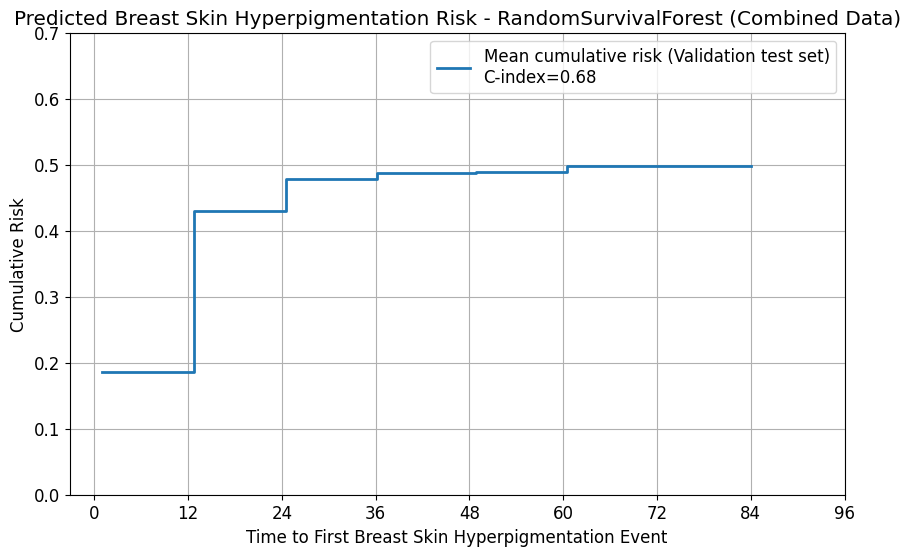


Fitting model: CoxPHSurvivalAnalysis


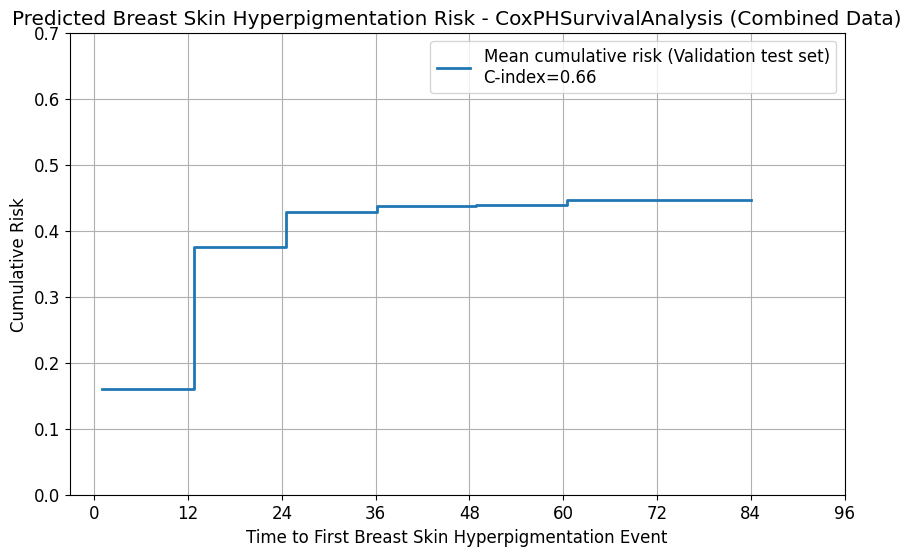


Fitting model: GradientBoostingSurvivalAnalysis


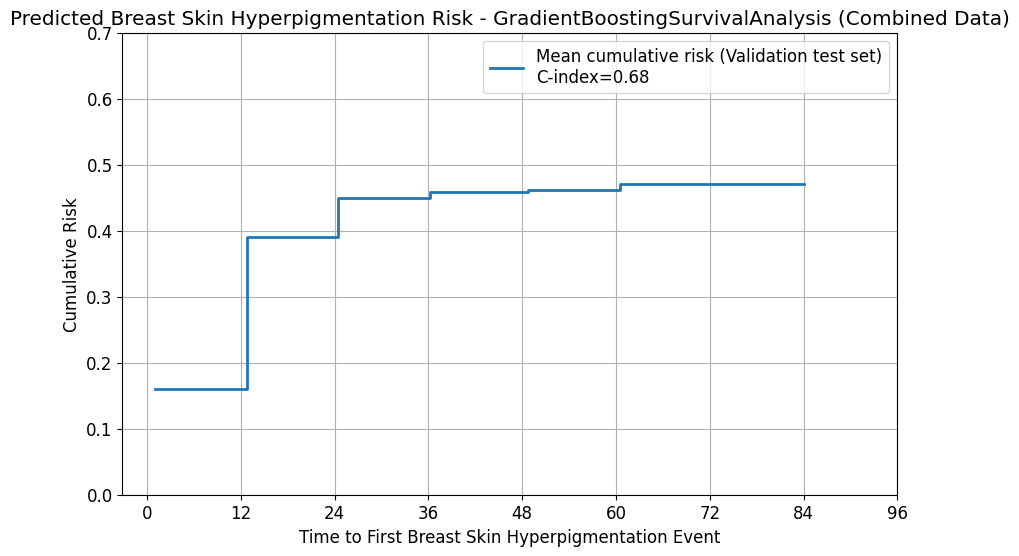


Fitting model: ComponentwiseGradientBoostingSurvivalAnalysis


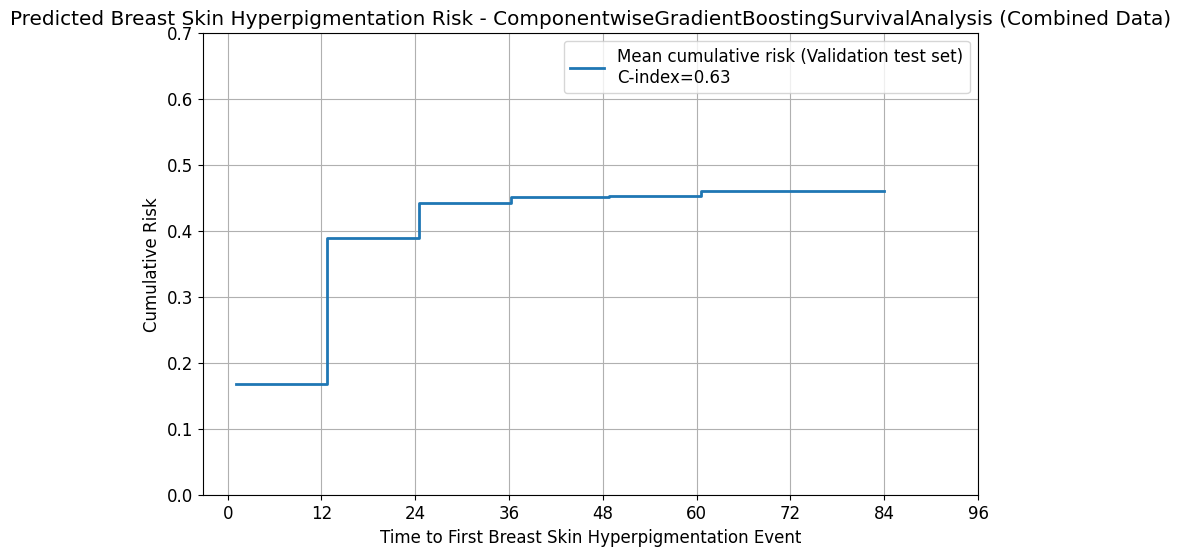


Fitting model: ExtraSurvivalTrees


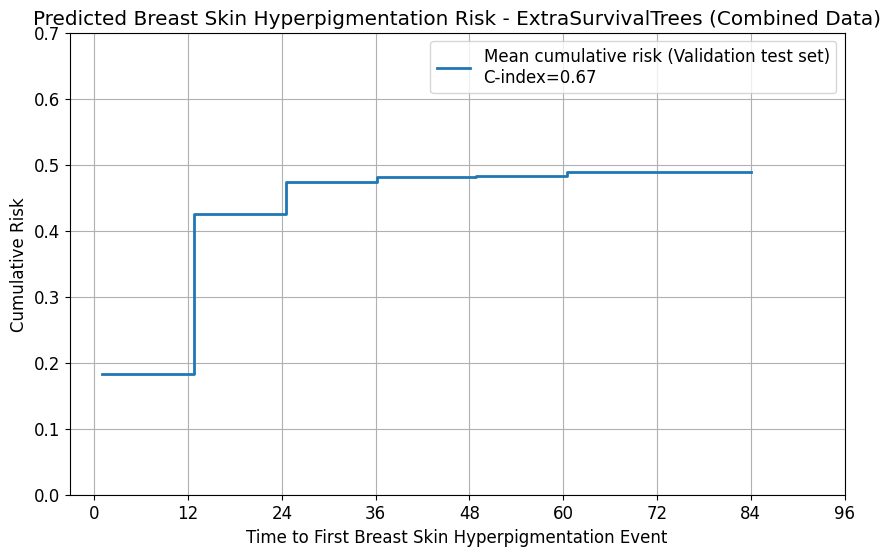


Model: RandomSurvivalForest
 C-Index: 0.6762
 Mean Cumulative Risk: 0.4973
 Brier Score checkpoints:
  t=1.00 → Brier=0.1482
  t=11.90 → Brier=0.1482
  t=23.64 → Brier=0.2317
  t=36.21 → Brier=0.2506
  t=47.95 → Brier=0.2506
  t=59.69 → Brier=0.2419
  t=72.26 → Brier=0.2400
  t=84.00 → Brier=0.2400
  t=84.00 → Brier=0.2400

Model: CoxPHSurvivalAnalysis
 C-Index: 0.6647
 Mean Cumulative Risk: 0.4468
 Brier Score checkpoints:
  t=1.00 → Brier=0.1550
  t=11.90 → Brier=0.1550
  t=23.64 → Brier=0.2417
  t=36.21 → Brier=0.2793
  t=47.95 → Brier=0.2793
  t=59.69 → Brier=0.2631
  t=72.26 → Brier=0.2650
  t=84.00 → Brier=0.2650
  t=84.00 → Brier=0.2650

Model: GradientBoostingSurvivalAnalysis
 C-Index: 0.6772
 Mean Cumulative Risk: 0.4706
 Brier Score checkpoints:
  t=1.00 → Brier=0.1484
  t=11.90 → Brier=0.1484
  t=23.64 → Brier=0.2339
  t=36.21 → Brier=0.2614
  t=47.95 → Brier=0.2614
  t=59.69 → Brier=0.2497
  t=72.26 → Brier=0.2613
  t=84.00 → Brier=0.2613
  t=84.00 → Brier=0.2613

Model: C

In [148]:
from sksurv.metrics import brier_score
Survival_Model_validation(n_df1_train, n_df1_test,
    combined, duration_col='Timehyperpigmentation1', event_col='Eventhyperpigmentation1', event_type= 'First',
    y_endpoint=0.75,
    y_ranges=0.1, color='tab:blue', s= '(Combined Data)')

train data shape (before encoding): (1544, 109)
test data shape (before encoding): (523, 109)
Encoded 4 categorical columns:
['subject_id', 't_stage', 'n_stage', 'CRFversion_baseline']
Encoded 4 categorical columns:
['subject_id', 't_stage', 'n_stage', 'CRFversion_baseline']
train data shape after cleaning: (1333, 22)
test data shape after cleaning: (440, 22)

Fitting model: RandomSurvivalForest


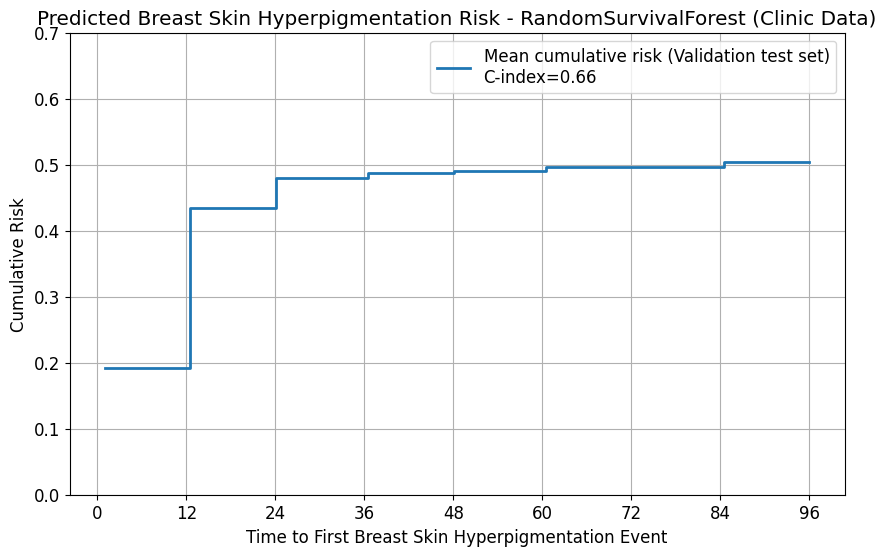


Fitting model: CoxPHSurvivalAnalysis


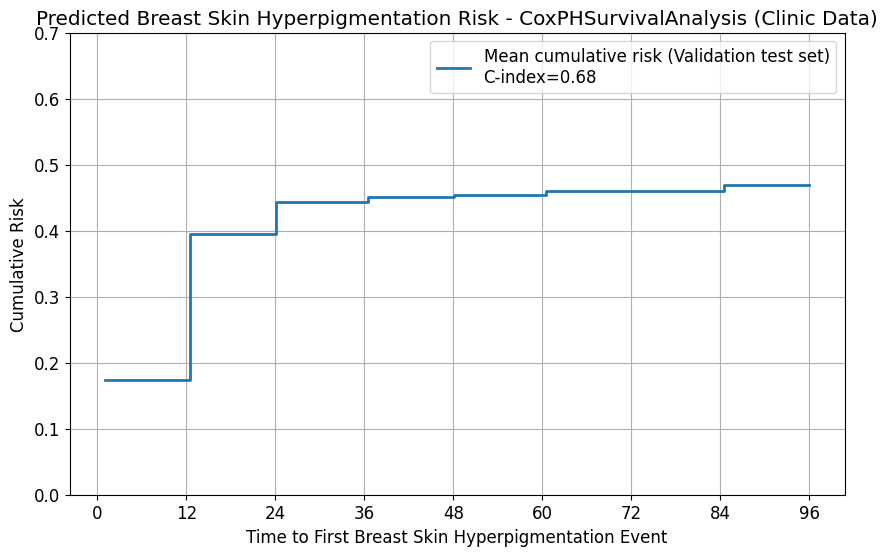


Fitting model: GradientBoostingSurvivalAnalysis


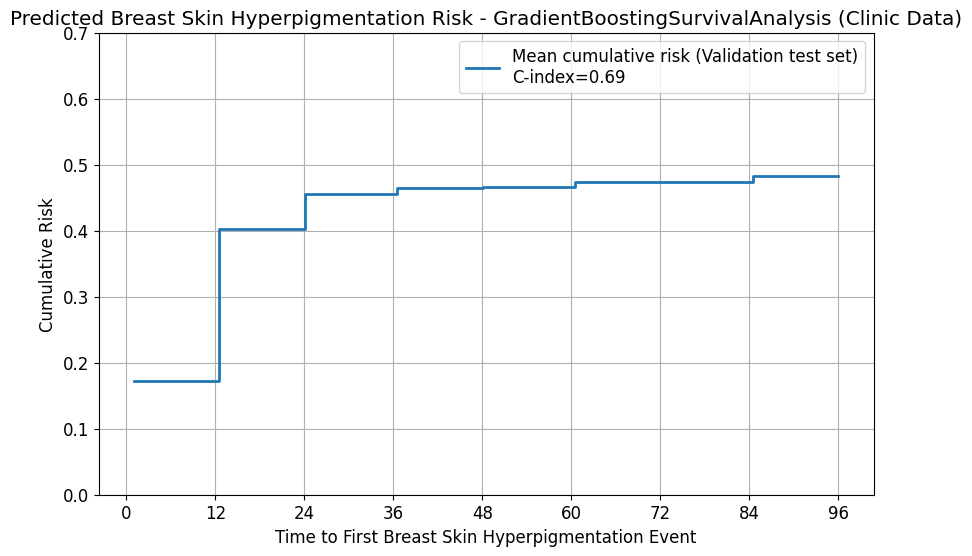


Fitting model: ComponentwiseGradientBoostingSurvivalAnalysis


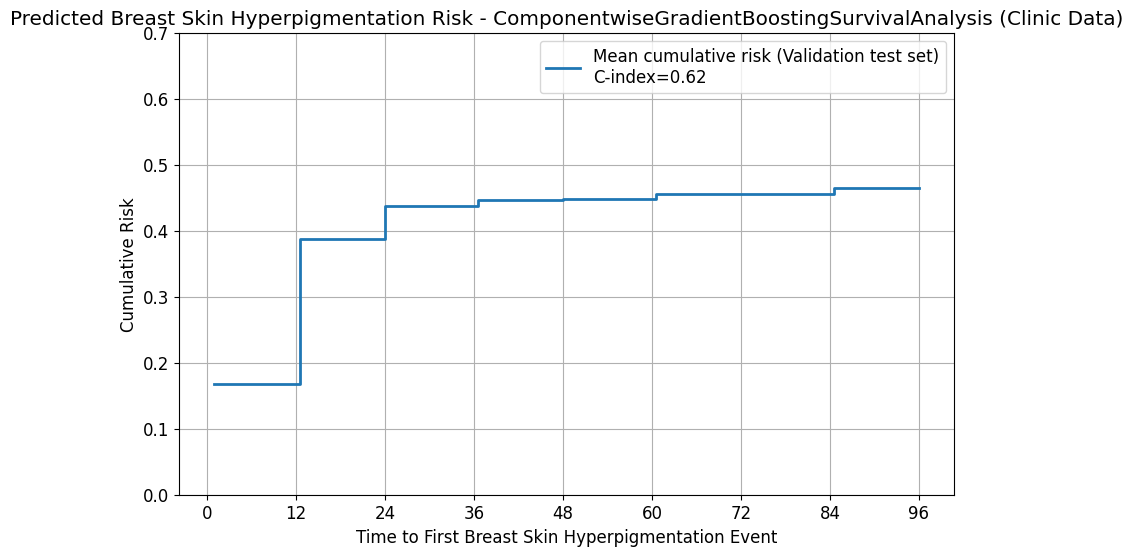


Fitting model: ExtraSurvivalTrees


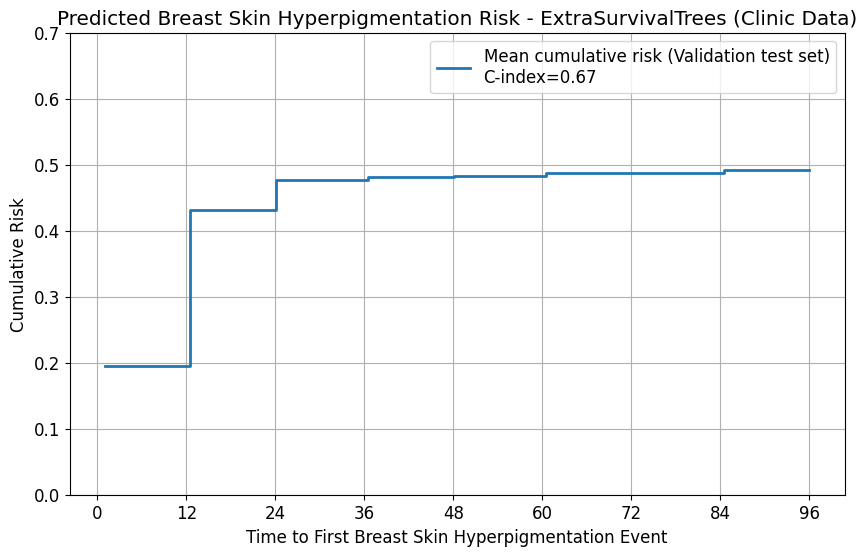


Model: RandomSurvivalForest
 C-Index: 0.6643
 Mean Cumulative Risk: 0.5043
 Brier Score checkpoints:
  t=1.00 → Brier=0.1746
  t=11.56 → Brier=0.1746
  t=24.03 → Brier=0.2524
  t=35.55 → Brier=0.2524
  t=48.02 → Brier=0.2466
  t=59.54 → Brier=0.2466
  t=72.01 → Brier=0.2709
  t=83.53 → Brier=0.2709
  t=96.00 → Brier=0.3028

Model: CoxPHSurvivalAnalysis
 C-Index: 0.6751
 Mean Cumulative Risk: 0.4689
 Brier Score checkpoints:
  t=1.00 → Brier=0.1786
  t=11.56 → Brier=0.1786
  t=24.03 → Brier=0.2667
  t=35.55 → Brier=0.2667
  t=48.02 → Brier=0.2610
  t=59.54 → Brier=0.2610
  t=72.01 → Brier=0.2866
  t=83.53 → Brier=0.2866
  t=96.00 → Brier=0.3642

Model: GradientBoostingSurvivalAnalysis
 C-Index: 0.6879
 Mean Cumulative Risk: 0.4834
 Brier Score checkpoints:
  t=1.00 → Brier=0.1730
  t=11.56 → Brier=0.1730
  t=24.03 → Brier=0.2553
  t=35.55 → Brier=0.2553
  t=48.02 → Brier=0.2529
  t=59.54 → Brier=0.2529
  t=72.01 → Brier=0.2967
  t=83.53 → Brier=0.2967
  t=96.00 → Brier=0.3724

Model: C

In [149]:
from sksurv.metrics import brier_score
Survival_Model_validation(n_df1_train, n_df1_test,
    clinic, duration_col='Timehyperpigmentation1', event_col='Eventhyperpigmentation1', event_type= 'First',
    y_endpoint=0.75,
    y_ranges=0.1, color='tab:blue', s= '(Clinic Data)')

Each blue square = estimated HR for a variable.

The horizontal line = 95% confidence interval.

The vertical dashed line at 1.0 = “no effect.”

Variables to the right of 1.0 increase risk.

Variables to the left of 1.0 decrease risk.

Variables whose CI crosses 1.0 are not statistically significant.

Thus, in your case:

The baseline lymphedema and baseline arm swelling bars are far to the right → strong, significant risk factors.

Factors clustered near 1.0 (like hypertension, depression, etc.) → little or no independent effect.

#**3. Tim Lucas Advice!**

In [ ]:
# 10-fold Cross Validation Survival Models
# + Additional fixed-time (5-year) accuracy evaluation as requested by supervisor

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import roc_auc_score

from sksurv.util import Surv
from sksurv.ensemble import RandomSurvivalForest, GradientBoostingSurvivalAnalysis
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_censored


def Survival_Model_crossvalidationTL(
    n_df_clean,
    duration_col='Time1',
    event_col='Event1',
    event_type='First',
    y_endpoint=1,
    n_splits=10
):

    # ======================
    # PARAMETERS
    # ======================
    eval_time = 24  # Example 5 years (months)

    # ======================
    # DATA
    # ======================
    n_df_clean = n_df_clean.dropna()

    X = n_df_clean[[
          'history_of_heart_disease', 'hypertension', 'depression', 'analgesics', 'nodes_involved', 'nodes_examined',    'post_operative_haematoma', 'post_operative_oedema', 'post_operative_infection', 'delayed_healing', 'chemo_neo_adjuvant', 'chemo_adjuvant',
    'radio_heart_mean_dose_Gy', 'radio_hot_spots_107', 'axillary_levels',
    'radio_supraclavicular_fossa', 'radio_photon_2nd',    'breast_telangiectasia_tumour_bed_baseline',
    'breast_arm_Atrophy_baseline', 'breast_swollen_arm_baseline'
    ]]

    y = Surv.from_dataframe(event_col, duration_col, n_df_clean)

    # ======================
    # MODELS
    # ======================
    MLmodels = [
        RandomSurvivalForest(max_depth=3, max_features=0.5, min_samples_split=5, n_estimators=50, random_state=12),

        CoxPHSurvivalAnalysis(alpha=0.1, n_iter=100),

        GradientBoostingSurvivalAnalysis(n_estimators=50, learning_rate=0.01, max_depth=3, subsample=0.8, loss='coxph', random_state=12)
        ]

    # ======================
    # CROSS-VALIDATION SETUP
    # ======================
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    results = {
        m.__class__.__name__: {
            'c_index': [],
            'fold_surv': [],
            'times': None,
            'accuracy_5yr': [],
            'confusion_5yr': [],
            'auc_5yr': []
        }
        for m in MLmodels
    }

    # ======================
    # HELPER FUNCTION
    # ======================
    def unpack_surv(s):
        events = np.array([row[0] for row in s], dtype=bool)
        times = np.array([row[1] for row in s], dtype=float)
        return events, times

    # ======================
    # CROSS-VALIDATION LOOP
    # ======================
    for fold, (train_idx, test_idx) in enumerate(kf.split(X), 1):
        print(f"\n===== FOLD {fold} =====")

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        y_train_e, y_train_t = unpack_surv(y_train)
        y_test_e, y_test_t = unpack_surv(y_test)

        # Common time grid per fold
        times = np.linspace(
            y_test_t.min(),
            np.nextafter(y_test_t.max(), -np.inf),
            200
        )

        for model in MLmodels:
            name = model.__class__.__name__

            # -------- FIT MODEL --------
            model.fit(X_train, y_train)

            # -------- SURVIVAL PREDICTIONS --------
            surv_fns = model.predict_survival_function(X_test)
            surv_probs = np.row_stack([fn(times) for fn in surv_fns])

            # store mean survival curve for plotting
            results[name]['fold_surv'].append(surv_probs.mean(axis=0))
            results[name]['times'] = times

            # -------- C-INDEX --------
            try:
                ch = model.predict_cumulative_hazard_function(X_test)
                risks = np.array([fn(times[-1]) for fn in ch])
            except:
                risks = -surv_probs[:, -1]

            cidx = concordance_index_censored(y_test_e, y_test_t, risks)[0]
            results[name]['c_index'].append(cidx)

            print(f"{name}: C-index = {cidx:.4f}")

            # ======================
            # FIXED 5-YEAR EVALUATION
            # ======================
            # find index for 5-year time
            if eval_time <= times.max():
                idx_5yr = np.searchsorted(times, eval_time)
            else:
                idx_5yr = -1

            # predicted risk at 5 years
            pred_surv_5yr = surv_probs[:, idx_5yr]
            pred_risk_5yr = 1 - pred_surv_5yr

            # true outcome by 5 years
            true_event_5yr = (y_test_e) & (y_test_t <= eval_time)

            # eligible individuals (Tim's rule)
            eligible = (y_test_t >= eval_time) | true_event_5yr

            y_true = true_event_5yr[eligible].astype(int)
            y_pred = (pred_risk_5yr[eligible] > 0.5).astype(int)
            y_score = pred_risk_5yr[eligible]

            if len(y_true) > 0:
                cm = confusion_matrix(y_true, y_pred)
                acc = accuracy_score(y_true, y_pred)

                results[name]['accuracy_5yr'].append(acc)
                results[name]['confusion_5yr'].append(cm)

            # ----- AUC (no threshold) -----
            if len(np.unique(y_true)) > 1:
                auc = roc_auc_score(y_true, y_score)
                results[name]['auc_5yr'].append(auc)

    # ======================
    # FINAL PLOTS
    # ======================
    for name, res in results.items():
        times = res['times']
        fold_curves = np.stack(res['fold_surv'])
        mean_curve = fold_curves.mean(axis=0)

        plt.figure(figsize=(8, 5))

        for i in range(fold_curves.shape[0]):
            plt.plot(times, 1 - fold_curves[i], alpha=0.6, linewidth=1)

        plt.plot(
            times,
            1 - mean_curve,
            color='black',
            linewidth=2,
            label=f"Average Predicted Risk (Mean C-index={np.mean(res['c_index']):.2f})"
        )

        plt.title(f"{name} —{n_splits}-Fold Survival Curves")
        plt.xlabel(f"Time to {event_type} Event")
        plt.ylabel("Cumulative Risk")
        plt.xticks(np.arange(0, 100, 12))
        plt.yticks(np.arange(0, y_endpoint, 0.10))
        plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
        plt.legend()
        plt.show()

        print(f"\nModel: {name}")
        print(f"Mean C-index: {np.mean(res['c_index']):.3f}")

        if res['auc_5yr']:
            print(f"Mean {eval_time}-months AUC: {np.mean(res['auc_5yr']):.3f}")

        if res['accuracy_5yr']:
            print(f"Mean {eval_time}-months accuracy: {np.mean(res['accuracy_5yr']):.3f}")
            print(f"Mean confusion matrix ({eval_time}-months):")
            print(np.mean(res['confusion_5yr'], axis=0))


In [ ]:
Survival_Model_crossvalidationTL(n_df_clean1, duration_col='Time1', event_col='Event1', event_type= 'First', y_endpoint= 0.30, n_splits=10)

In [ ]:
Survival_Model_crossvalidationTL(n_df_clean2, duration_col='Time2', event_col='Event2', event_type= 'Severe', y_endpoint= 0.30, n_splits=9)

# trajectory analysis

You have excellent data up to 24 months, and some data up to 36 months.

Beyond 36 months, >60 % of patients are missing → serious attrition.

At 72–96 months, data are too sparse to infer meaningful trajectories (you’d risk strong selection bias).

So:
➡ You can do trajectory analysis, but should limit it to 24 or 36 months (max).
Beyond that, the missingness is too high for reliable “disease course” inference.

In [ ]:
cols = [
    "breast_arm_Atrophy_baseline",
    "breast_arm_Atrophy_postRT",
    "breast_arm_Atrophy_12m",
    "breast_arm_Atrophy_24m",
    "breast_arm_Atrophy_36m"
]


In [ ]:
n_df["max_grade"] = n_df[cols].max(axis=1, skipna=True)
n_df["last_grade"] = n_df[cols[::-1]].bfill(axis=1).iloc[:, 0]

def classify_course(row):
    grades = row[cols].dropna().values
    if len(grades) == 0 or np.all(grades == 0):
        return "No event"
    if (grades > 0).any() and grades[-1] == 0:
        return "Recovered"
    if np.all(grades >= 1):
        return "Persistent"
    if np.all(np.diff(grades) >= 0):
        return "Worsening"
    return "Fluctuating"

n_df["course_type"] = n_df.apply(classify_course, axis=1)


In [ ]:
n_df["course_type"].value_counts(normalize=True).mul(100).round(1)


In [ ]:
# This take all endpoints
# 1. Maximum grade reached across all follow-ups
n_df["max_grade"] = n_df[
    ["breast_arm_Atrophy_baseline", "breast_arm_Atrophy_postRT",
     "breast_arm_Atrophy_12m", "breast_arm_Atrophy_24m",
     "breast_arm_Atrophy_36m", "breast_arm_Atrophy_48m",
     "breast_arm_Atrophy_60m", "breast_arm_Atrophy_72m",
     "breast_arm_Atrophy_84m", "breast_arm_Atrophy_96m"]
].max(axis=1, skipna=True)

# 2. Last known grade
n_df["last_grade"] = n_df[
    ["breast_arm_Atrophy_96m", "breast_arm_lymphodema_84m", "breast_arm_lymphodema_72m",
     "breast_arm_lymphodema_60m", "breast_arm_lymphodema_48m"]
].bfill(axis=1).iloc[:, 0]

# 3. Define trajectory label
def classify_trajectory(row):
    if row["max_grade"] == 0:
        return "No lymphedema"
    elif row["last_grade"] == 0:
        return "Recovered"
    elif row["last_grade"] >= row["max_grade"] - 1:
        return "Persistent/worsening"
    else:
        return "Fluctuating"

n_df["trajectory_type"] = n_df.apply(classify_trajectory, axis=1)


In [ ]:
n_df["trajectory_type"].value_counts(normalize=True).mul(100).round(1)

In [ ]:
from sklearn.linear_model import LogisticRegression


X = n_df[['history_of_heart_disease', 'hypertension', 'depression', 'analgesics', 'nodes_involved', 'nodes_examined', 'post_operative_haematoma', 'post_operative_oedema', 'post_operative_infection', 'delayed_healing', 'chemo_neo_adjuvant', 'chemo_adjuvant', 'radio_heart_mean_dose_Gy', 'radio_hot_spots_107', 'axillary_levels', 'radio_supraclavicular_fossa', 'radio_photon_2nd', 'breast_telangiectasia_tumour_bed_baseline', 'breast_arm_lymphodema_baseline', 'breast_swollen_arm_baseline']].fillna(0)

y = n_df["trajectory_type"]

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)


model = LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)  # probabilities for each class

accuracy = model.score(X_test, y_test)
print("Test set accuracy:", accuracy, '\n')

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues', xticks_rotation='vertical')
plt.title("Confusion Matrix")
plt.show()


import pandas as pd

coefficients = pd.DataFrame(model.coef_, columns=X.columns, index=model.classes_)
print(coefficients)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=500, random_state=42, class_weight='balanced')
rf.fit(X, y)
